# LASSO Updraft Width Resolution Sensitivity — Composite Profile Analysis

Analyzes tracked convective cell objects from WRF LASSO simulations at three resolutions
(D2 = 2.5 km, D3 = 500 m, D4 = 100 m) to compare narrow vs. wide cell properties
and composite vertical structure.

## Workflow
1. Load pre-filtered track statistics (combined multi-day files per domain, from `src/filter_and_save_combined_tracks.py`)
2. Subset to CI time window; compute per-track max cell diameter, ETH, reflectivity, updraft top
3. Classify cells as **narrow** (`CImaxCellDiam < narrow_diam`, MULNB > 6 km, Wbase near LCL)
   or **wide** (same + `Wtop_slope > 0`); thresholds derived in `plot_track_correlations_lasso_by_celldiam_avg_env_load_filtered.ipynb`
4. Compute cloud-base-aligned composite vertical profiles binned by ETH quartiles
5. Compute pre-CI environment statistics for the deepest wide cell group

## Plots produced
- Bar charts: narrow vs. wide cell counts by LASSO case date (3 domains)
- Violin / split-violin: max cell diameter, max 10-dBZ ETH, max reflectivity, max updraft top
- Composite time series: mean ETH and cloud-base updraft width over CI window
- Cloud-base-aligned composite profiles (4 ETH bins) per domain:
  - Updraft core diameter, θ_v buoyancy, θ_ρ buoyancy, number of cores, mean W, mass flux, shell RH
- Scatter / regression: buoyancy reduction rate vs. layer-mean RH and Δθ_e
- KDE environment panels (9-panel): pre-CI LWP, CAPE, LCL, RH, shear, moisture for deepest wide cells
- Bar charts: deepest wide cell counts by date (3 domains)

In [1]:
import os, sys
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import xarray as xr
from matplotlib.font_manager import FontProperties
import pandas as pd
from sklearn.neighbors import KernelDensity
from scipy.stats import pearsonr, spearmanr, linregress
import seaborn as sns
import warnings

In [2]:
# mpl.rcParams['font.family'] = 'STIXGeneral'
# mpl.rcParams['font.family'] = 'DejaVuSans'
mpl.rcParams['font.family'] = 'Helvetica'

xr.__version__

'2026.4.0'

## Load Pre-filtered Combined Datasets

This notebook loads the pre-filtered combined datasets generated by the `filter_and_save_combined_tracks.py` script, which combines and filters cell tracking data from multiple LASSO case dates.

In [3]:
# Configuration
# Figure output directory
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell/'
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI+2h_fixshell_paper/'
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI_coldpool+2h/'
figdir = '/Users/feng045/tmp/narrow_wide_CI30min/'
# figdir = '/Users/feng045/tmp/narrow_wide_CI30min_WidthLeadDepth/'
# figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures_avgenv20km/narrow_wide_CI_coldpool+2h_testPython3.12/'
os.makedirs(figdir, exist_ok=True)

# Input directory for pre-filtered combined datasets
# input_dir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined'
# input_dir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined_coldpool+2h'
# input_dir = '/Users/feng045/data/cacti/lasso/les/cell_stats_combined_coldpool+2h'
input_dir = '/Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min'

# Time resolution [minutes]
time_res = 5.0

# Domain 4 boundaries (used for filtering)
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]  # [minutes]

# Time for representative environment
# time_env = -1

# ---------------------------------------------------------------------------
# Filter thresholds (used for narrow/wide cell separation)
# ---------------------------------------------------------------------------
MULNB_thresh = 6.0           # [km] MU LNB threshold; tracks must exceed this
max_Wbase_LCL_dist = 2.0     # [km] max allowed distance between updraft base and LCL
min_Wtop_slope = 0           # minimum updraft top slope for wide cell classification

# Time window for sampling updraft profiles (relative to CI onset)
updraft_time_window = (0, 30)  # [minutes]

In [4]:
# Load pre-filtered datasets directly into memory (avoid Dask for faster operations)
print("Loading pre-filtered combined datasets into memory...")

# Load D2 (2.5 km domain) - load() loads into memory immediately
file_d2 = f'{input_dir}/stats_combined_filtered_d2.nc'
print(f"Loading: {file_d2}")
dsnms_d2 = xr.open_dataset(file_d2).load()  # .load() brings all data into memory
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
print(f"  D2 filtered tracks: {ntracks_nms_d2}")

# Load D3 domain
file_d3 = f'{input_dir}/stats_combined_filtered_d3.nc'
print(f"Loading: {file_d3}")
dsnms_d3 = xr.open_dataset(file_d3).load()
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
print(f"  D3 filtered tracks: {ntracks_nms_d3}")

# Load D4 domain
file_d4 = f'{input_dir}/stats_combined_filtered_d4.nc'
print(f"Loading: {file_d4}")
dsnms_d4 = xr.open_dataset(file_d4).load()
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f"  D4 filtered tracks: {ntracks_nms_d4}")

print("\nAll datasets loaded into memory successfully!")
print(f"Total filtered tracks: {ntracks_nms_d2 + ntracks_nms_d3 + ntracks_nms_d4}")

# Display memory usage
mem_d2 = sum(var.nbytes for var in dsnms_d2.variables.values()) / 1e9
mem_d3 = sum(var.nbytes for var in dsnms_d3.variables.values()) / 1e9
mem_d4 = sum(var.nbytes for var in dsnms_d4.variables.values()) / 1e9
print(f"\nMemory usage:")
print(f"  D2: {mem_d2:.2f} GB")
print(f"  D3: {mem_d3:.2f} GB")
print(f"  D4: {mem_d4:.2f} GB")
print(f"  Total: {mem_d2 + mem_d3 + mem_d4:.2f} GB")

Loading pre-filtered combined datasets into memory...
Loading: /Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min/stats_combined_filtered_d2.nc


/Users/feng045/opt/miniconda3/envs/py312-26.4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  D2 filtered tracks: 646
Loading: /Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min/stats_combined_filtered_d3.nc
  D3 filtered tracks: 1315
Loading: /Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min/stats_combined_filtered_d4.nc
  D4 filtered tracks: 1202

All datasets loaded into memory successfully!
Total filtered tracks: 3163

Memory usage:
  D2: 0.50 GB
  D3: 1.02 GB
  D4: 0.93 GB
  Total: 2.45 GB


In [5]:
# Extract common variables from datasets
# Time coordinate [minutes]
xtime = dsnms_d2.times * time_res

# Modify the first two times (pre-CI) time values (unit: minutes)
# This is hardcoded specific to the average environments files where the extracted time frequencies are 15 min
# Refer to config files: config_lasso_wrf*.yml
# - minutes_prior: 30
# - freq_prior: 15
# xtime.isel(times=slice(0,3))[:] = [-30., -15., 0.]

# Height coordinates
height = dsnms_d2.height  # Environmental variables height
height_core = dsnms_d2.z  # Updraft variables height

# Time window for CI
time_window = (dsnms_d2.attrs['time_start'], dsnms_d2.attrs['time_end'])

print(f"Time coordinate (xtime): {xtime.min().values} to {xtime.max().values} minutes")
print(f"Time window for CI: {time_window} minutes")
print(f"Time window for sampling updraft: {updraft_time_window} minutes")
print(f"Height levels (environment): {len(height)} levels")
print(f"Height levels (core): {len(height_core)} levels")

Time coordinate (xtime): 0.0 to 995.0 minutes
Time window for CI: (np.int64(0), np.int64(60)) minutes
Time window for sampling updraft: (0, 30) minutes
Height levels (environment): 101 levels
Height levels (core): 40 levels


In [6]:
# Display dataset dimensions and summary
print("D2 Dataset:")
print(dsnms_d2)
print("\nD3 Dataset:")
print(dsnms_d3)
print("\nD4 Dataset:")
print(dsnms_d4)

D2 Dataset:
<xarray.Dataset> Size: 500MB
Dimensions:                  (tracks: 646, times: 200, z: 40, height: 101)
Coordinates:
  * tracks                   (tracks) int64 5kB 0 1 2 5 ... 1222 1224 1226 1227
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
  * height                   (height) float64 808B 0.0 200.0 ... 1.98e+04 2e+04
    core                     int64 8B 0
Data variables: (12/200)
    track_duration           (tracks) int32 3kB 4 38 4 15 13 4 ... 21 4 5 22 11
    base_time                (tracks, times) datetime64[ns] 1MB 2018-11-29T13...
    meanlat                  (tracks, times) float32 517kB -32.47 -32.47 ... nan
    meanlon                  (tracks, times) float32 517kB -64.89 -64.89 ... nan
    area                     (tracks, times) float32 517kB 56.25 56.25 ... nan
    cloudnumber              (tracks, times) float64 1MB 1.0 1.0 1.0 ... nan nan
    ..

## Check number of merge after time_window tracks

In [7]:
# Tracks where merging occurs after the time_window
lifetime_merge_after_d2 = dsnms_d2.track_duration.where(~np.isnan(dsnms_d2.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d2 = lifetime_merge_after_d2.min().values
ntracks_merge_after_d2 = (lifetime_merge_after_d2).sizes['tracks']
print(f'D2 merge after time_window tracks: {ntracks_merge_after_d2}, min lifetime: {minlifetime_merge_after_d2} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d3 = dsnms_d3.track_duration.where(~np.isnan(dsnms_d3.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d3 = lifetime_merge_after_d3.min().values
ntracks_merge_after_d3 = (lifetime_merge_after_d3).sizes['tracks']
print(f'D3 merge after time_window tracks: {ntracks_merge_after_d3}, min lifetime: {minlifetime_merge_after_d3} min')

# Tracks where merging occurs after the time_window
lifetime_merge_after_d4 = dsnms_d4.track_duration.where(~np.isnan(dsnms_d4.end_merge_cloudnumber), drop=True) * time_res
minlifetime_merge_after_d4 = lifetime_merge_after_d4.min().values
ntracks_merge_after_d4 = (lifetime_merge_after_d4).sizes['tracks']
print(f'D4 merge after time_window tracks: {ntracks_merge_after_d4}, min lifetime: {minlifetime_merge_after_d4} min')

D2 merge after time_window tracks: 83, min lifetime: 65.0 min
D3 merge after time_window tracks: 63, min lifetime: 65.0 min
D4 merge after time_window tracks: 50, min lifetime: 65.0 min


## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

### Compute time indices for CI and updraft windows

In [8]:
# Find time coordinate index of the time_window
tidx_start = np.argmin(np.abs(xtime.values - np.min(time_window)))
tidx_end = np.argmin(np.abs(xtime.values - np.max(time_window)))
print(f"CI time window start index: {tidx_start}, end index: {tidx_end}")

# Find time coordinate index of the updraft_time_window
W_tidx_start = np.argmin(np.abs(xtime.values - np.min(updraft_time_window)))
W_tidx_end = np.argmin(np.abs(xtime.values - np.max(updraft_time_window)))

print(f"Updraft time window start index: {W_tidx_start}, end index: {W_tidx_end}")

CI time window start index: 0, end index: 12
Updraft time window start index: 0, end index: 6


In [9]:
# # Subset DataSet to CI time_window
# dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
# dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
# dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# # Cell max reflectivity
# maxdbz_d2 = dsCI_d2['max_dbz'].load()
# maxdbz_d3 = dsCI_d3['max_dbz'].load()
# maxdbz_d4 = dsCI_d4['max_dbz'].load()
# # Cell ETH
# maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
# maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
# maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()
# # Cell diameter
# cellarea_d2 = dsCI_d2['cell_area'].load()
# cellarea_d3 = dsCI_d3['cell_area'].load()
# cellarea_d4 = dsCI_d4['cell_area'].load()
# celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
# celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
# celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)
# # Max updraft top height
# trackmaxWtop_d2 = dsCI_d2.Wtop.max(dim='times')
# trackmaxWtop_d3 = dsCI_d3.Wtop.max(dim='times')
# trackmaxWtop_d4 = dsCI_d4.Wtop.max(dim='times')
# # Calculate max W diameter (Warea_max has no times dimension)
# maxWdiam_d2 = 2*np.sqrt(dsCI_d2.Warea_max/np.pi)
# maxWdiam_d3 = 2*np.sqrt(dsCI_d3.Warea_max/np.pi)
# maxWdiam_d4 = 2*np.sqrt(dsCI_d4.Warea_max/np.pi)
# # Max W diameter during CI time window (Warea_max_CI has no times dimension)
# # CI time window set in make_largest_updraft_stats.py (0-15) min
# maxWdiam_CI_d2 = 2*np.sqrt(dsCI_d2['Warea_max_CI']/np.pi)
# maxWdiam_CI_d3 = 2*np.sqrt(dsCI_d3['Warea_max_CI']/np.pi)
# maxWdiam_CI_d4 = 2*np.sqrt(dsCI_d4['Warea_max_CI']/np.pi)

In [10]:
# Subset DataSet to CI time_window
dsCI_d2 = dsnms_d2.isel(times=slice(tidx_start, tidx_end))
dsCI_d3 = dsnms_d3.isel(times=slice(tidx_start, tidx_end))
dsCI_d4 = dsnms_d4.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_d2 = dsCI_d2['max_dbz'].load()
maxdbz_d3 = dsCI_d3['max_dbz'].load()
maxdbz_d4 = dsCI_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsCI_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsCI_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsCI_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsCI_d2['cell_area'].load()
cellarea_d3 = dsCI_d3['cell_area'].load()
cellarea_d4 = dsCI_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)
# Max updraft top height
trackmaxWtop_d2 = dsCI_d2['Wtop'].max(dim='times')
trackmaxWtop_d3 = dsCI_d3['Wtop'].max(dim='times')
trackmaxWtop_d4 = dsCI_d4['Wtop'].max(dim='times')
# Calculate max W diameter (Warea_max has no times dimension)
maxWdiam_d2 = 2*np.sqrt(dsCI_d2['Warea_max']/np.pi)
maxWdiam_d3 = 2*np.sqrt(dsCI_d3['Warea_max']/np.pi)
maxWdiam_d4 = 2*np.sqrt(dsCI_d4['Warea_max']/np.pi)
# Max W diameter during CI time window (Warea_max_CI has no times dimension)
# CI time window set in make_largest_updraft_stats.py (0-15) min
maxWdiam_CI_d2 = 2*np.sqrt(dsCI_d2['Warea_max_CI']/np.pi)
maxWdiam_CI_d3 = 2*np.sqrt(dsCI_d3['Warea_max_CI']/np.pi)
maxWdiam_CI_d4 = 2*np.sqrt(dsCI_d4['Warea_max_CI']/np.pi)
# Time of max W area
maxWdiam_time_d2 = dsCI_d2['Warea_max_time'] * time_res
maxWdiam_time_d3 = dsCI_d3['Warea_max_time'] * time_res
maxWdiam_time_d4 = dsCI_d4['Warea_max_time'] * time_res
# Time of max W area during CI time window
maxWdiam_time_CI_d2 = dsCI_d2['Warea_max_time_CI'] * time_res
maxWdiam_time_CI_d3 = dsCI_d3['Warea_max_time_CI'] * time_res
maxWdiam_time_CI_d4 = dsCI_d4['Warea_max_time_CI'] * time_res
# Time of max updraft top height
trackmaxWtop_time_d2 = dsCI_d2['Wtop'].idxmax(dim='times', skipna=True) * time_res
trackmaxWtop_time_d3 = dsCI_d3['Wtop'].idxmax(dim='times', skipna=True) * time_res
trackmaxWtop_time_d4 = dsCI_d4['Wtop'].idxmax(dim='times', skipna=True) * time_res
# Time of max ETH 10dbz
trackmaxETH_10dbz_time_d2 = maxETH_10dbz_d2.idxmax(dim='times', skipna=True) * time_res
trackmaxETH_10dbz_time_d3 = maxETH_10dbz_d3.idxmax(dim='times', skipna=True) * time_res
trackmaxETH_10dbz_time_d4 = maxETH_10dbz_d4.idxmax(dim='times', skipna=True) * time_res
# Updraft lifetime
Wlifetime_d2 = dsCI_d2['Wlifetime'].load()
Wlifetime_d3 = dsCI_d3['Wlifetime'].load()
Wlifetime_d4 = dsCI_d4['Wlifetime'].load()

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [11]:
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
trackmaxdbz_d2 = maxdbz_d2.max(dim='times')

trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
trackmaxdbz_d3 = maxdbz_d3.max(dim='times')

trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
trackmaxdbz_d4 = maxdbz_d4.max(dim='times')

In [12]:
# # Add CI-period variables to DataSet
# dsnms_d2['CImaxCellDiam'] = trackmaxCellDiam_d2
# dsnms_d2['CImaxETH_10dbz'] = trackmaxETH_10dbz_d2
# dsnms_d2['CImaxdbz'] = trackmaxdbz_d2
# dsnms_d2['CImaxWDiam'] = maxWdiam_d2
# dsnms_d2['CImaxWDiam_CI'] = maxWdiam_CI_d2
# dsnms_d2['CImaxWTop'] = trackmaxWtop_d2

# # Add CI-period variables to DataSet
# dsnms_d3['CImaxCellDiam'] = trackmaxCellDiam_d3
# dsnms_d3['CImaxETH_10dbz'] = trackmaxETH_10dbz_d3
# dsnms_d3['CImaxdbz'] = trackmaxdbz_d3
# dsnms_d3['CImaxWDiam'] = maxWdiam_d3
# dsnms_d3['CImaxWDiam_CI'] = maxWdiam_CI_d3
# dsnms_d3['CImaxWTop'] = trackmaxWtop_d3

# # Add CI-period variables to DataSet
# dsnms_d4['CImaxCellDiam'] = trackmaxCellDiam_d4
# dsnms_d4['CImaxETH_10dbz'] = trackmaxETH_10dbz_d4
# dsnms_d4['CImaxdbz'] = trackmaxdbz_d4
# dsnms_d4['CImaxWDiam'] = maxWdiam_d4
# dsnms_d4['CImaxWDiam_CI'] = maxWdiam_CI_d4
# dsnms_d4['CImaxWTop'] = trackmaxWtop_d4

In [13]:
# D2
dsnms_d2['CImaxCellDiam'] = trackmaxCellDiam_d2
dsnms_d2['CImaxETH_10dbz'] = trackmaxETH_10dbz_d2
dsnms_d2['CImaxdbz'] = trackmaxdbz_d2
dsnms_d2['CImaxWDiam'] = maxWdiam_d2
dsnms_d2['CImaxWTop'] = trackmaxWtop_d2
dsnms_d2['CImaxWDiamTime'] = maxWdiam_time_d2
dsnms_d2['CImaxWTopTime'] = trackmaxWtop_time_d2
dsnms_d2['CImaxWDiam_CI'] = maxWdiam_CI_d2
dsnms_d2['CImaxWDiamTime_CI'] = maxWdiam_time_CI_d2
dsnms_d2['CImaxETH10dbzTime'] = trackmaxETH_10dbz_time_d2

# D3
dsnms_d3['CImaxCellDiam'] = trackmaxCellDiam_d3
dsnms_d3['CImaxETH_10dbz'] = trackmaxETH_10dbz_d3
dsnms_d3['CImaxdbz'] = trackmaxdbz_d3
dsnms_d3['CImaxWDiam'] = maxWdiam_d3
dsnms_d3['CImaxWTop'] = trackmaxWtop_d3
dsnms_d3['CImaxWDiamTime'] = maxWdiam_time_d3
dsnms_d3['CImaxWTopTime'] = trackmaxWtop_time_d3
dsnms_d3['CImaxWDiam_CI'] = maxWdiam_CI_d3
dsnms_d3['CImaxWDiamTime_CI'] = maxWdiam_time_CI_d3
dsnms_d3['CImaxETH10dbzTime'] = trackmaxETH_10dbz_time_d3
# D4
dsnms_d4['CImaxCellDiam'] = trackmaxCellDiam_d4
dsnms_d4['CImaxETH_10dbz'] = trackmaxETH_10dbz_d4
dsnms_d4['CImaxdbz'] = trackmaxdbz_d4
dsnms_d4['CImaxWDiam'] = maxWdiam_d4
dsnms_d4['CImaxWTop'] = trackmaxWtop_d4
dsnms_d4['CImaxWDiamTime'] = maxWdiam_time_d4
dsnms_d4['CImaxWTopTime'] = trackmaxWtop_time_d4
dsnms_d4['CImaxWDiam_CI'] = maxWdiam_CI_d4
dsnms_d4['CImaxWDiamTime_CI'] = maxWdiam_time_CI_d4
dsnms_d4['CImaxETH10dbzTime'] = trackmaxETH_10dbz_time_d4

## Separate narrow vs. wide cell DataSets
#### Thresholds determined in `plot_track_correlations_lasso_by_celldiam_avg_env_load_filtered.ipynb`

In [14]:
# # Thresholds derived in plot_track_correlations_lasso_by_celldiam_avg_env_load_filtered.ipynb
# # (printed with :.10f precision to avoid boundary-track ambiguity)
# narrow_diam_d2 = 12.6156625748  # km
# narrow_diam_d3 = 7.3561320305  # km
# narrow_diam_d4 = 7.3344645500  # km

# wide_diam_d2 = 15.7063732147  # km
# wide_diam_d3 = 8.6488618851  # km
# wide_diam_d4 = 8.7984601974  # km

In [15]:
narrow_diam_d2 = 12.6156625748  # km
narrow_diam_d3 = 8.6488618851  # km
narrow_diam_d4 = 7.3344645500  # km


wide_diam_d2 = 15.7063732147  # km
wide_diam_d3 = 12.3220863342  # km
wide_diam_d4 = 8.7984601974  # km

## Get preCI MU LNB

In [16]:
MULNB_d2 = (dsnms_d2.EL_height_mu/1000)
MULNB_d3 = (dsnms_d3.EL_height_mu/1000)
MULNB_d4 = (dsnms_d4.EL_height_mu/1000)

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.00167224, 0.        , 0.00501672,
        0.00334448, 0.        , 0.00668896, 0.01337793, 0.03010033,
        0.12040134, 0.28929766, 0.20234114, 0.12207358, 0.0367893 ,
        0.0083612 , 0.02006689, 0.06354515, 0.08695652, 0.14214047,
        0.19732441, 0.16722408, 0.14046823, 0.14214047, 0.0735786 ,
        0.0735786 , 0.05351171, 0.        , 0.        , 0.        ,
        0.        ]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5, 17. , 17.5, 18. ]),
 <BarContainer object of 36 artists>)

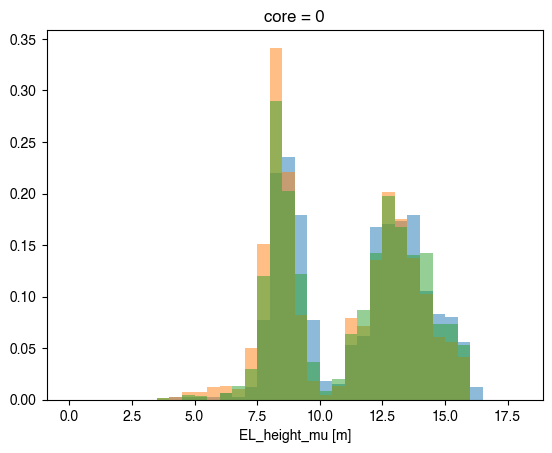

In [17]:
bins = np.arange(0, 18.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

In [18]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_d2 = ((dsnms_d2.CImaxCellDiam < narrow_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                    & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist)).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d2 = ((dsnms_d2.CImaxCellDiam >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh) \
                  & (dsnms_d2.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d2.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                  # & (dsnms_d2.CImaxWDiamTime <= dsnms_d2.CImaxETH10dbzTime) \
                ).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
# print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
# print(f'Number of wide cells (D2): {ntracks_wide_d2}')
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}, {ntracks_narrow_d2/dsnms_d2.sizes["tracks"]*100:.0f}% of total')
print(f'Number of wide cells (D2): {ntracks_wide_d2}, {ntracks_wide_d2/dsnms_d2.sizes["tracks"]*100:.0f}% of total')

# CI-window lifetime (count number of time a cell exists in the CI window)
# NOTE: not currently used in any plot
narrow_track_lifetime_d2 = (ds_narrow_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d2 = (ds_wide_d2.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.CImaxdbz
wide_maxdbz_d2 = ds_wide_d2.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.CImaxETH_10dbz
wide_maxETH10dbz_d2 = ds_wide_d2.CImaxETH_10dbz
# CI-max cell diameter
# NOTE: not currently used in any plot
narrow_maxdiam_d2 = ds_narrow_d2.CImaxCellDiam
wide_maxdiam_d2 = ds_wide_d2.CImaxCellDiam
# CI-window cloud-base updraft diameter
# NOTE: not currently used in any plot
narrow_maxWdiam_d2 = ds_narrow_d2.CImaxWDiam
wide_maxWdiam_d2 = ds_wide_d2.CImaxWDiam
# CI-window cloud-base updraft speed
# NOTE: not currently used in any plot
narrow_maxWspeed_d2 = ds_narrow_d2.Wspeed_max
wide_maxWspeed_d2 = ds_wide_d2.Wspeed_max
# CI-max updraft top height
narrow_maxWtop_d2 = ds_narrow_d2.CImaxWTop
wide_maxWtop_d2 = ds_wide_d2.CImaxWTop

Number of narrow cells (D2): 398, 62% of total
Number of wide cells (D2): 99, 15% of total


In [19]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_d3 = ((dsnms_d3.CImaxCellDiam < narrow_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                    & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d3 = ((dsnms_d3.CImaxCellDiam >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh) \
                  & (dsnms_d3.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d3.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                #   & (dsnms_d3.CImaxWDiamTime <= dsnms_d3.CImaxETH10dbzTime) \
                 ).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}, {ntracks_narrow_d3/dsnms_d3.sizes["tracks"]*100:.0f}% of total')
print(f'Number of wide cells (D3): {ntracks_wide_d3}, {ntracks_wide_d3/dsnms_d3.sizes["tracks"]*100:.0f}% of total')

# CI-window lifetime (count number of time a cell exists in the CI window)
# NOTE: not currently used in any plot
narrow_track_lifetime_d3 = (ds_narrow_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d3 = (ds_wide_d3.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.CImaxdbz
wide_maxdbz_d3 = ds_wide_d3.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.CImaxETH_10dbz
wide_maxETH10dbz_d3 = ds_wide_d3.CImaxETH_10dbz
# CI-max cell diameter
# NOTE: not currently used in any plot
narrow_maxdiam_d3 = ds_narrow_d3.CImaxCellDiam
wide_maxdiam_d3 = ds_wide_d3.CImaxCellDiam
# CI-window cloud-base updraft diameter
# NOTE: not currently used in any plot
narrow_maxWdiam_d3 = ds_narrow_d3.CImaxWDiam
wide_maxWdiam_d3 = ds_wide_d3.CImaxWDiam
# CI-window cloud-base updraft speed
# NOTE: not currently used in any plot
narrow_maxWspeed_d3 = ds_narrow_d3.Wspeed_max
wide_maxWspeed_d3 = ds_wide_d3.Wspeed_max
# CI-max updraft top height
narrow_maxWtop_d3 = ds_narrow_d3.CImaxWTop
wide_maxWtop_d3 = ds_wide_d3.CImaxWTop

Number of narrow cells (D3): 945, 72% of total
Number of wide cells (D3): 127, 10% of total


In [20]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_d4 = ((dsnms_d4.CImaxCellDiam < narrow_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                    & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_d4 = ((dsnms_d4.CImaxCellDiam >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh) \
                  & (dsnms_d4.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_d4.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                  # & (dsnms_d4.CImaxWDiamTime <= dsnms_d4.CImaxETH10dbzTime) \
                 ).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}, {ntracks_narrow_d4/dsnms_d4.sizes["tracks"]*100:.0f}% of total')
print(f'Number of wide cells (D4): {ntracks_wide_d4}, {ntracks_wide_d4/dsnms_d4.sizes["tracks"]*100:.0f}% of total')

# CI-window lifetime (count number of time a cell exists in the CI window)
# NOTE: not currently used in any plot
narrow_track_lifetime_d4 = (ds_narrow_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
wide_track_lifetime_d4 = (ds_wide_d4.isel(times=slice(tidx_start, tidx_end)).cell_area > 0).sum(dim='times') * time_res
# CI-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.CImaxdbz
wide_maxdbz_d4 = ds_wide_d4.CImaxdbz
# CI-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.CImaxETH_10dbz
wide_maxETH10dbz_d4 = ds_wide_d4.CImaxETH_10dbz
# CI-max cell diameter
# NOTE: not currently used in any plot
narrow_maxdiam_d4 = ds_narrow_d4.CImaxCellDiam
wide_maxdiam_d4 = ds_wide_d4.CImaxCellDiam
# CI-window cloud-base updraft diameter
# NOTE: not currently used in any plot
narrow_maxWdiam_d4 = ds_narrow_d4.CImaxWDiam
wide_maxWdiam_d4 = ds_wide_d4.CImaxWDiam
# CI-window cloud-base updraft speed
# NOTE: not currently used in any plot
narrow_maxWspeed_d4 = ds_narrow_d4.Wspeed_max
wide_maxWspeed_d4 = ds_wide_d4.Wspeed_max
# CI-max updraft top height
narrow_maxWtop_d4 = ds_narrow_d4.CImaxWTop
wide_maxWtop_d4 = ds_wide_d4.CImaxWTop

Number of narrow cells (D4): 747, 62% of total
Number of wide cells (D4): 195, 16% of total


## Group DataSets by dates

In [21]:
dates_narrow_d2 = ds_narrow_d2.date
dates_wide_d2 = ds_wide_d2.date

dates_narrow_d3 = ds_narrow_d3.date
dates_wide_d3 = ds_wide_d3.date

dates_narrow_d4 = ds_narrow_d4.date
dates_wide_d4 = ds_wide_d4.date

In [22]:
unique_dates = np.unique(dates_narrow_d2)
unique_dates_str = pd.to_datetime(unique_dates).strftime('%Y-%m-%d')
unique_dates_str

Index(['2018-11-29', '2018-12-04', '2018-12-05', '2019-01-22', '2019-01-23',
       '2019-01-25', '2019-01-29', '2019-02-08'],
      dtype='str')

In [23]:
ntracks_narrow_dates_d2 = ds_narrow_d2.tracks.groupby(dates_narrow_d2).count()
ntracks_wide_dates_d2 = ds_wide_d2.tracks.groupby(dates_wide_d2).count()

ntracks_narrow_dates_d3 = ds_narrow_d3.tracks.groupby(dates_narrow_d3).count()
ntracks_wide_dates_d3 = ds_wide_d3.tracks.groupby(dates_wide_d3).count()

ntracks_narrow_dates_d4 = ds_narrow_d4.tracks.groupby(dates_narrow_d4).count()
ntracks_wide_dates_d4 = ds_wide_d4.tracks.groupby(dates_wide_d4).count()

In [24]:
def plot_bars(bar_data, xlabel=None, ylabel=None, title=None, figsize=None, figname=None, fontsize=None, bold_xlabel=False, name_map=None):
    # plt.rcParams['font.family'] = 'DejaVu Serif'
    mpl.rcParams['font.size'] = fontsize

    x = np.arange(len(xlabel))  # the label locations
    width = 0.2  # the width of the bars
    lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
    if name_map is None:
        name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    bars2 = ax.bar(x - width, bar_data['d2'], width, label=name_map['d2'], color=lcolors['d2'])
    bars3 = ax.bar(x, bar_data['d3'], width, label=name_map['d3'], color=lcolors['d3'])
    bars4 = ax.bar(x + width, bar_data['d4'], width, label=name_map['d4'], color=lcolors['d4'])

    # Create font properties
    bold_font = FontProperties(weight='bold', family='Helvetica')
    regular_font = FontProperties(weight='normal', family='Helvetica')

    if bold_xlabel:
        # Function to format labels
        def format_label(label):
            parts = label.split('.')
            return f"$\\bf{{{parts[0]}}}$.{parts[1]}"

        # Format xlabels
        formatted_xlabels = [format_label(label) for label in xlabel]
    else:
        formatted_xlabels = xlabel

    # Add some text for labels, title and custom x-axis tick labels, etc.
    # ax.set_xlabel('Cases')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    ax.set_xticks(x)
    ax.set_xticklabels(formatted_xlabels, rotation=30, ha='right')
    ax.grid(ls=':', axis='y')
    ax.legend()

    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

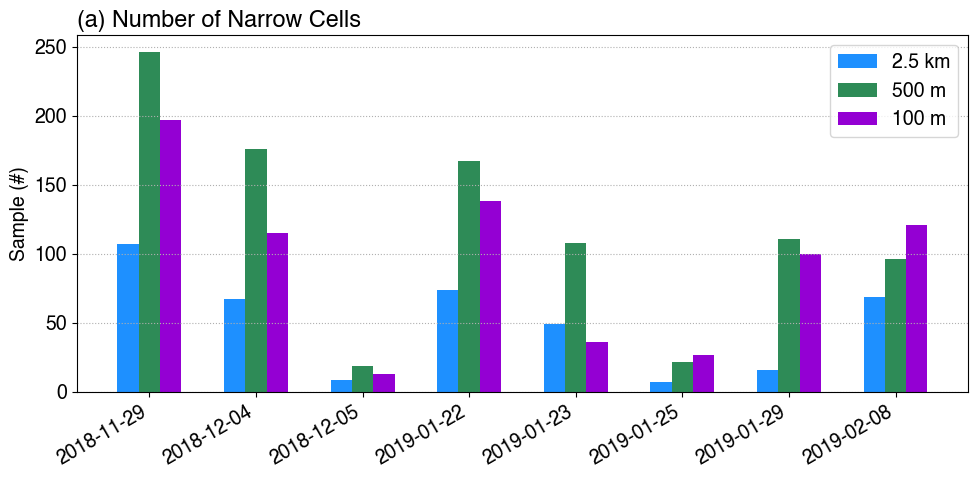

In [25]:
x = np.arange(len(unique_dates))
bar_data = {'d2':ntracks_narrow_dates_d2, 'd3':ntracks_narrow_dates_d3, 'd4':ntracks_narrow_dates_d4}
ylabel = 'Sample (#)'
title = '(a) Number of Narrow Cells'
fontsize = 14
figsize = [10,5]
figname = f'{figdir}CellNumberByDate_narrow_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=unique_dates_str, ylabel=ylabel, title=title, fontsize=fontsize, figsize=figsize, figname=figname)

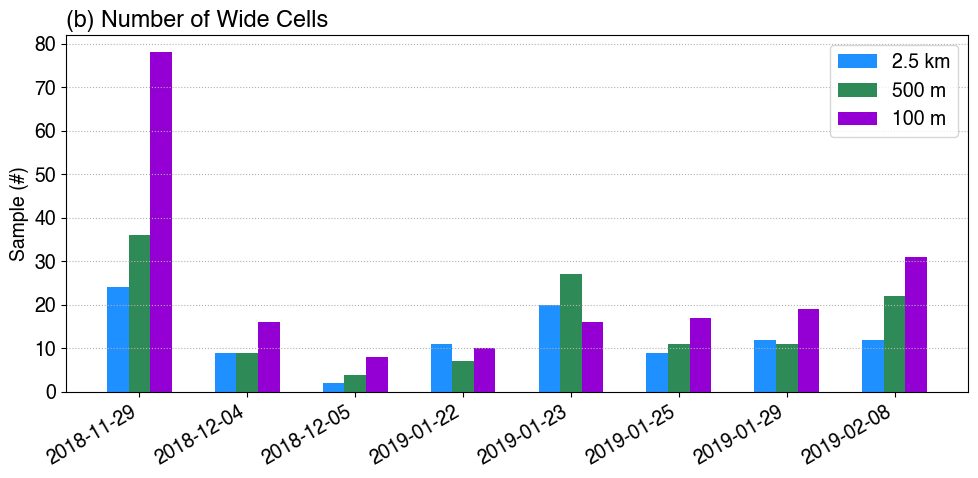

In [26]:
x = np.arange(len(unique_dates))
bar_data = {'d2':ntracks_wide_dates_d2, 'd3':ntracks_wide_dates_d3, 'd4':ntracks_wide_dates_d4}
ylabel = 'Sample (#)'
title = '(b) Number of Wide Cells'
fontsize = 14
figsize = [10,5]
figname = f'{figdir}CellNumberByDate_wide_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=unique_dates_str, ylabel=ylabel, title=title, fontsize=fontsize, figsize=figsize, figname=figname)

In [27]:
# Median 10dBZ ETH by date
# NOTE: not currently used in any plot
narrow_maxETH10dbz_thresh_bydate_d2 = ds_narrow_d2.CImaxETH_10dbz.groupby(dates_narrow_d2).median()
narrow_maxETH10dbz_thresh_bydate_d2

<xarray.DataArray 'CImaxETH_10dbz' (date: 8)> Size: 32B
array([4.   , 4.75 , 4.75 , 3.75 , 4.   , 5.   , 4.375, 3.5  ],
      dtype=float32)
Coordinates:
  * date     (date) datetime64[ns] 64B 2018-11-29 2018-12-04 ... 2019-02-08
    core     int64 8B 0
Attributes:
    long_name:  Maximum 10dBZ echo-top height in a convective cell
    units:      km

## Relationships between updraft buoyancy reduction rate with average RH in the layer where buoyancy is reducing

In [28]:
def buoy_slope(buoy_profile, z):
    """
    Compute updraft buoyancy profile reduction rate from in-cloud maximum to
    cloud-top minimum using a linear fit.

    Parameters
    ----------
    buoy_profile : array-like, shape (nz,)
        1D buoyancy profile (e.g., max over times for one track).
    z : array-like, shape (nz,)
        Height levels (km) corresponding to buoy_profile.

    Returns
    -------
    dict or None
        Keys:
          'buoy_max'   : maximum buoyancy value (m/s²)
          'z_max'      : height of buoy_max (km)
          'buoy_min'   : minimum buoyancy above buoy_max (m/s²)
          'z_min'      : height of buoy_min (km)
          'poly_coeffs': np.polyfit coefficients [slope (m/s²/km), intercept]
        Returns None if the profile has insufficient valid data.
    """
    buoy_arr = np.asarray(buoy_profile, dtype=float)
    z_arr    = np.asarray(z, dtype=float)

    valid = ~np.isnan(buoy_arr)
    if valid.sum() < 2:
        return None

    buoy_v = buoy_arr[valid]
    z_v    = z_arr[valid]

    # Max buoyancy and its z level
    idx_max  = np.argmax(buoy_v)
    buoy_max = float(buoy_v[idx_max])
    z_max    = float(z_v[idx_max])

    # Minimum buoyancy strictly above the max level
    above_mask = z_v > z_max
    if above_mask.sum() == 0:
        return None
    buoy_above = buoy_v[above_mask]
    z_above    = z_v[above_mask]
    idx_min    = np.argmin(buoy_above)
    buoy_min   = float(buoy_above[idx_min])
    z_min      = float(z_above[idx_min])

    # Linear fit between z_max and z_min (inclusive)
    between = (z_v >= z_max) & (z_v <= z_min)
    if between.sum() < 2:
        return None
    poly_coeffs = np.polyfit(z_v[between], buoy_v[between], 1)  # [slope, intercept]

    return {
        'buoy_max'   : buoy_max,
        'z_max'      : z_max,
        'buoy_min'   : buoy_min,
        'z_min'      : z_min,
        'poly_coeffs': poly_coeffs,
    }


In [29]:
def get_buoy_layer_mean_rh(ds, buoy_varname='CoreBuoyTrho_up'):
    """
    For each track in ds:
      1. Reduce buoy_varname (tracks, times, z) by taking the max over 'times'.
      2. Call buoy_slope() to find z_max / z_min (in metres, same unit as ds['z']).
      3. Average 'rh' (tracks, height) over the layer [z_max, z_min].

    Returns
    -------
    slopes  : np.ndarray  — linear-fit slope (m/s² per m), NaN pairs removed
    rh_mean : np.ndarray  — layer-mean RH (%), NaN pairs removed
    """
    z_core = ds['z'].values      # updraft height coord [m]
    h_env  = ds['height'].values  # environment height coord [m]

    # Max buoyancy profile over times → shape (tracks, z)
    # buoy_max_prof = ds[buoy_varname].max(dim='times')
    # Get buoyancy from DataSet, mask with updraft mask, subset CI-period, then take max over times → shape (tracks, z):
    # buoy_max_prof = ds[buoy_varname].where(ds["Wmask"] == True).isel(times=slice(tidx_start, tidx_end)).max(dim='times')
    # Subset updraft CI-window
    buoy_max_prof = ds[buoy_varname].where(ds["Wmask"] == True).isel(times=slice(W_tidx_start, W_tidx_end)).max(dim='times')

    slopes   = []
    rh_means = []
    rh_600mb = []

    for itrack in range(ds.sizes['tracks']):
        buoy_prof = buoy_max_prof.isel(tracks=itrack).values
        result    = buoy_slope(buoy_prof, z_core)

        if result is None:
            slopes.append(np.nan)
            rh_means.append(np.nan)
            rh_600mb.append(np.nan)
            continue

        z_max = result['z_max']  # metres
        z_min = result['z_min']  # metres
        slope = result['poly_coeffs'][0]  # m/s² per m

        # Layer-mean RH between z_max and z_min (inclusive)
        rh_prof    = ds['rh'].isel(tracks=itrack).values
        layer_mask = (h_env >= z_max) & (h_env <= z_min)

        if layer_mask.sum() == 0:
            slopes.append(np.nan)
            rh_means.append(np.nan)
            rh_600mb.append(np.nan)
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            rh_layer_mean = np.nanmean(rh_prof[layer_mask])

        # 600mb RH
        rh_600mb.append(ds['rh_600mb'].isel(tracks=itrack).values)

        slopes.append(slope)
        rh_means.append(rh_layer_mean)

    slopes   = np.array(slopes)
    rh_means = np.array(rh_means)
    rh_600mb = np.array(rh_600mb)

    # Remove pairs with any NaN
    # valid = ~(np.isnan(slopes) | np.isnan(rh_means))
    valid = ~(np.isnan(slopes) | np.isnan(rh_means) | np.isnan(rh_600mb))
    return slopes[valid], rh_means[valid], rh_600mb[valid]


In [30]:
def get_buoy_layer_mean_thetae(ds, buoy_varname='CoreBuoyTrho_up',
                               core_thetae_varname='CoreThteMax_up'):
    """
    For each track in ds:
      1. Determine the buoyancy layer [z_max, z_min] from buoy_slope(), using the
         same Wmask / CI-period / time-max reduction as get_buoy_layer_mean_rh.
      2. Reduce CoreThteMax_up (tracks, times, z, core) -> (tracks, z) by masking
         with Wmask, subsetting the CI period, then taking max over ['times', 'core'].
         (core has only 1 element, so max == isel(core=0).)
      3. Interpolate the per-track core thetaE profile from z_core (40 levels, m)
         to h_env (101 levels, 0-20000 m, step 200 m) using np.interp.
      4. Compute differences within the buoyancy layer:
             diff_thetaE     = interp_core_thetaE - thetaE     (env mean)  [K]
             diff_thetaE_min = interp_core_thetaE - thetaE_min (env min)   [K]
      5. Average each diff profile over the layer; remove NaN triplets.

    Returns
    -------
    slopes               : np.ndarray  buoyancy slope (m/s^2 per m), valid only
    diff_thetaE_mean     : np.ndarray  layer-mean (core_thetaE - env_thetaE) [K]
    diff_thetaE_min_mean : np.ndarray  layer-mean (core_thetaE - env_thetaE_min) [K]
    """
    z_core = ds['z'].values       # updraft height coord [m], 40 levels
    h_env  = ds['height'].values  # environment height coord [m], 101 levels

    # Max buoyancy profile: Wmask filter, CI-period, max over times -> (tracks, z)
    buoy_max_prof = (ds[buoy_varname]
                     .where(ds['Wmask'] == True)
                     .isel(times=slice(W_tidx_start, W_tidx_end))
                     .max(dim='times'))

    # Core thetaE: Wmask filter, CI-period, max over times and core -> (tracks, z)
    core_thetae_max = (ds[core_thetae_varname]
                       .where(ds['Wmask'] == True)
                       .isel(times=slice(W_tidx_start, W_tidx_end))
                       .max(dim=['times']))
                    #    .max(dim=['times', 'core']))

    slopes                = []
    diff_thetaE_means     = []
    diff_thetaE_min_means = []

    for itrack in range(ds.sizes['tracks']):
        buoy_prof = buoy_max_prof.isel(tracks=itrack).values
        result    = buoy_slope(buoy_prof, z_core)

        if result is None:
            slopes.append(np.nan)
            diff_thetaE_means.append(np.nan)
            diff_thetaE_min_means.append(np.nan)
            continue

        z_max = result['z_max']           # metres
        z_min = result['z_min']           # metres
        slope = result['poly_coeffs'][0]  # m/s^2 per m

        # Interpolate core thetaE from z_core -> h_env
        core_te_prof = core_thetae_max.isel(tracks=itrack).values
        core_te_env  = np.interp(h_env, z_core, core_te_prof)

        # Environmental thetaE profiles
        env_te     = ds['thetaE'].isel(tracks=itrack).values
        env_te_min = ds['thetaE_min'].isel(tracks=itrack).values

        # Layer mask on h_env
        layer_mask = (h_env >= z_max) & (h_env <= z_min)
        if layer_mask.sum() == 0:
            slopes.append(np.nan)
            diff_thetaE_means.append(np.nan)
            diff_thetaE_min_means.append(np.nan)
            continue

        diff_te     = core_te_env - env_te
        diff_te_min = core_te_env - env_te_min

        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            diff_te_mean     = np.nanmean(diff_te[layer_mask])
            diff_te_min_mean = np.nanmean(diff_te_min[layer_mask])

        slopes.append(slope)
        diff_thetaE_means.append(diff_te_mean)
        diff_thetaE_min_means.append(diff_te_min_mean)

    slopes                = np.array(slopes)
    diff_thetaE_means     = np.array(diff_thetaE_means)
    diff_thetaE_min_means = np.array(diff_thetaE_min_means)

    # Remove triplets with any NaN
    valid = ~(np.isnan(slopes) | np.isnan(diff_thetaE_means) | np.isnan(diff_thetaE_min_means))
    return slopes[valid], diff_thetaE_means[valid], diff_thetaE_min_means[valid]


In [31]:
# Compute buoyancy slope & layer-mean thetaE differences for narrow cells
# slope units: m/s^2 per m; thetaE diff units: K
ntracks_narrow_d2_ = ds_narrow_d2.sizes['tracks']
ntracks_narrow_d3_ = ds_narrow_d3.sizes['tracks']
ntracks_narrow_d4_ = ds_narrow_d4.sizes['tracks']
buoyslopes_thetae_n_d2_raw, thetae_diff_n_d2, thetae_min_diff_n_d2 = get_buoy_layer_mean_thetae(ds_narrow_d2)
buoyslopes_thetae_n_d3_raw, thetae_diff_n_d3, thetae_min_diff_n_d3 = get_buoy_layer_mean_thetae(ds_narrow_d3)
buoyslopes_thetae_n_d4_raw, thetae_diff_n_d4, thetae_min_diff_n_d4 = get_buoy_layer_mean_thetae(ds_narrow_d4)
print(f'D2 (narrow): {len(buoyslopes_thetae_n_d2_raw)} valid triplets (of {ntracks_narrow_d2_} tracks)')
print(f'D3 (narrow): {len(buoyslopes_thetae_n_d3_raw)} valid triplets (of {ntracks_narrow_d3_} tracks)')
print(f'D4 (narrow): {len(buoyslopes_thetae_n_d4_raw)} valid triplets (of {ntracks_narrow_d4_} tracks)')


D2 (narrow): 261 valid triplets (of 398 tracks)
D3 (narrow): 837 valid triplets (of 945 tracks)
D4 (narrow): 680 valid triplets (of 747 tracks)


In [32]:
# Compute buoyancy reduction slope & layer-mean RH for narrow cells in each resolution
# slope units: m/s² per m (z in metres); multiply by 1000 → m/s² per km for readability
buoyslopes_narrow_d2_raw, rh_layer_narrow_d2, rh600_narrow_d2 = get_buoy_layer_mean_rh(ds_narrow_d2)
buoyslopes_narrow_d3_raw, rh_layer_narrow_d3, rh600_narrow_d3 = get_buoy_layer_mean_rh(ds_narrow_d3)
buoyslopes_narrow_d4_raw, rh_layer_narrow_d4, rh600_narrow_d4 = get_buoy_layer_mean_rh(ds_narrow_d4)

# Convert slope from m/s²/m → m/s²/km
buoyslopes_narrow_d2 = buoyslopes_narrow_d2_raw * 1000.
buoyslopes_narrow_d3 = buoyslopes_narrow_d3_raw * 1000.
buoyslopes_narrow_d4 = buoyslopes_narrow_d4_raw * 1000.

print(f'D2 (narrow): {len(buoyslopes_narrow_d2)} valid pairs  (of {ds_narrow_d2.sizes["tracks"]} tracks)')
print(f'D3 (narrow): {len(buoyslopes_narrow_d3)} valid pairs  (of {ds_narrow_d3.sizes["tracks"]} tracks)')
print(f'D4 (narrow): {len(buoyslopes_narrow_d4)} valid pairs  (of {ds_narrow_d4.sizes["tracks"]} tracks)')


D2 (narrow): 261 valid pairs  (of 398 tracks)
D3 (narrow): 837 valid pairs  (of 945 tracks)
D4 (narrow): 680 valid pairs  (of 747 tracks)


In [33]:
# Compute buoyancy reduction slope & layer-mean RH for wide cells in each resolution
# slope units: m/s² per m (z in metres); multiply by 1000 → m/s² per km for readability
buoyslopes_wide_d2_raw, rh_layer_wide_d2, rh600_wide_d2 = get_buoy_layer_mean_rh(ds_wide_d2)
buoyslopes_wide_d3_raw, rh_layer_wide_d3, rh600_wide_d2 = get_buoy_layer_mean_rh(ds_wide_d3)
buoyslopes_wide_d4_raw, rh_layer_wide_d4, rh600_wide_d2 = get_buoy_layer_mean_rh(ds_wide_d4)

# Convert slope from m/s²/m → m/s²/km
buoyslopes_wide_d2 = buoyslopes_wide_d2_raw * 1000.
buoyslopes_wide_d3 = buoyslopes_wide_d3_raw * 1000.
buoyslopes_wide_d4 = buoyslopes_wide_d4_raw * 1000.

print(f'D2 (wide): {len(buoyslopes_wide_d2)} valid pairs  (of {ds_wide_d2.sizes["tracks"]} tracks)')
print(f'D3 (wide): {len(buoyslopes_wide_d3)} valid pairs  (of {ds_wide_d3.sizes["tracks"]} tracks)')
print(f'D4 (wide): {len(buoyslopes_wide_d4)} valid pairs  (of {ds_wide_d4.sizes["tracks"]} tracks)')


D2 (wide): 80 valid pairs  (of 99 tracks)
D3 (wide): 123 valid pairs  (of 127 tracks)
D4 (wide): 188 valid pairs  (of 195 tracks)


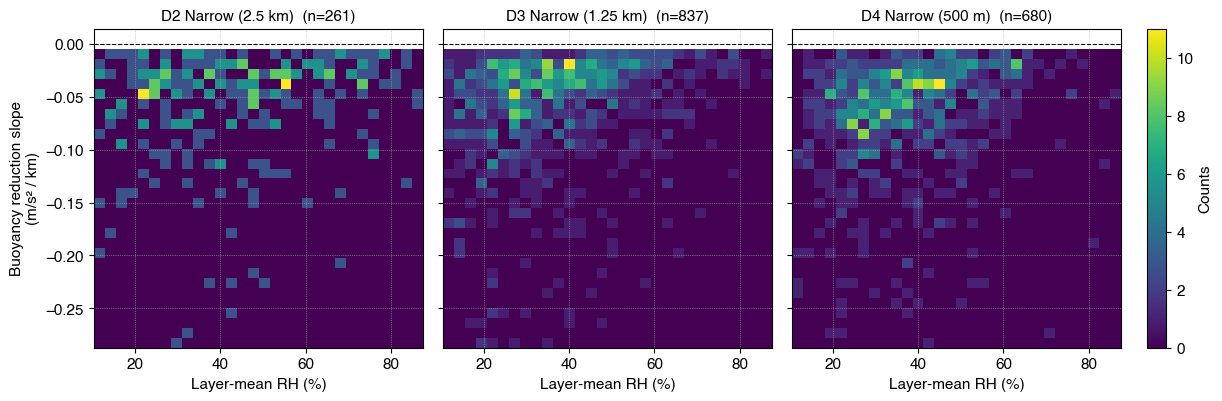

In [34]:
# Joint histogram: layer-mean RH (x) vs buoyancy reduction slope (y) — narrow cells
fontsize = 11
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.facecolor'] = 'white'

data_list = [
    (rh_layer_narrow_d2, buoyslopes_narrow_d2, 'D2 Narrow (2.5 km)'),
    (rh_layer_narrow_d3, buoyslopes_narrow_d3, 'D3 Narrow (1.25 km)'),
    (rh_layer_narrow_d4, buoyslopes_narrow_d4, 'D4 Narrow (500 m)'),
    # (rh600_narrow_d2, buoyslopes_narrow_d2, 'D2 Narrow (2.5 km)'),
    # (rh600_narrow_d3, buoyslopes_narrow_d3, 'D3 Narrow (1.25 km)'),
    # (rh600_narrow_d4, buoyslopes_narrow_d4, 'D4 Narrow (500 m)'),
]

# Common bin edges (share x and y ranges across panels)
all_rh     = np.concatenate([rh_layer_narrow_d2, rh_layer_narrow_d3, rh_layer_narrow_d4])
all_slopes = np.concatenate([buoyslopes_narrow_d2,  buoyslopes_narrow_d3,  buoyslopes_narrow_d4])
rh_bins    = np.linspace(np.nanpercentile(all_rh,     1), np.nanpercentile(all_rh,     99), 31)
slope_bins = np.linspace(np.nanpercentile(all_slopes, 1), np.nanpercentile(all_slopes, 99), 31)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
# fig, axes = plt.subplots(2, 3, figsize=(13, 9), sharey=True)
fig.subplots_adjust(wspace=0.06, right=0.87, left=0.08, bottom=0.14, top=0.90)

pcm = None
for ax, (rh_vals, slope_vals, label) in zip(axes, data_list):
    counts, xe, ye = np.histogram2d(rh_vals, slope_vals, bins=[rh_bins, slope_bins])
    pcm = ax.pcolormesh(xe, ye, counts.T, cmap='viridis')
    ax.set_xlabel('Layer-mean RH (%)', fontsize=fontsize)
    ax.set_title(f'{label}  (n={len(slope_vals)})', fontsize=fontsize)
    ax.grid(ls=':', lw=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--')

axes[0].set_ylabel('Buoyancy reduction slope\n(m/s² / km)', fontsize=fontsize)

# Shared colorbar on the right
cbar_ax = fig.add_axes([0.89, 0.14, 0.015, 0.76])
fig.colorbar(pcm, cax=cbar_ax, label='Counts')

# figname = f'{figdir}buoy_slope_vs_rh_narrow_joint_hist_d2_d3_d4.png'
# fig.savefig(figname, bbox_inches='tight', dpi=150, facecolor='w')
# print(figname)

In [35]:
# # Joint histogram: layer-mean θe difference (x) vs buoyancy reduction slope (y) — narrow cells
# fontsize = 11
# mpl.rcParams['font.size'] = fontsize
# mpl.rcParams['figure.facecolor'] = 'white'

# data_list = [
#     (thetae_diff_n_d2, buoyslopes_narrow_d2, 'D2 Narrow (2.5 km)'),
#     (thetae_diff_n_d3, buoyslopes_narrow_d3, 'D3 Narrow (1.25 km)'),
#     (thetae_diff_n_d4, buoyslopes_narrow_d4, 'D4 Narrow (500 m)'),
#     # (rh600_narrow_d2, buoyslopes_narrow_d2, 'D2 Narrow (2.5 km)'),
#     # (rh600_narrow_d3, buoyslopes_narrow_d3, 'D3 Narrow (1.25 km)'),
#     # (rh600_narrow_d4, buoyslopes_narrow_d4, 'D4 Narrow (500 m)'),
# ]

# # Common bin edges (share x and y ranges across panels)
# all_thetae     = np.concatenate([thetae_diff_n_d2, thetae_diff_n_d3, thetae_diff_n_d4])
# all_slopes = np.concatenate([buoyslopes_narrow_d2,  buoyslopes_narrow_d3,  buoyslopes_narrow_d4])
# thetae_bins    = np.linspace(np.nanpercentile(all_thetae,     1), np.nanpercentile(all_thetae,     99), 31)
# slope_bins = np.linspace(np.nanpercentile(all_slopes, 1), np.nanpercentile(all_slopes, 99), 31)

# fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
# # fig, axes = plt.subplots(2, 3, figsize=(13, 9), sharey=True)
# fig.subplots_adjust(wspace=0.06, right=0.87, left=0.08, bottom=0.14, top=0.90)

# pcm = None
# for ax, (thetae_vals, slope_vals, label) in zip(axes, data_list):
#     counts, xe, ye = np.histogram2d(thetae_vals, slope_vals, bins=[thetae_bins, slope_bins])
#     pcm = ax.pcolormesh(xe, ye, counts.T, cmap='viridis')
#     ax.set_xlabel('Layer-mean θe difference (K)', fontsize=fontsize)
#     ax.set_title(f'{label}  (n={len(slope_vals)})', fontsize=fontsize)
#     ax.grid(ls=':', lw=0.5)
#     ax.axhline(0, color='k', lw=0.8, ls='--')

# axes[0].set_ylabel('Buoyancy reduction slope\n(m/s² / km)', fontsize=fontsize)

# # Shared colorbar on the right
# cbar_ax = fig.add_axes([0.89, 0.14, 0.015, 0.76])
# fig.colorbar(pcm, cax=cbar_ax, label='Counts')

In [36]:
def mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=None, bin_range=None, cmaps=None, cbar_labels=None, kde_levels=None, kde_colors=None, 
                wspace=None, hspace=None, reg_xbins=None, plot1to1=False, xticks=None, yticks=None, legend_loc='best',
                xlims=None, ylims=None, xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None, dpi=None, min_bin_count=5):
    mpl.rcParams['font.size'] = fontsize

    scatter_kws = {'s':16, 'color':'k'}
    line_kws = {'color':'r', 'linewidth':4}

    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = wspace
    hspace = hspace
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)

    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if variable is None
            df = dfs[row][col]
            if (df is not None):
                # Setup two columns (left: plot, right: colorbar)
                gss = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row,col], height_ratios=[1], width_ratios=[1,0.02], wspace=0.02, hspace=0.)
                ax = plt.subplot(gss[0])
                # Colorbar
                cax = plt.subplot(gss[1])
                # Heatmap
                sns.histplot(x=x_name[row][col], y=y_name[row][col], data=df, bins=bins_hist[row][col],
                            binrange=bin_range[row][col], pthresh=.1, cmap=cmaps[row][col], 
                            cbar=True, cbar_kws={'label':cbar_labels[row][col]}, cbar_ax=cax, ax=ax, )
                # KDE
                sns.kdeplot(x=x_name[row][col], y=y_name[row][col], data=df, levels=kde_levels[row][col], color=kde_colors[row][col], linewidths=1, ax=ax)
                # Linear regression
                mask = ~np.isnan(df[x_name[row][col]]) & ~np.isnan(df[y_name[row][col]])
                linfit = linregress(x=df[x_name[row][col]][mask], y=df[y_name[row][col]][mask])
                # yfit line values (bin_range is a pair of tuples for x & y axis, take [0] for x-axis)
                xfit = np.linspace(min(bin_range[row][col][0]), max(bin_range[row][col][0]), 100)
                yfit = linfit[0] * xfit + linfit[1]
                # yfit_label = f"Corr: {linfit[2]:.02f}, p: {linfit[3]:.02f}"
                # yfit_label = f"Corr: {linfit[2]:.02f}"
                # yfit_label = f"y={linfit[0]:.1f}x+{linfit[1]:.1f} (r={linfit[2]:.02f})"
                yfit_label = f"Slope: {linfit[0]:.3f} (r={linfit[2]:.02f})"
                # ax.plot(xfit, yfit, color=line_kws['color'], lw=line_kws['linewidth'], label=yfit_label, zorder=10)
                # Binned regression: bin y by x bins, fit line through bin means
                _n_xbins = len(reg_xbins[row][col]) if (reg_xbins is not None and reg_xbins[row][col] is not None) else 10
                _xmin = min(bin_range[row][col][0])
                _xmax = max(bin_range[row][col][0])
                _bin_edges = np.linspace(_xmin, _xmax, _n_xbins + 1)
                _xv = df[x_name[row][col]][mask].values
                _yv = df[y_name[row][col]][mask].values
                _bidx = np.digitize(_xv, _bin_edges)
                _bx, _by = [], []
                for _b in range(1, _n_xbins + 1):
                    _in = _bidx == _b
                    if _in.sum() >= min_bin_count:
                        _bx.append(np.nanmean(_xv[_in]))
                        _by.append(np.nanmean(_yv[_in]))
                if len(_bx) >= 2:
                    _bc = np.polyfit(_bx, _by, 1)
                    _yfit2 = _bc[0] * xfit + _bc[1]
                    ax.plot(xfit, _yfit2, color=line_kws['color'], lw=line_kws['linewidth'], ls='-',
                            label=f'Slope: {_bc[0]:.1e}', zorder=10)
                # Regression plot
                sns.regplot(x=x_name[row][col], y=y_name[row][col], data=df,
                            # y_jitter=0.4,
                            x_estimator=np.nanmean, x_bins=reg_xbins[row][col], truncate=True,
                            ci=95, x_ci='ci',
                            scatter_kws=scatter_kws, line_kws=line_kws, fit_reg=False, ax=ax)
                ax.legend(loc=legend_loc)
                # Axes, labels
                if xlims is not None: ax.set_xlim(min(xlims[row][col]),max(xlims[row][col]))
                if ylims is not None: ax.set_ylim(min(ylims[row][col]),max(ylims[row][col]))
                if xticks is not None: ax.set_xticks(xticks[row][col])
                if yticks is not None: ax.set_yticks(yticks[row][col])
                ax.grid(ls='--')
                ax.set_title(titles[row][col], loc='left', weight='bold')
                ax.set_xlabel(xlabels[row][col])
                ax.set_ylabel(ylabels[row][col])
                # Plot 1-to-1 line
                if plot1to1: ax.plot((xlims[row][col][0],xlims[row][col][1]),(ylims[row][col][0],ylims[row][col][1]), color='k')
                
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

In [37]:
names = ['Layer-Mean RH', 'Buoyancy Reduction Rate']
df_n_d2 = pd.DataFrame(columns = names)
df_n_d2['Layer-Mean RH'] = rh_layer_narrow_d2
df_n_d2['Buoyancy Reduction Rate'] = buoyslopes_narrow_d2
df_n_d2['600-hPa RH'] = rh600_narrow_d2
df_n_d2['Layer-Mean '+r'$\Delta\theta_e$'] = thetae_diff_n_d2

df_n_d3 = pd.DataFrame(columns = names)
df_n_d3['Layer-Mean RH'] = rh_layer_narrow_d3
df_n_d3['Buoyancy Reduction Rate'] = buoyslopes_narrow_d3
df_n_d3['600-hPa RH'] = rh600_narrow_d3
df_n_d3['Layer-Mean '+r'$\Delta\theta_e$'] = thetae_diff_n_d3

df_n_d4 = pd.DataFrame(columns = names)
df_n_d4['Layer-Mean RH'] = rh_layer_narrow_d4
df_n_d4['Buoyancy Reduction Rate'] = buoyslopes_narrow_d4
df_n_d4['600-hPa RH'] = rh600_narrow_d4
df_n_d4['Layer-Mean '+r'$\Delta\theta_e$'] = thetae_diff_n_d4

In [38]:
df_w_d2 = pd.DataFrame(columns = names)
df_w_d2['Layer-Mean RH'] = rh_layer_wide_d2
df_w_d2['Buoyancy Reduction Rate'] = buoyslopes_wide_d2

df_w_d3 = pd.DataFrame(columns = names)
df_w_d3['Layer-Mean RH'] = rh_layer_wide_d3
df_w_d3['Buoyancy Reduction Rate'] = buoyslopes_wide_d3

df_w_d4 = pd.DataFrame(columns = names)
df_w_d4['Layer-Mean RH'] = rh_layer_wide_d4
df_w_d4['Buoyancy Reduction Rate'] = buoyslopes_wide_d4

/Users/feng045/tmp/narrow_wide_CI30min/regplot_LayerRH_MaxBuoyTrhoReductionRate_d2_d3_d4_narrow.pdf


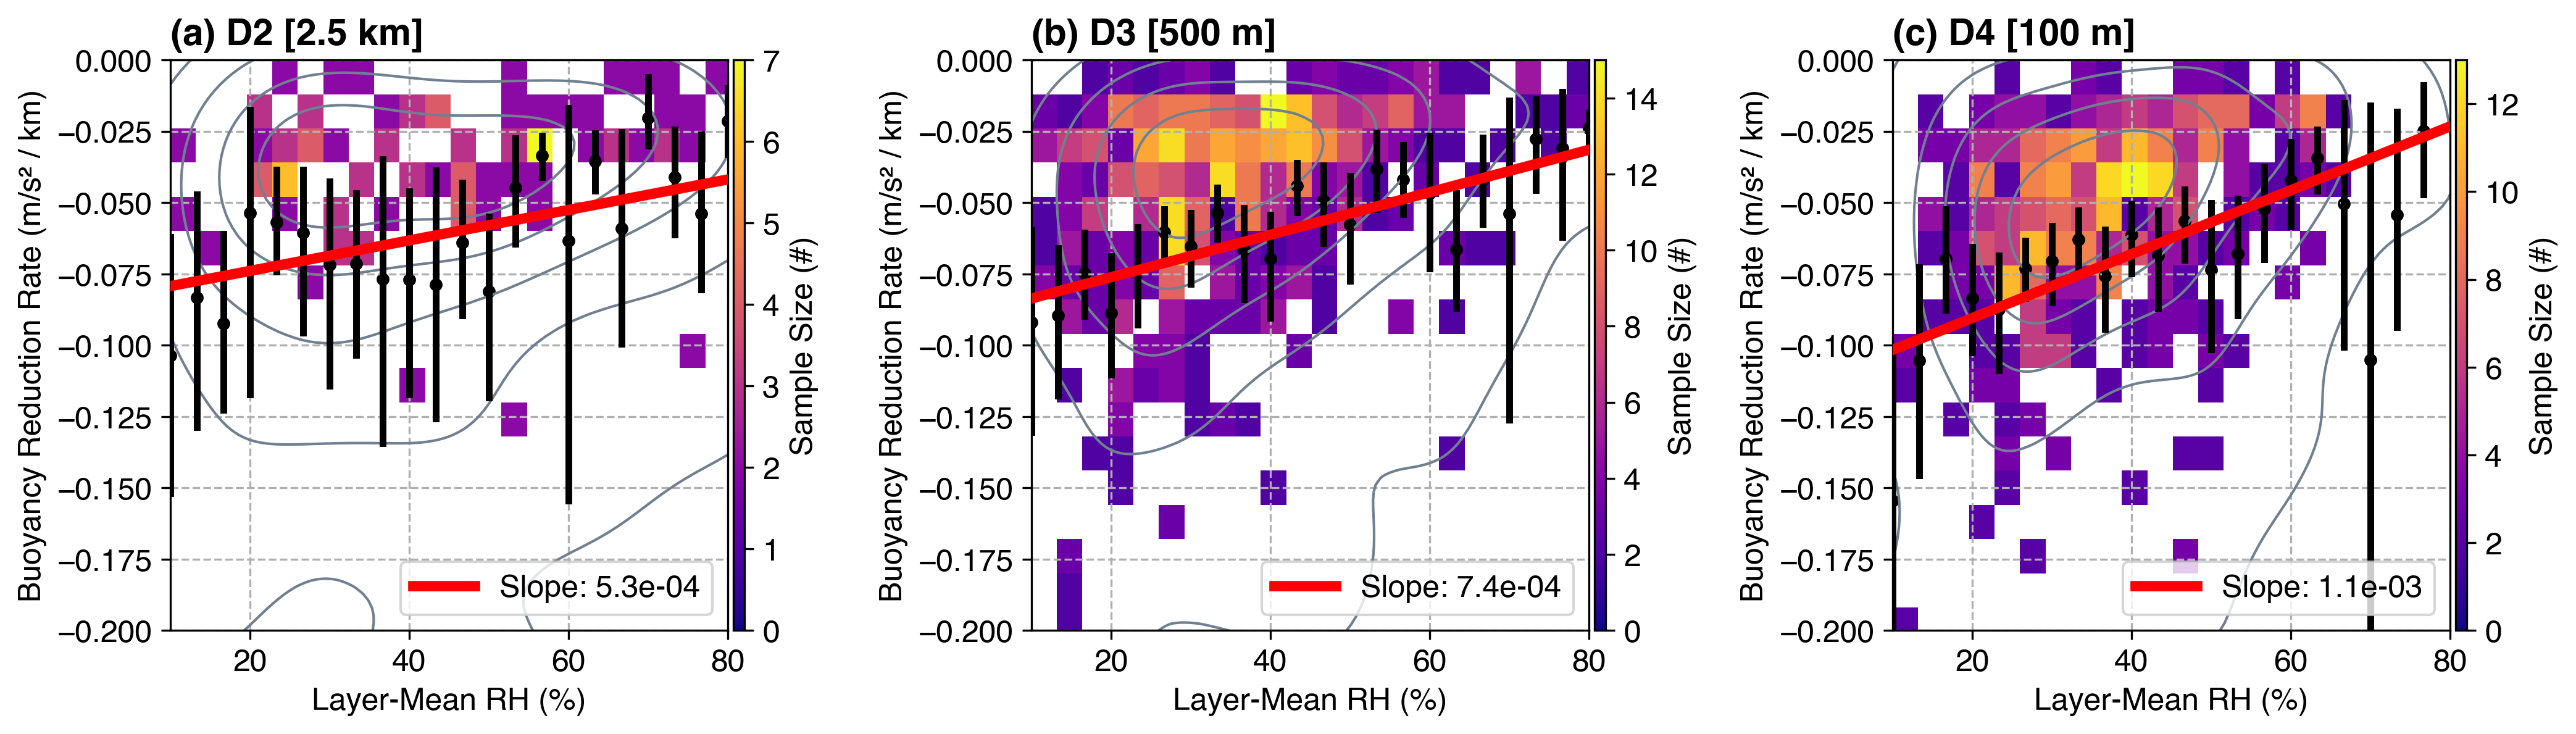

In [39]:
dfs = [[df_n_d2, df_n_d3, df_n_d4]]
nrow = len(dfs)
ncol = len(dfs[0])

x_name = [['Layer-Mean RH']*ncol, ['Layer-Mean RH']*ncol]
y_name = [['Buoyancy Reduction Rate']*ncol, ['Buoyancy Reduction Rate']*ncol]

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3], [x_bins1, x_bins2, x_bins3]]

# Common bin edges (share x and y ranges across panels)
all_rh     = np.concatenate([rh_layer_narrow_d2, rh_layer_narrow_d3, rh_layer_narrow_d4])
all_slopes = np.concatenate([buoyslopes_narrow_d2,  buoyslopes_narrow_d3,  buoyslopes_narrow_d4])
rh_bins    = np.linspace(np.nanpercentile(all_rh,     1), np.nanpercentile(all_rh,     99), 31)
slope_bins = np.linspace(np.nanpercentile(all_slopes, 1), np.nanpercentile(all_slopes, 99), 31)

bin_range = [[((10,90),(-0.30,0))]*ncol, [((10,90),(-0.30,0))]*ncol]

cmaps = [['plasma']*ncol, ['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol, ['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol, [6]*ncol]
kde_colors = [["slategrey"]*ncol, ["slategrey"]*ncol]
# Regression plot
# reg_xbins1 = np.linspace(min(bin_range[0][0]), max(bin_range[0][0]), x_bins1)
reg_xbins1 = np.linspace(min(bin_range[0][0][0]), max(bin_range[0][0][0]), x_bins1)
reg_xbins = [[reg_xbins1]*ncol, [reg_xbins1]*ncol]
legend_loc = 'lower right'
# Axes, labels
xlims = [[(10,80)]*ncol, [(10,80)]*ncol]
ylims = [[(-0.20,0)]*ncol, [(-0.20,0)]*ncol]
xlabels = [['Layer-Mean RH (%)']*ncol, ['Layer-Mean RH (%)']*ncol]
ylabels = [['Buoyancy Reduction Rate (m/s² / km)']*ncol, ['Buoyancy Reduction Rate (m/s² / km)']*ncol]
titles = [[f'(a) D2 [2.5 km]', f'(b) D3 [500 m]', f'(c) D4 [100 m]']]

# Figure
fontsize = 12
figsize = (16,4)
figname = f'{figdir}regplot_LayerRH_MaxBuoyTrhoReductionRate_d2_d3_d4_narrow.pdf'
wspace = 0.5
hspace = 0.3
dpi = 300
print(figname)
fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins, legend_loc=legend_loc,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

/Users/feng045/tmp/narrow_wide_CI30min/regplot_RH600hPa_MaxBuoyTrhoReductionRate_d2_d3_d4_narrow.pdf


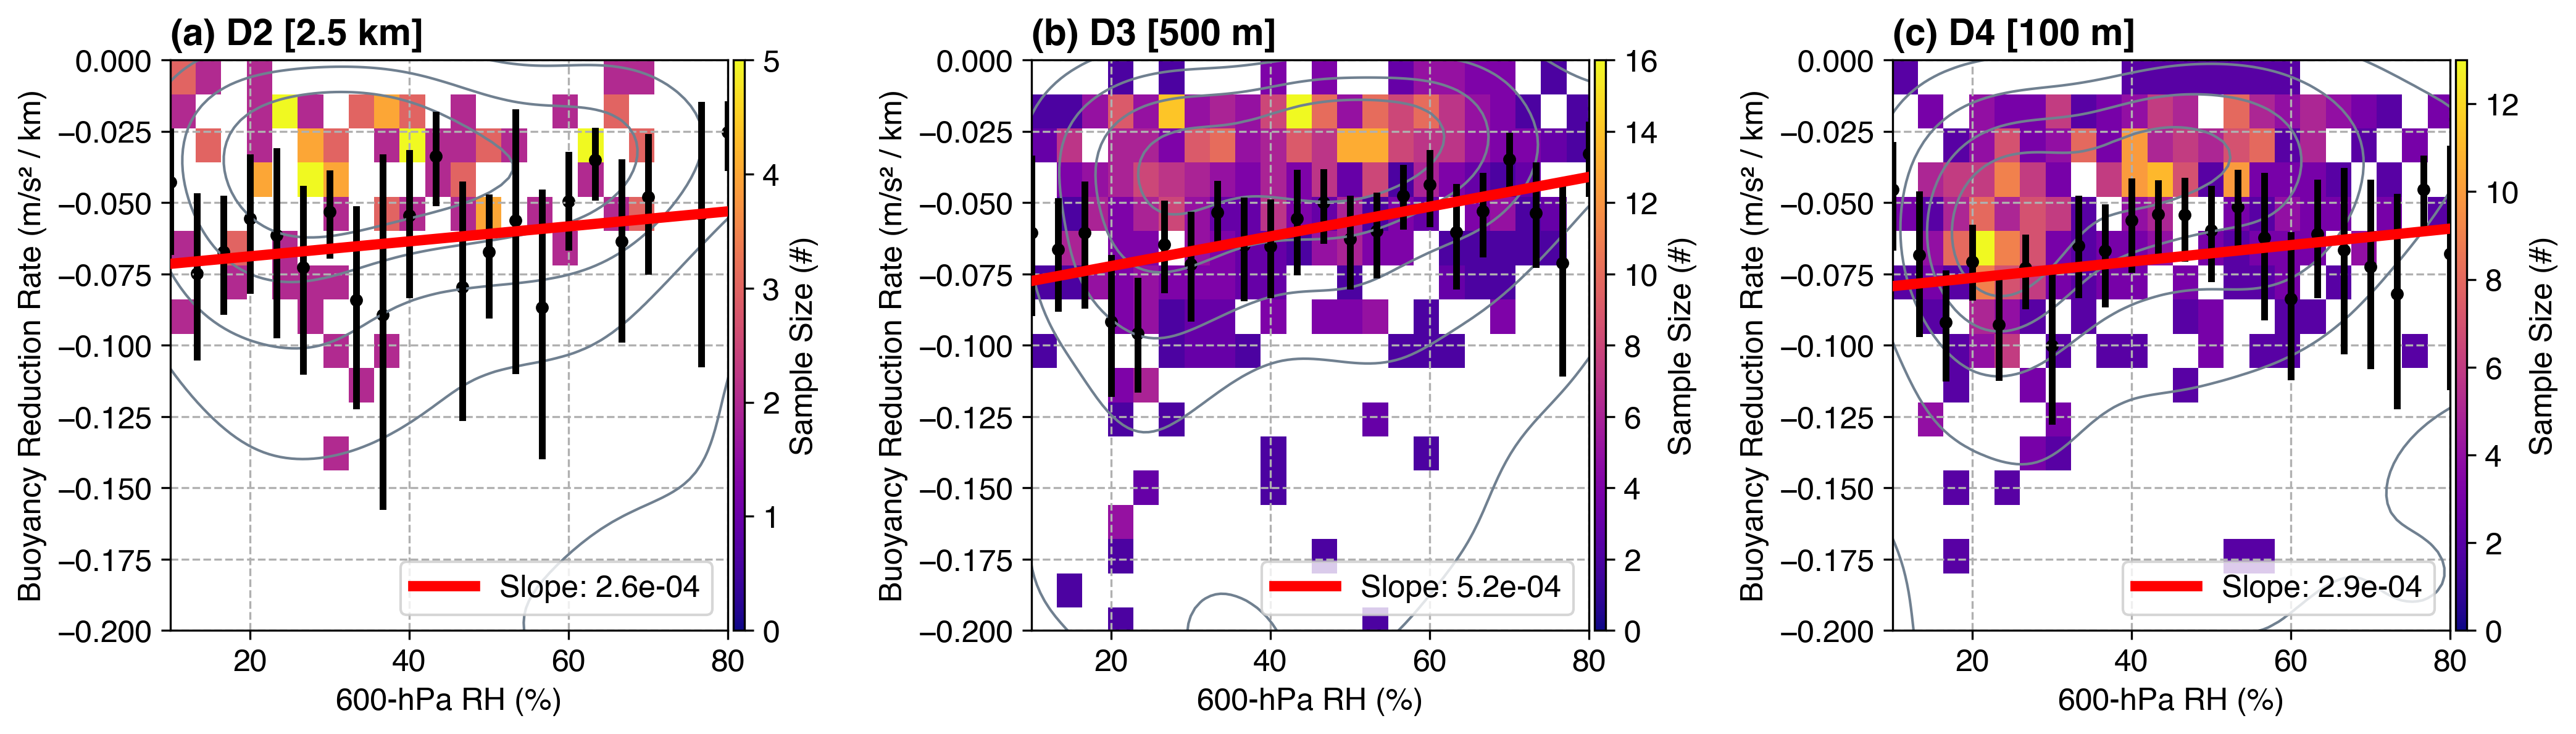

In [40]:
dfs = [[df_n_d2, df_n_d3, df_n_d4]]
nrow = len(dfs)
ncol = len(dfs[0])

x_name = [['600-hPa RH']*ncol, ['600-hPa RH']*ncol]
y_name = [['Buoyancy Reduction Rate']*ncol, ['Buoyancy Reduction Rate']*ncol]

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3], [x_bins1, x_bins2, x_bins3]]

# Common bin edges (share x and y ranges across panels)
all_rh     = np.concatenate([rh_layer_narrow_d2, rh_layer_narrow_d3, rh_layer_narrow_d4])
all_slopes = np.concatenate([buoyslopes_narrow_d2,  buoyslopes_narrow_d3,  buoyslopes_narrow_d4])
rh_bins    = np.linspace(np.nanpercentile(all_rh,     1), np.nanpercentile(all_rh,     99), 31)
slope_bins = np.linspace(np.nanpercentile(all_slopes, 1), np.nanpercentile(all_slopes, 99), 31)

bin_range = [[((10,90),(-0.30,0))]*ncol, [((10,90),(-0.30,0))]*ncol]

cmaps = [['plasma']*ncol, ['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol, ['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol, [6]*ncol]
kde_colors = [["slategrey"]*ncol, ["slategrey"]*ncol]
# Regression plot
# reg_xbins1 = np.linspace(min(bin_range[0][0]), max(bin_range[0][0]), x_bins1)
reg_xbins1 = np.linspace(min(bin_range[0][0][0]), max(bin_range[0][0][0]), x_bins1)
reg_xbins = [[reg_xbins1]*ncol, [reg_xbins1]*ncol]
legend_loc = 'lower right'
# Axes, labels
xlims = [[(10,80)]*ncol, [(10,80)]*ncol]
ylims = [[(-0.20,0)]*ncol, [(-0.20,0)]*ncol]
xlabels = [['600-hPa RH (%)']*ncol, ['600-hPa RH (%)']*ncol]
ylabels = [['Buoyancy Reduction Rate (m/s² / km)']*ncol, ['Buoyancy Reduction Rate (m/s² / km)']*ncol]
titles = [[f'(a) D2 [2.5 km]', f'(b) D3 [500 m]', f'(c) D4 [100 m]']]

# Figure
fontsize = 12
figsize = (16,4)
figname = f'{figdir}regplot_RH600hPa_MaxBuoyTrhoReductionRate_d2_d3_d4_narrow.pdf'
wspace = 0.5
hspace = 0.3
dpi = 300
print(figname)
fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins, legend_loc=legend_loc,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

/Users/feng045/tmp/narrow_wide_CI30min/regplot_LayerRH_MaxBuoyTrhoReductionRate_d2_d3_d4.png


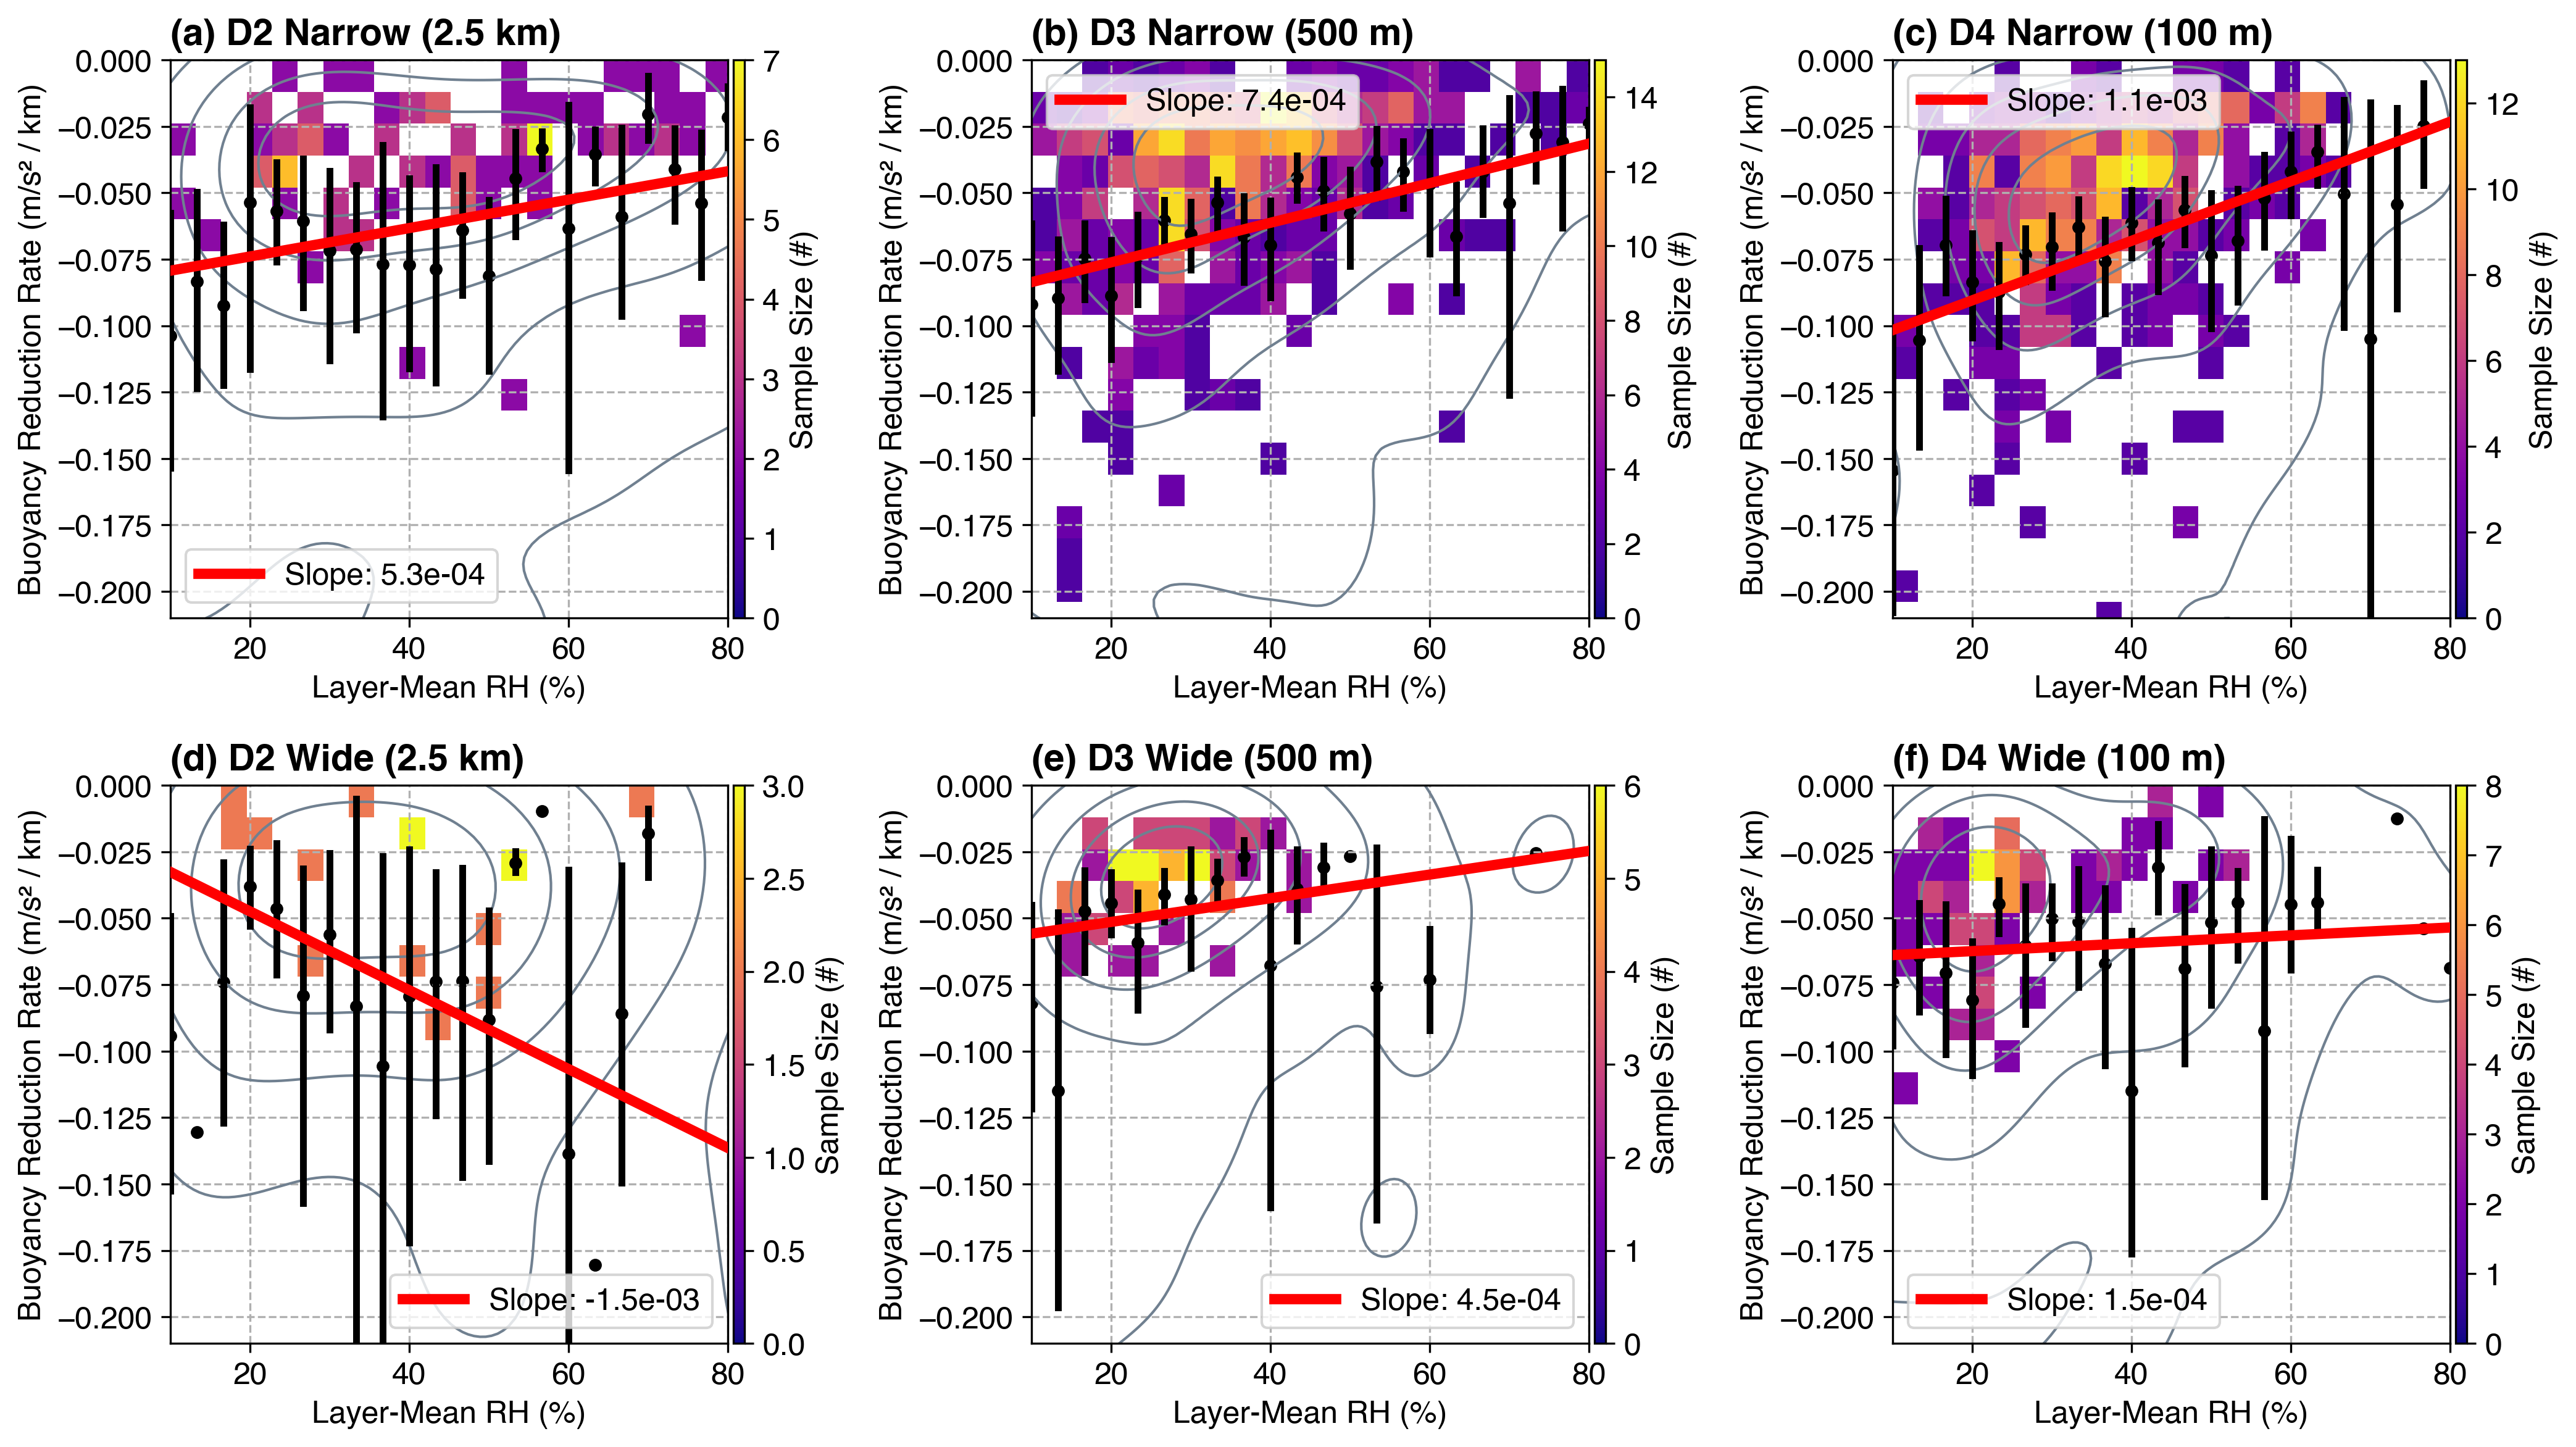

In [41]:
dfs = [[df_n_d2, df_n_d3, df_n_d4], [df_w_d2, df_w_d3, df_w_d4]]
# dfs = [[df_n_d2, df_n_d3, df_n_d4]]
nrow = len(dfs)
ncol = len(dfs[0])

x_name = [['Layer-Mean RH']*ncol, ['Layer-Mean RH']*ncol]
y_name = [['Buoyancy Reduction Rate']*ncol, ['Buoyancy Reduction Rate']*ncol]

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3], [x_bins1, x_bins2, x_bins3]]

# Common bin edges (share x and y ranges across panels)
all_rh     = np.concatenate([rh_layer_narrow_d2, rh_layer_narrow_d3, rh_layer_narrow_d4])
all_slopes = np.concatenate([buoyslopes_narrow_d2,  buoyslopes_narrow_d3,  buoyslopes_narrow_d4])
rh_bins    = np.linspace(np.nanpercentile(all_rh,     1), np.nanpercentile(all_rh,     99), 31)
slope_bins = np.linspace(np.nanpercentile(all_slopes, 1), np.nanpercentile(all_slopes, 99), 31)

bin_range = [[((10,90),(-0.30,0))]*ncol, [((10,90),(-0.30,0))]*ncol]

cmaps = [['plasma']*ncol, ['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol, ['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol, [6]*ncol]
kde_colors = [["slategrey"]*ncol, ["slategrey"]*ncol]
# Regression plot
reg_xbins1 = np.linspace(min(bin_range[0][0][0]), max(bin_range[0][0][0]), x_bins1)
reg_xbins = [[reg_xbins1]*ncol, [reg_xbins1]*ncol]
# Axes, labels
xlims = [[(10,80)]*ncol, [(10,80)]*ncol]
ylims = [[(-0.21,0)]*ncol, [(-0.21,0)]*ncol]
xlabels = [['Layer-Mean RH (%)']*ncol, ['Layer-Mean RH (%)']*ncol]
ylabels = [['Buoyancy Reduction Rate (m/s² / km)']*ncol, ['Buoyancy Reduction Rate (m/s² / km)']*ncol]
titles = [['(a) D2 Narrow (2.5 km)', '(b) D3 Narrow (500 m)', '(c) D4 Narrow (100 m)'], ['(d) D2 Wide (2.5 km)', '(e) D3 Wide (500 m)', '(f) D4 Wide (100 m)']]

# Figure
fontsize = 12
figsize = (16,9)
figname = f'{figdir}regplot_LayerRH_MaxBuoyTrhoReductionRate_d2_d3_d4.png'
wspace = 0.5
hspace = 0.3
dpi = 300
print(figname)
fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

/Users/feng045/tmp/narrow_wide_CI30min/regplot_LayerMeanDeltaThetae_MaxBuoyTrhoReductionRate_d2_d3_d4_narrow.pdf


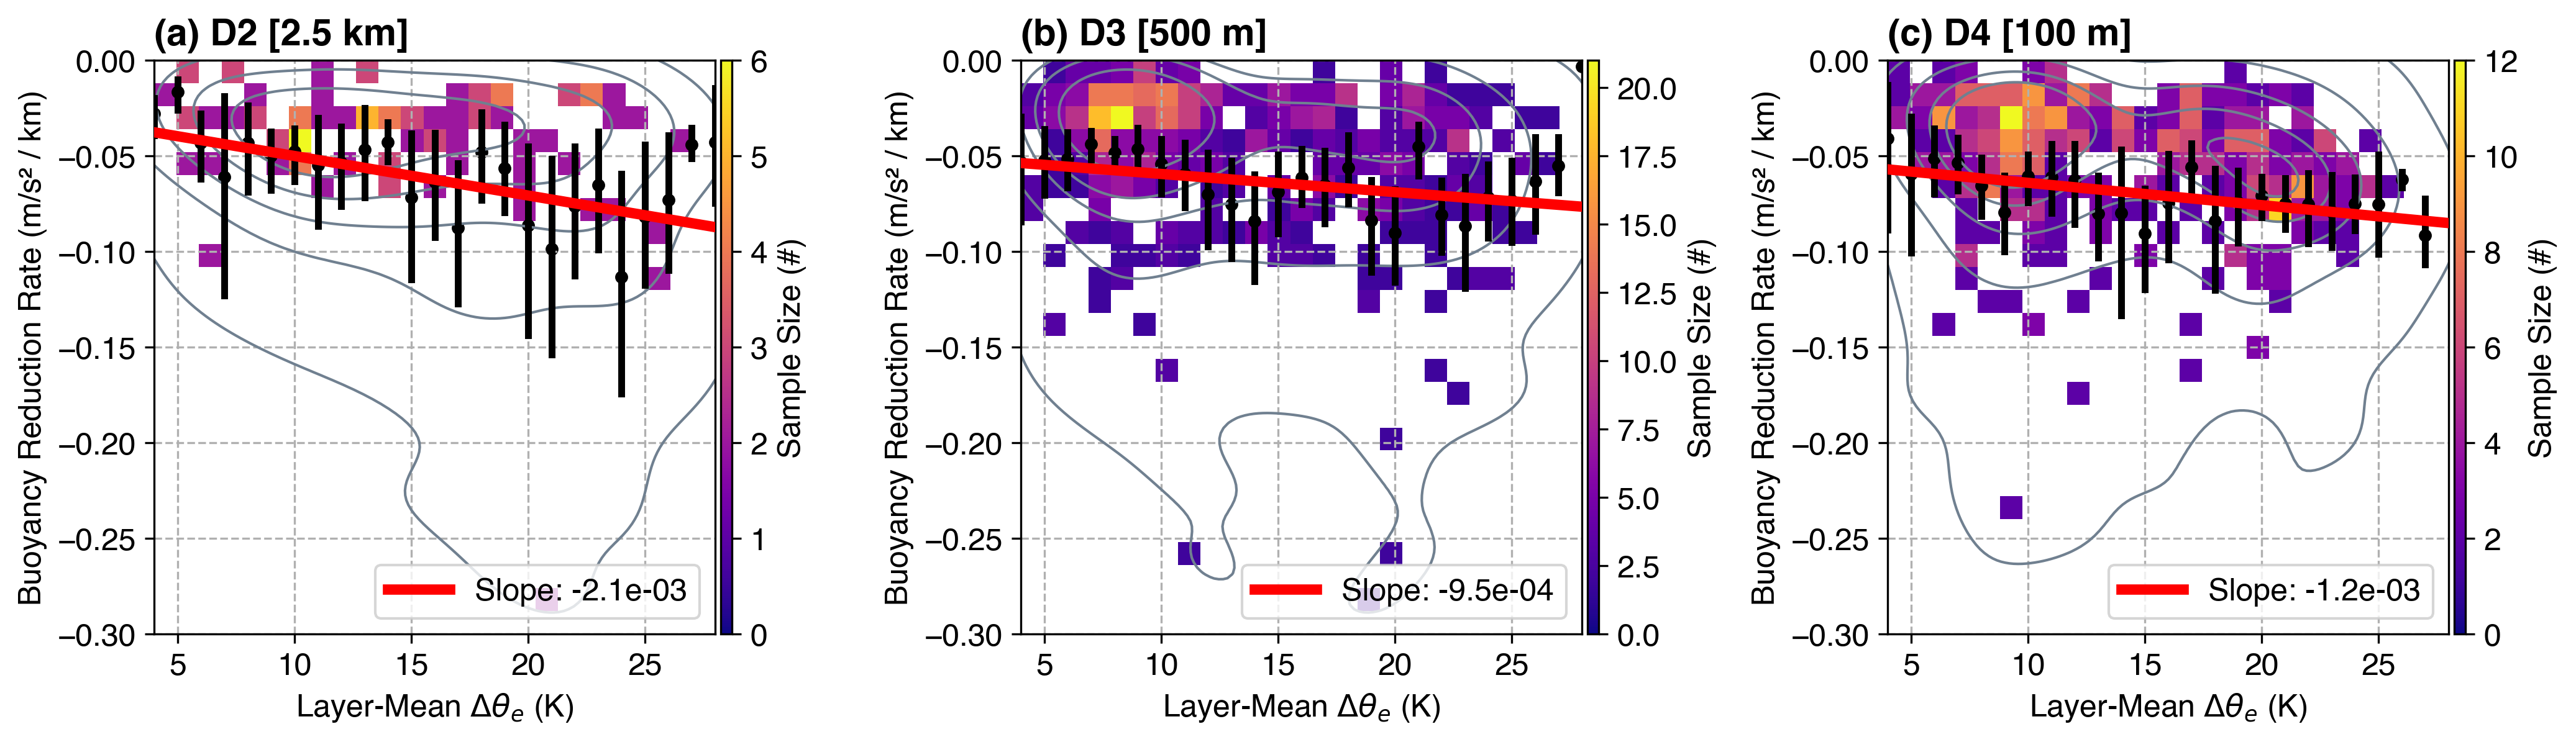

In [42]:
dfs = [[df_n_d2, df_n_d3, df_n_d4]]
nrow = len(dfs)
ncol = len(dfs[0])

x_name = [['Layer-Mean '+r'$\Delta\theta_e$']*ncol, ['Layer-Mean '+r'$\Delta\theta_e$']*ncol]
y_name = [['Buoyancy Reduction Rate']*ncol, ['Buoyancy Reduction Rate']*ncol]

# Histogram
x_bins1 = 25
x_bins2 = 25
x_bins3 = 25
bins_hist = [[x_bins1, x_bins2, x_bins3], [x_bins1, x_bins2, x_bins3]]

# Common bin edges (share x and y ranges across panels)
all_thetae = np.concatenate([thetae_diff_n_d2, thetae_diff_n_d3, thetae_diff_n_d4])
all_slopes = np.concatenate([buoyslopes_narrow_d2,  buoyslopes_narrow_d3,  buoyslopes_narrow_d4])
thetae_bins = np.linspace(np.nanpercentile(all_thetae, 1), np.nanpercentile(all_thetae, 99), 31)
slope_bins = np.linspace(np.nanpercentile(all_slopes, 1), np.nanpercentile(all_slopes, 99), 31)

bin_range = [[((4,28),(-0.30,0))]*ncol, [((4,28),(-0.30,0))]*ncol]

cmaps = [['plasma']*ncol, ['plasma']*ncol]
cbar_labels = [['Sample Size (#)']*ncol, ['Sample Size (#)']*ncol]
# KDE
kde_levels = [[6]*ncol, [6]*ncol]
kde_colors = [["slategrey"]*ncol, ["slategrey"]*ncol]
# Regression plot
# reg_xbins1 = np.linspace(min(bin_range[0][0]), max(bin_range[0][0]), x_bins1)
reg_xbins1 = np.linspace(min(bin_range[0][0][0]), max(bin_range[0][0][0]), x_bins1)
reg_xbins = [[reg_xbins1]*ncol, [reg_xbins1]*ncol]
legend_loc = 'lower right'
# Axes, labels
xlims = [[(4,28)]*ncol, [(4,28)]*ncol]
ylims = [[(-0.30,0)]*ncol, [(-0.30,0)]*ncol]
xlabels = [['Layer-Mean '+r'$\Delta\theta_e$'+' (K)']*ncol, ['Layer-Mean '+r'$\Delta\theta_e$'+' (K)']*ncol]
ylabels = [['Buoyancy Reduction Rate (m/s² / km)']*ncol, ['Buoyancy Reduction Rate (m/s² / km)']*ncol]
titles = [[f'(a) D2 [2.5 km]', f'(b) D3 [500 m]', f'(c) D4 [100 m]']]

# Figure
fontsize = 12
figsize = (16,4)
figname = f'{figdir}regplot_LayerMeanDeltaThetae_MaxBuoyTrhoReductionRate_d2_d3_d4_narrow.pdf'
wspace = 0.5
hspace = 0.3
dpi = 300
print(figname)
fig = mxn_regplot(nrow, ncol, dfs, x_name, y_name, bins_hist=bins_hist, bin_range=bin_range, cmaps=cmaps, cbar_labels=cbar_labels, kde_levels=kde_levels, kde_colors=kde_colors, 
                  wspace=wspace, hspace=hspace, reg_xbins=reg_xbins, legend_loc=legend_loc,
                  xlims=xlims, ylims=ylims, xlabels=xlabels, ylabels=ylabels, titles=titles, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)

## Composite updraft profiles by aligning to cloud base, and group by ETH bins

In [43]:
def updraft_prof_cbase_nbins(ds, varname, operation=None, filter_Wmask=True, filter_muparcelht=True, quantiles=[0.25,0.5,0.75], nbins_ETH=None, return_ncell=False):
    
    # # Get dates
    # dates = ds.date
    # # Height coordinate for updraft variables
    # height_core = ds.z
    # Interpolated height coordinate [m]
    height_core_interp = np.arange(0, 20000.1, 200)

    # Get quantile-based bin edges for ETH
    # ETH_bins = np.quantile(ds["CImaxETH_10dbz"], np.linspace(0, 1, nbins_ETH + 1))
    # CImaxWTH = ds["Wtop"].max(dim='times')
    # ETH_bins = np.quantile(CImaxWTH, np.linspace(0, 1, nbins_ETH + 1))

    # Use Pandas qcut to produce equal-count bins
    # q=4 -> 4 equal-frequency bins; retbins=True returns the edges
    ETH_quantiles = np.linspace(0, 1, nbins_ETH + 1)
    # Convert DataArray to Pandas series
    s = pd.Series(ds["CImaxETH_10dbz"]).dropna()
    # Add a tiny reproducible jitter
    rng = np.random.RandomState(42)                # fixed seed for reproducibility
    eps = 1e-6 * (s.max() - s.min() + 1)          # tiny jitter scale relative to data range
    s_jitter = s + rng.uniform(-eps, eps, size=len(s))

    labels, ETH_bins = pd.qcut(s_jitter, q=ETH_quantiles, retbins=True)
    # top edges are ETH_bins[1:]
    ETH_bins_top = ETH_bins[1:]
    
    # Note: Wbase/Wtop unit is [km], convert to [m] to match original height coordinate
    # Average updraft base height
    Wbase_avg = ds['Wbase'].isel(times=slice(W_tidx_start, W_tidx_end)).mean(dim='times')*1000
    # Max updraft top height
    Wtop_max = ds['Wtop'].isel(times=slice(W_tidx_start, W_tidx_end)).max(dim='times')*1000
    # Cloud depth
    Wdepth = Wtop_max - Wbase_avg

    # Get variable from DataSet, mask with updraft mask, subset CI-period: filter heights below MU parcel height
    if filter_Wmask:
        VAR = ds[varname].where(ds["Wmask"] == True).isel(times=slice(W_tidx_start, W_tidx_end))
    else:
        VAR = ds[varname].isel(times=slice(W_tidx_start, W_tidx_end))

    VAR_mean_out = []
    VAR_inqt_out = []
    ns_prof_out = []
    Wdepth_mean_out = []
    Wdepth_inqt_out = []
    ntracks_out = []

    # Loop over each ETH bin
    for ii in range(nbins_ETH):
        # Make mask for the ETH bin
        mask = (ds["CImaxETH_10dbz"] >= ETH_bins[ii]) & (ds["CImaxETH_10dbz"] < ETH_bins[ii+1])

        # Use getattr to call the operation dynamically (e.g., operation: 'max', 'mean')
        VAR_s = getattr(VAR, operation)(dim=('times')).where(mask, drop=True)
        Wbase_s = Wbase_avg.where(mask, drop=True)
        Wdepth_s = Wdepth.where(mask, drop=True)
        # Save number of cells after filter
        ntracks_out.append(VAR_s.sizes['tracks'])
        # print(VAR_s.sizes['tracks'])
        
        # Interpolate VAR to constant-spaced height
        VAR_s_interp = VAR_s.interp(z=height_core_interp)

        # Broadcast Wbase to match the VAR shape
        _Wbase_s = Wbase_s.broadcast_like(VAR_s_interp)
        
        # Shift the height coordinate by Wbase height, the new coordinate 'z' will be 2D [z,tracks]
        VAR_s_shifted = VAR_s_interp.assign_coords({'z':(VAR_s_interp.coords['z'] - _Wbase_s)})
        # VAR_d_shifted = VAR_d_interp.assign_coords({'z':(VAR_d_interp.coords['z'] - _Wbase_d)})
        VAR_s_shifted['z'].attrs = {'units':'m'}
        
        # Build a NaN template with the correct structure by interpolating the first valid track
        _nan_template = None
        for _track_idx in range(len(VAR_s_shifted.coords['tracks'])):
            _test = VAR_s_shifted.isel(tracks=_track_idx)
            if not np.any(np.isnan(_test.coords['z'].values)):
                _nan_template = _test.interp(z=height_core_interp)
                _nan_template = xr.full_like(_nan_template, fill_value=np.nan)
                break

        VAR_s_Wbase = []
        # Loop over each track
        for track_idx in range(len(VAR_s_shifted.coords['tracks'])):
            # Select one track at a time
            _VAR = VAR_s_shifted.isel(tracks=track_idx)
            # Guard: skip tracks where Wbase is NaN in the time window (z coord becomes all-NaN)
            # This can happen when the time window is shorter than the original (e.g., W_tidx_end < tidx_end)
            if np.any(np.isnan(_VAR.coords['z'].values)):
                if _nan_template is not None:
                    VAR_s_Wbase.append(_nan_template)
                continue
            # Interpolate again to the new common height grid
            _VAR_interp = _VAR.interp(z=height_core_interp)
            # Store the aligned profile
            VAR_s_Wbase.append(_VAR_interp)
            
        # Stack the aligned profiles along a new dimension
        VAR_s_Wbase = xr.concat(VAR_s_Wbase, dim='tracks')
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            # Compute mean
            VAR_s_mean = VAR_s_Wbase.mean(dim='tracks', keep_attrs=True)
            # Compute quantiles
            VAR_s_inqt = VAR_s_Wbase.quantile(quantiles, dim='tracks', keep_attrs=True)
            # Get sample size profiles by dates
            ns_prof_s = (~np.isnan(VAR_s_Wbase)).sum(dim='tracks')
            # Depth statistics
            Wdepth_s_mean = Wdepth_s.mean(keep_attrs=True)
            Wdepth_s_inqt = Wdepth_s.quantile(quantiles)

        # Append the profiles for output
        VAR_mean_out.append(VAR_s_mean)
        VAR_inqt_out.append(VAR_s_inqt)
        ns_prof_out.append(ns_prof_s)
        Wdepth_mean_out.append(Wdepth_s_mean)
        Wdepth_inqt_out.append(Wdepth_s_inqt)

    # Convert list to DataArray by a new dimension
    VAR_mean_out = xr.concat(VAR_mean_out, dim='ETH')
    VAR_inqt_out = xr.concat(VAR_inqt_out, dim='ETH')
    ns_prof_out = xr.concat(ns_prof_out, dim='ETH')
    Wdepth_mean_out = xr.concat(Wdepth_mean_out, dim='ETH')
    Wdepth_inqt_out = xr.concat(Wdepth_inqt_out, dim='ETH')
    # Assign coordinate
    VAR_mean_out = VAR_mean_out.assign_coords({'ETH':ETH_bins_top})
    VAR_inqt_out = VAR_inqt_out.assign_coords({'ETH':ETH_bins_top})
    ns_prof_out = ns_prof_out.assign_coords({'ETH':ETH_bins_top})
    Wdepth_mean_out = Wdepth_mean_out.assign_coords({'ETH':ETH_bins_top})
    Wdepth_inqt_out = Wdepth_inqt_out.assign_coords({'ETH':ETH_bins_top})
    
    if return_ncell:
        return VAR_mean_out, VAR_inqt_out, ns_prof_out, Wdepth_mean_out, Wdepth_inqt_out, ETH_bins, ntracks_out
    else:
        return VAR_mean_out, VAR_inqt_out, ns_prof_out, Wdepth_mean_out, Wdepth_inqt_out, ETH_bins

In [44]:
quantiles = [0.25, 0.5, 0.75]
# quantiles = [0.5]
nbins_ETH = 4
# Buoyancy
MaxCoreBuoy_n_avg_d2, MaxCoreBuoy_n_inqt_d2, nsMaxCoreBuoy_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoy_w_avg_d2, MaxCoreBuoy_w_inqt_d2, nsMaxCoreBuoy_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [45]:
# Buoyancy
MaxCoreBuoy_n_avg_d3, MaxCoreBuoy_n_inqt_d3, nsMaxCoreBuoy_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3= \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoy_w_avg_d3, MaxCoreBuoy_w_inqt_d3, nsMaxCoreBuoy_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [46]:
# Buoyancy
MaxCoreBuoy_n_avg_d4, MaxCoreBuoy_n_inqt_d4, nsMaxCoreBuoy_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoy_w_avg_d4, MaxCoreBuoy_w_inqt_d4, nsMaxCoreBuoy_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreBuoyThtv_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [47]:
# Buoyancy (based on density potential temperature)
MaxCoreBuoyTrho_n_avg_d2, MaxCoreBuoyTrho_n_inqt_d2, nsMaxCoreBuoyTrho_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoyTrho_w_avg_d2, MaxCoreBuoyTrho_w_inqt_d2, nsMaxCoreBuoyTrho_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [48]:
# Buoyancy (based on density potential temperature)
MaxCoreBuoyTrho_n_avg_d3, MaxCoreBuoyTrho_n_inqt_d3, nsMaxCoreBuoyTrho_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoyTrho_w_avg_d3, MaxCoreBuoyTrho_w_inqt_d3, nsMaxCoreBuoyTrho_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [49]:
# Buoyancy (based on density potential temperature)
MaxCoreBuoyTrho_n_avg_d4, MaxCoreBuoyTrho_n_inqt_d4, nsMaxCoreBuoyTrho_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreBuoyTrho_w_avg_d4, MaxCoreBuoyTrho_w_inqt_d4, nsMaxCoreBuoyTrho_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreBuoyTrho_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [50]:
# Core diameter
MaxCoreArea_n_avg_d2, MaxCoreArea_n_inqt_d2, nsMaxCoreDiam_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2, nCells_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)
MaxCoreArea_w_avg_d2, MaxCoreArea_w_inqt_d2, nsMaxCoreDiam_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2, nCells_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)

# Convert area to equivalent diameter
MaxCoreDiam_n_avg_d2 = 2*np.sqrt(MaxCoreArea_n_avg_d2/np.pi)
MaxCoreDiam_n_inqt_d2 = 2*np.sqrt(MaxCoreArea_n_inqt_d2/np.pi)
MaxCoreDiam_w_avg_d2 = 2*np.sqrt(MaxCoreArea_w_avg_d2/np.pi)
MaxCoreDiam_w_inqt_d2 = 2*np.sqrt(MaxCoreArea_w_inqt_d2/np.pi)


In [51]:
# Core diameter
MaxCoreArea_n_avg_d3, MaxCoreArea_n_inqt_d3, nsMaxCoreDiam_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3, nCells_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)
MaxCoreArea_w_avg_d3, MaxCoreArea_w_inqt_d3, nsMaxCoreDiam_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3, nCells_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)

# Convert area to equivalent diameter
MaxCoreDiam_n_avg_d3 = 2*np.sqrt(MaxCoreArea_n_avg_d3/np.pi)
MaxCoreDiam_n_inqt_d3 = 2*np.sqrt(MaxCoreArea_n_inqt_d3/np.pi)
MaxCoreDiam_w_avg_d3 = 2*np.sqrt(MaxCoreArea_w_avg_d3/np.pi)
MaxCoreDiam_w_inqt_d3 = 2*np.sqrt(MaxCoreArea_w_inqt_d3/np.pi)

In [52]:
# Core diameter
MaxCoreArea_n_avg_d4, MaxCoreArea_n_inqt_d4, nsMaxCoreDiam_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4, nCells_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)
MaxCoreArea_w_avg_d4, MaxCoreArea_w_inqt_d4, nsMaxCoreDiam_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4, nCells_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH, return_ncell=True)

# Convert area to equivalent diameter
MaxCoreDiam_n_avg_d4 = 2*np.sqrt(MaxCoreArea_n_avg_d4/np.pi)
MaxCoreDiam_n_inqt_d4 = 2*np.sqrt(MaxCoreArea_n_inqt_d4/np.pi)
MaxCoreDiam_w_avg_d4 = 2*np.sqrt(MaxCoreArea_w_avg_d4/np.pi)
MaxCoreDiam_w_inqt_d4 = 2*np.sqrt(MaxCoreArea_w_inqt_d4/np.pi)

In [53]:
# Number of cores
NCore_n_avg_d2, NCore_n_inqt_d2, nsNCore_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
NCore_w_avg_d2, NCore_w_inqt_d2, nsNCore_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [54]:
# Number of cores
NCore_n_avg_d3, NCore_n_inqt_d3, nsNCore_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
NCore_w_avg_d3, NCore_w_inqt_d3, nsNCore_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [55]:
# Number of cores
NCore_n_avg_d4, NCore_n_inqt_d4, nsNCore_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
NCore_w_avg_d4, NCore_w_inqt_d4, nsNCore_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'nCore_up', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [56]:
ds_wide_d4

<xarray.Dataset> Size: 151MB
Dimensions:                  (tracks: 195, times: 200, z: 40, height: 101)
Coordinates:
  * tracks                   (tracks) int64 2kB 8 9 16 20 ... 1703 1705 1708
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
  * height                   (height) float64 808B 0.0 200.0 ... 1.98e+04 2e+04
    core                     int64 8B 0
Data variables: (12/210)
    track_duration           (tracks) float64 2kB 15.0 14.0 14.0 ... 6.0 6.0
    base_time                (tracks, times) datetime64[ns] 312kB 2018-11-29T...
    meanlat                  (tracks, times) float32 156kB -31.76 -31.78 ... nan
    meanlon                  (tracks, times) float32 156kB -64.84 -64.87 ... nan
    area                     (tracks, times) float32 156kB 13.75 13.0 ... nan
    cloudnumber              (tracks, times) float64 312kB 7.0 10.0 ... nan nan
    ...                       ...
    CImaxWTop                (tracks) float64 2kB 9.0 9.0 8.0 ... 8.0 9.0 9.0
    CImaxWDiamTime           (tracks) float64 2kB 60.0 45.0 30.0 ... 25.0 20.0
    CImaxWTopTime            (tracks) float64 2kB 45.0 50.0 35.0 ... 10.0 15.0
    CImaxWDiam_CI            (tracks) float64 2kB 1.608 1.016 ... 1.003 1.584
    CImaxWDiamTime_CI        (tracks) float64 2kB 15.0 30.0 30.0 ... 25.0 20.0
    CImaxETH10dbzTime        (tracks) float64 2kB 45.0 50.0 35.0 ... 10.0 15.0
Attributes: (12/15)
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    ...                    ...
    time_start:            0
    time_end:              60
    time_environment:      -1
    ETH_buffer:            1.0
    cbase_depth:           0.5
    coldpool_time_offset:  2.0

In [57]:
nCells_w_d2, nCells_w_d3, nCells_w_d4

([25, 18, 30, 24], [22, 43, 33, 26], [30, 44, 62, 59])

### Excluding 2018 cases for testing wide cells

In [58]:
# Exclude 2018 dates for testing wide cells
min_date = pd.Timestamp('2019-01-01')
ds_wide_d4_2019 = ds_wide_d4.where(ds_wide_d4.date > min_date, drop=True)

MaxCoreArea_w_avg_d4_2019, MaxCoreArea_w_inqt_d4_2019, nsMaxCoreDiam_w_d4_2019, Wdepth_w_avg_d4_2019, Wdepth_w_inqt_d4_2019, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4_2019, 'CoreArea_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

# Convert area to equivalent diameter
MaxCoreDiam_w_avg_d4_2019 = 2*np.sqrt(MaxCoreArea_w_avg_d4_2019/np.pi)
MaxCoreDiam_w_inqt_d4_2019 = 2*np.sqrt(MaxCoreArea_w_inqt_d4_2019/np.pi)

In [59]:
# Core Mass Flux
MaxCoreMassFlux_n_avg_d2, MaxCoreMassFlux_n_inqt_d2, nsMaxCoreMassFlux_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMassFlux_w_avg_d2, MaxCoreMassFlux_w_inqt_d2, nsMaxCoreMassFlux_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [60]:
# Core Mass Flux
MaxCoreMassFlux_n_avg_d3, MaxCoreMassFlux_n_inqt_d3, nsMaxCoreMassFlux_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMassFlux_w_avg_d3, MaxCoreMassFlux_w_inqt_d3, nsMaxCoreMassFlux_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [61]:
# Core Mass Flux
MaxCoreMassFlux_n_avg_d4, MaxCoreMassFlux_n_inqt_d4, nsMaxCoreMassFlux_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMassFlux_w_avg_d4, MaxCoreMassFlux_w_inqt_d4, nsMaxCoreMassFlux_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreMassFlux_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)


In [62]:
# Core Mean W
MaxCoreMeanW_n_avg_d2, MaxCoreMeanW_n_inqt_d2, nsMaxCoreMeanW_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMeanW_w_avg_d2, MaxCoreMeanW_w_inqt_d2, nsMaxCoreMeanW_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2,'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [63]:
# Core Mean W
MaxCoreMeanW_n_avg_d3, MaxCoreMeanW_n_inqt_d3, nsMaxCoreMeanW_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMeanW_w_avg_d3, MaxCoreMeanW_w_inqt_d3, nsMaxCoreMeanW_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3,'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [64]:
# Core Mean W
MaxCoreMeanW_n_avg_d4, MaxCoreMeanW_n_inqt_d4, nsMaxCoreMeanW_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)
MaxCoreMeanW_w_avg_d4, MaxCoreMeanW_w_inqt_d4, nsMaxCoreMeanW_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4,'CoreMeanW_up', operation='max', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [65]:
# Core Perimeter RH
MeanShellRH_n_avg_d2, MeanShellRH_n_inqt_d2, nsMeanShellRH_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)
MeanShellRH_w_avg_d2, MeanShellRH_w_inqt_d2, nsMeanShellRH_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)

MedianShellRH_n_avg_d2, MedianShellRH_n_inqt_d2, nsMedianShellRH_n_d2, Wdepth_n_avg_d2, Wdepth_n_inqt_d2, ETH_bins_n_d2 = \
    updraft_prof_cbase_nbins(ds_narrow_d2, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
MedianShellRH_w_avg_d2, MedianShellRH_w_inqt_d2, nsMedianShellRH_w_d2, Wdepth_w_avg_d2, Wdepth_w_inqt_d2, ETH_bins_w_d2 = \
    updraft_prof_cbase_nbins(ds_wide_d2, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [66]:
# Core Perimeter RH
MeanShellRH_n_avg_d3, MeanShellRH_n_inqt_d3, nsMeanShellRH_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)
MeanShellRH_w_avg_d3, MeanShellRH_w_inqt_d3, nsMeanShellRH_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)

MedianShellRH_n_avg_d3, MedianShellRH_n_inqt_d3, nsMedianShellRH_n_d3, Wdepth_n_avg_d3, Wdepth_n_inqt_d3, ETH_bins_n_d3 = \
    updraft_prof_cbase_nbins(ds_narrow_d3, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
MedianShellRH_w_avg_d3, MedianShellRH_w_inqt_d3, nsMedianShellRH_w_d3, Wdepth_w_avg_d3, Wdepth_w_inqt_d3, ETH_bins_w_d3 = \
    updraft_prof_cbase_nbins(ds_wide_d3, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

In [67]:
# Core Perimeter RH
MeanShellRH_n_avg_d4, MeanShellRH_n_inqt_d4, nsMeanShellRH_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)
MeanShellRH_w_avg_d4, MeanShellRH_w_inqt_d4, nsMeanShellRH_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreRhMean_prm', operation='mean', quantiles=quantiles, nbins_ETH=nbins_ETH)

MedianShellRH_n_avg_d4, MedianShellRH_n_inqt_d4, nsMedianShellRH_n_d4, Wdepth_n_avg_d4, Wdepth_n_inqt_d4, ETH_bins_n_d4 = \
    updraft_prof_cbase_nbins(ds_narrow_d4, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)
MedianShellRH_w_avg_d4, MedianShellRH_w_inqt_d4, nsMedianShellRH_w_d4, Wdepth_w_avg_d4, Wdepth_w_inqt_d4, ETH_bins_w_d4 = \
    updraft_prof_cbase_nbins(ds_wide_d4, 'CoreRhMean_prm', operation='median', quantiles=quantiles, nbins_ETH=nbins_ETH)

## Plot composite profiles bin my cell depth

In [68]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

def plot_mxn_prof(nrow, ncol, prof, height, shade_cbase=False,
                  xlabels=None, ylabels=None, xlims=None, ylims=None, z_thresh=None, 
                  legend_text=None, legend_ns=None, legend_show=None, legend_loc=None, legend_title=None,
                  cmap='jet', cmap_range=(0.1,0.9), titles=None, fontsize=None, figsize=None, figname=None,):

    mpl.rcParams['font.size'] = fontsize

    # Choose a sequential colormap (e.g., "viridis", "plasma", "Blues", etc.)
    cmap = plt.get_cmap(cmap)
    cmap = truncate_colormap(cmap, cmap_range[0], cmap_range[1])
    n_prof = prof[0][0].shape[0]  # Number of profiles
    # Get N equally spaced values between 0 and 1
    color_positions = np.linspace(0, 1, n_prof)
    # Sample the colormap at those positions
    lcolors = [cmap(pos) for pos in color_positions]
    # lcolors = ['deepskyblue', 'forestgreen', 'gold', 'orangered', 'maroon']
    
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
    lstyles = {'min':'-', 'max':'-'}
    lw = 3
    alpha = 0.3
    
    for row in range(nrow):
        for col in range(ncol):
            ax = axes[row][col]
            prof_data = prof[row][col]
            # inqt_data = inqt[row][col]
            legend_tx = legend_text[row][col]
            if legend_ns is not None: 
                legend_ns_tx = legend_ns[row][col]
            for pp in range(n_prof):
                if legend_ns is not None:
                    legend_label = f"{legend_tx[pp]:.1f} km ({legend_ns_tx[pp]})"
                else:
                    legend_label = f"{legend_tx[pp]:.1f} km"
                ax.plot(prof_data.values[pp], height, color=lcolors[pp], label=legend_label, lw=lw, ls=lstyles['min'])
                # ax.fill_betweenx(height, inqt_data['s'][0], inqt_data['s'][1], facecolor=lcolors['s'], alpha=alpha)
                # ax.fill_betweenx(height, inqt_data['d'][0], inqt_data['d'][1], facecolor=lcolors['d'], alpha=alpha)
            if (legend_show is not None):
                if (legend_show[row][col]): ax.legend(loc=legend_loc, title=legend_title)
            if (z_thresh is not None): 
                _z_thresh = z_thresh[row][col]
                ax.axhline(_z_thresh, linestyle='--', lw=2, color='k')
            if (xlims is not None): ax.set_xlim(min(xlims[row][col]), max(xlims[row][col]))
            if (ylims is not None): ax.set_ylim(min(ylims), max(ylims))
            ax.set_xlabel(xlabels[row][col])
            ax.set_ylabel(ylabels[row][col])
            ax.set_title(titles[row][col], loc='left', weight='bold')
            ax.grid(ls=':')
            # Shade cloud-base region
            if shade_cbase:
                ax.axhspan(0, 0.5, facecolor='lightgray', alpha=0.7)
            
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

/Users/feng045/tmp/narrow_wide_CI30min/CIMax_CbaseProfile_NarrowWide_byETH_NsampleCoreMaxDiameter_d2_d3_d4.png


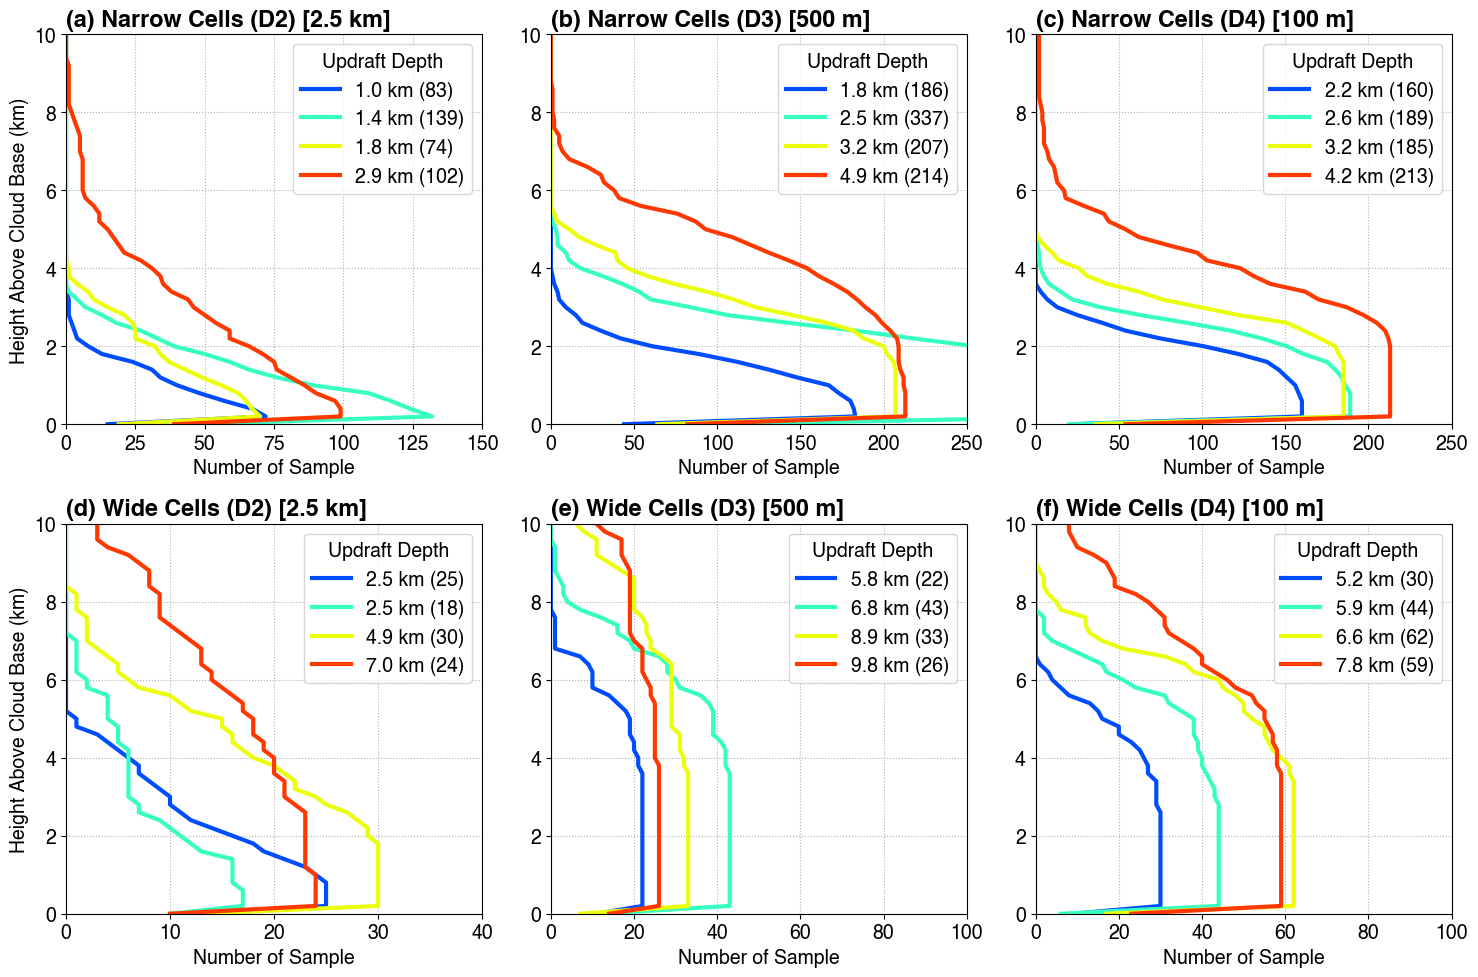

In [69]:
THRESH_w = 0
THRESH_n = 0
height_wbase = MaxCoreBuoyTrho_n_avg_d2.z / 1000.
# Number of samples profiles for core buoyancy Trho
med_n_d2 = nsMaxCoreDiam_n_d2
med_n_d3 = nsMaxCoreDiam_n_d3
med_n_d4 = nsMaxCoreDiam_n_d4

med_w_d2 = nsMaxCoreDiam_w_d2
med_w_d3 = nsMaxCoreDiam_w_d3
med_w_d4 = nsMaxCoreDiam_w_d4

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Number of Sample']*ncol,
    ['Number of Sample']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', '(b) Narrow Cells (D3) [500 m]', '(c) Narrow Cells (D4) [100 m]'],
    ['(d) Wide Cells (D2) [2.5 km]', '(e) Wide Cells (D3) [500 m]', '(f) Wide Cells (D4) [100 m]'],
]
ylims = (0,10)
xlims = [
    [(0,150), (0,250), (0,250)],
    [(0,40), (0, 100), (0, 100)],
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_NsampleCoreMaxDiameter_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=False,
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/Users/feng045/tmp/narrow_wide_CI30min/CIMax_CbaseProfile_NarrowWide_byETH_NCores_d2_d3_d4.png


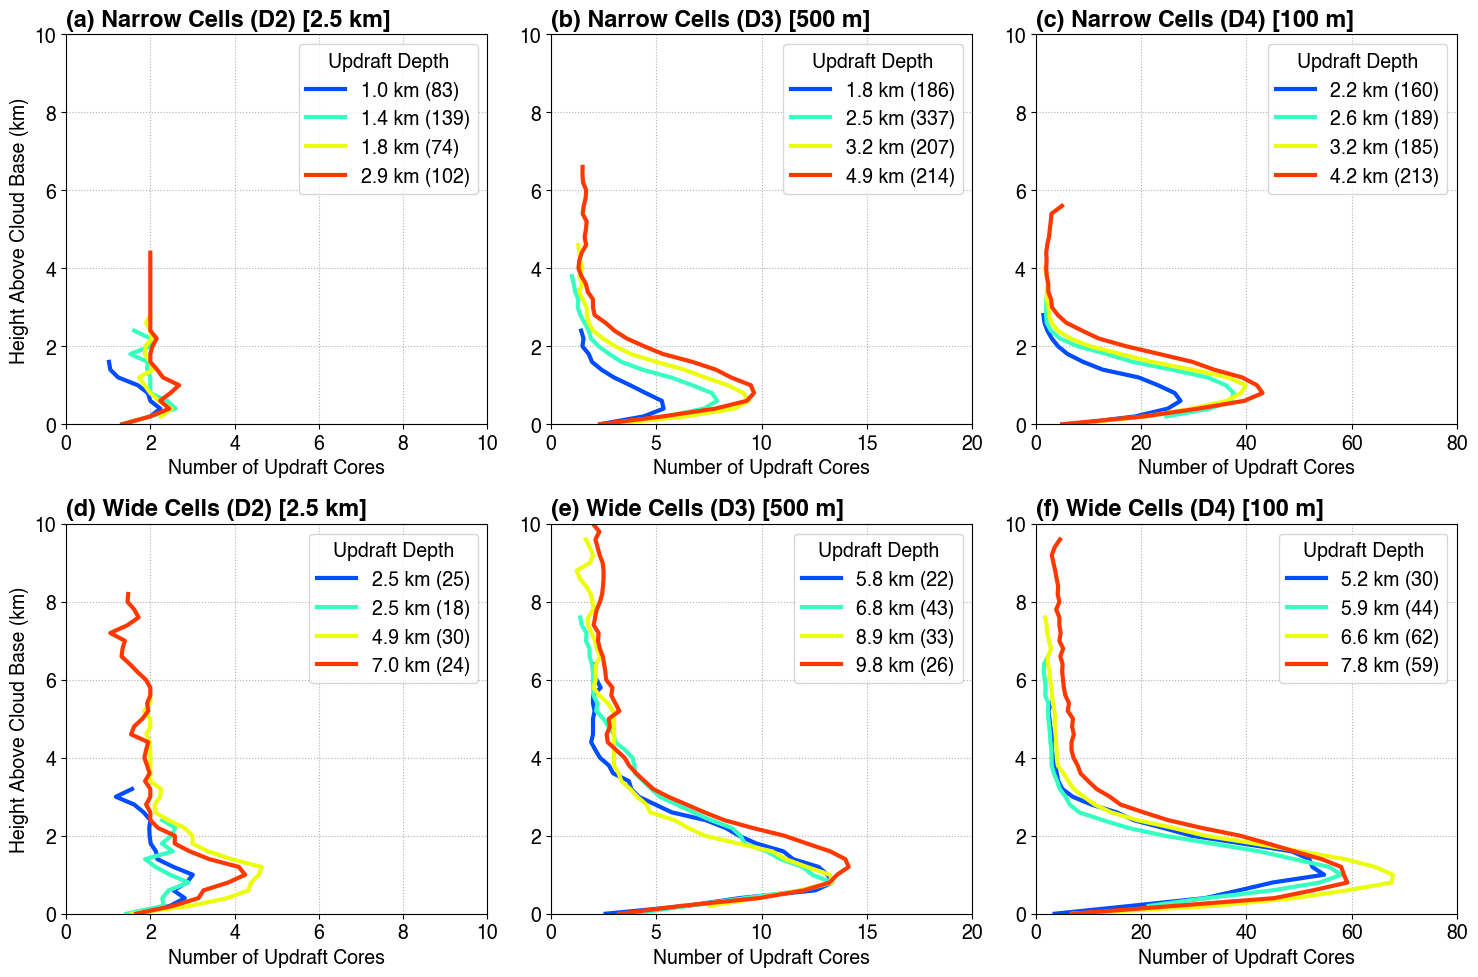

In [70]:
# THRESH_w = 10
THRESH_n = 20
THRESH_w = 8
height_wbase = NCore_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = NCore_w_inqt_d2.sel(quantile=0.5).where(nsNCore_w_d2 > THRESH_w)
med_w_d3 = NCore_w_inqt_d3.sel(quantile=0.5).where(nsNCore_w_d3 > THRESH_w)
med_w_d4 = NCore_w_inqt_d4.sel(quantile=0.5).where(nsNCore_w_d4 > THRESH_w)

med_n_d2 = NCore_n_inqt_d2.sel(quantile=0.5).where(nsNCore_n_d2 > THRESH_n)
med_n_d3 = NCore_n_inqt_d3.sel(quantile=0.5).where(nsNCore_n_d3 > THRESH_n)
med_n_d4 = NCore_n_inqt_d4.sel(quantile=0.5).where(nsNCore_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Number of Updraft Cores']*ncol,
    ['Number of Updraft Cores']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', '(b) Narrow Cells (D3) [500 m]', '(c) Narrow Cells (D4) [100 m]'],
    ['(d) Wide Cells (D2) [2.5 km]', '(e) Wide Cells (D3) [500 m]', '(f) Wide Cells (D4) [100 m]'],
]
ylims = (0,10)
xlims = [
    [(0,10),(0,20),(0,80)],
    [(0,10),(0,20),(0,80)],
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_NCores_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=False,
                     z_thresh=z_thresh, legend_show=legend_show, legend_ns=legend_ns, legend_loc=legend_loc, legend_text=legend_text, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/Users/feng045/tmp/narrow_wide_CI30min/CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxBuoyancy_d2_d3_d4.png


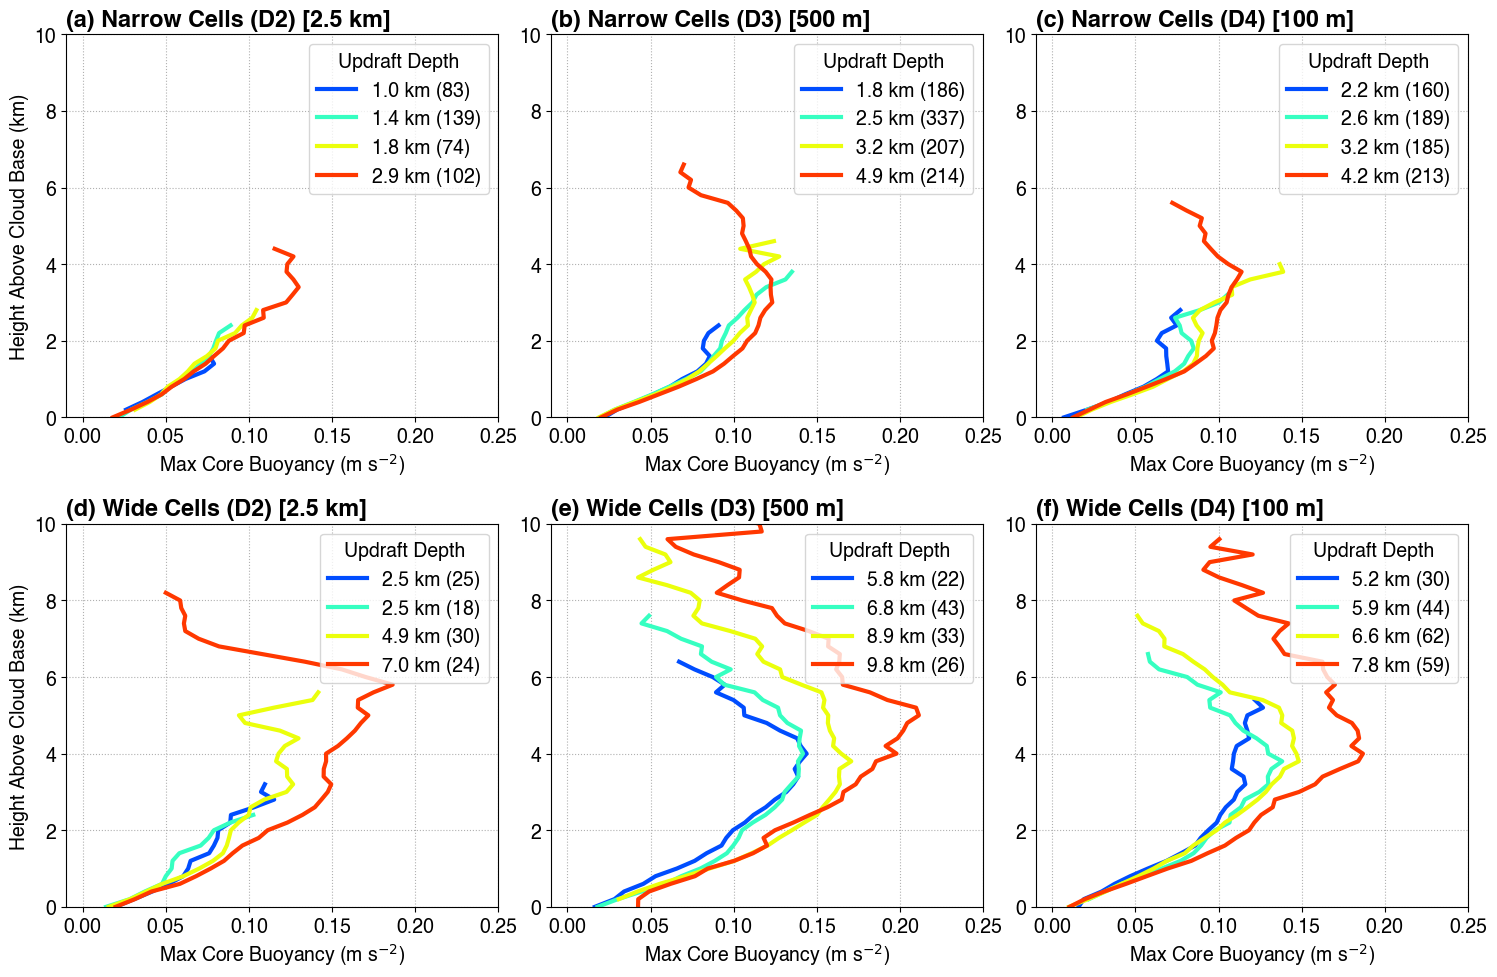

In [71]:
# THRESH_w = 10
# THRESH_n = 20

height_wbase = MaxCoreBuoy_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreBuoy_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreBuoy_w_d2 > THRESH_w)
med_w_d3 = MaxCoreBuoy_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreBuoy_w_d3 > THRESH_w)
med_w_d4 = MaxCoreBuoy_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreBuoy_w_d4 > THRESH_w)

med_n_d2 = MaxCoreBuoy_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreBuoy_n_d2 > THRESH_n)
med_n_d3 = MaxCoreBuoy_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreBuoy_n_d3 > THRESH_n)
med_n_d4 = MaxCoreBuoy_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreBuoy_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Max Core Buoyancy (m s$^{-2}$)']*ncol,
    ['Max Core Buoyancy (m s$^{-2}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', '(b) Narrow Cells (D3) [500 m]', '(c) Narrow Cells (D4) [100 m]'],
    ['(d) Wide Cells (D2) [2.5 km]', '(e) Wide Cells (D3) [500 m]', '(f) Wide Cells (D4) [100 m]'],
]
ylims = (0,10)
xlims = [
    [(-0.01,0.25)]*ncol,
    [(-0.01,0.25)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxBuoyancy_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=False,
                     z_thresh=z_thresh, legend_show=legend_show, legend_ns=legend_ns, legend_loc=legend_loc, legend_text=legend_text, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/Users/feng045/tmp/narrow_wide_CI30min/CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxBuoyancyTrho_d2_d3_d4.pdf


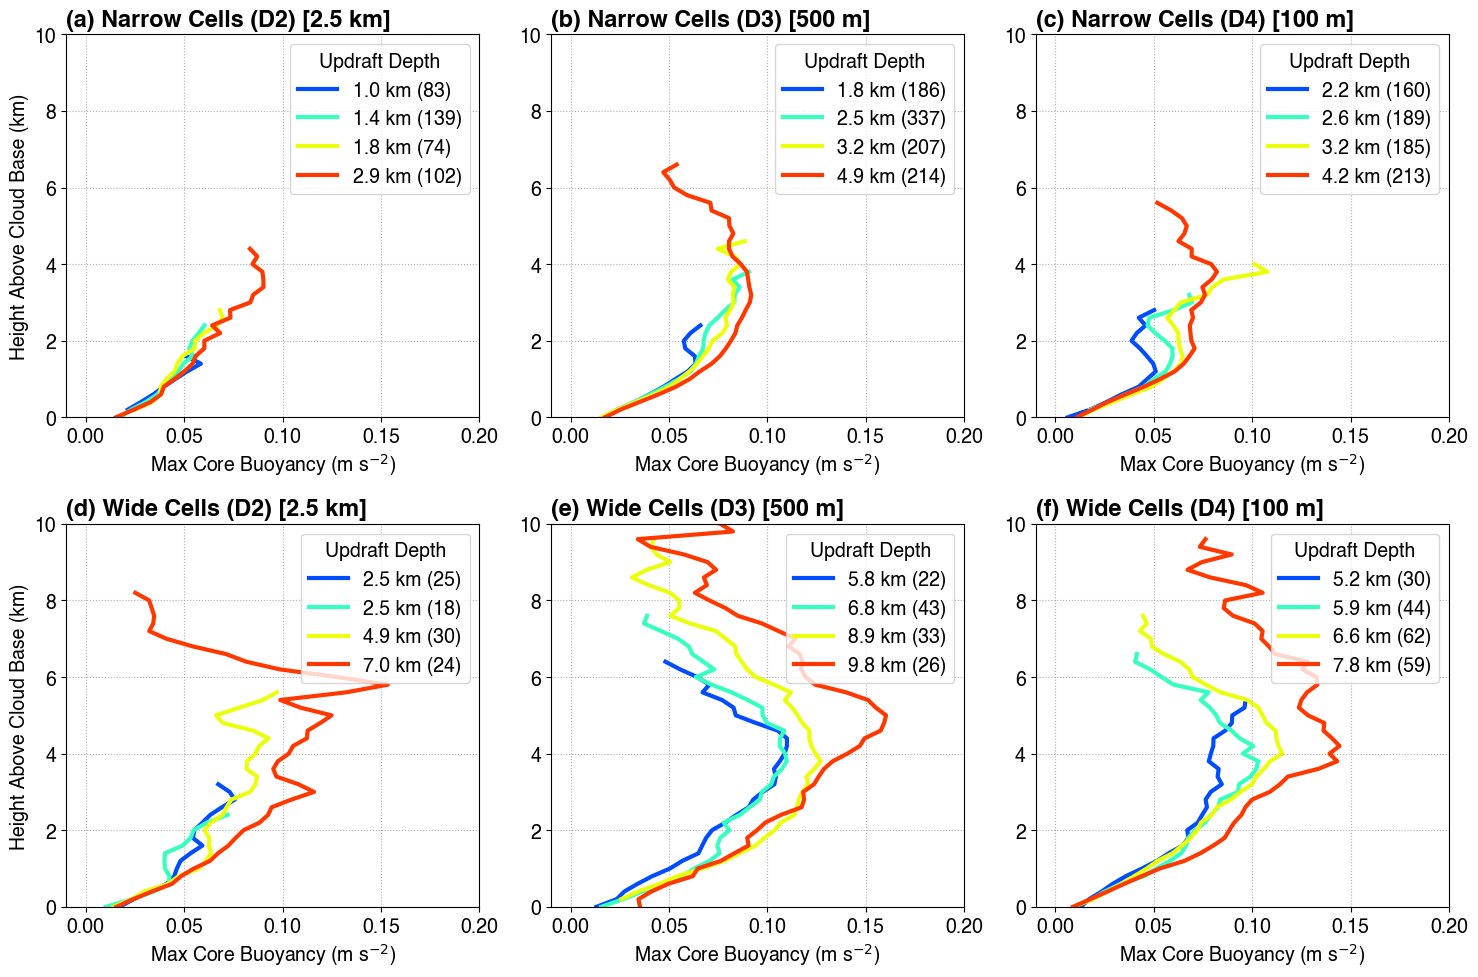

In [72]:
# THRESH_w = 10
# THRESH_n = 20
height_wbase = MaxCoreBuoyTrho_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreBuoyTrho_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_w_d2 > THRESH_w)
med_w_d3 = MaxCoreBuoyTrho_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_w_d3 > THRESH_w)
med_w_d4 = MaxCoreBuoyTrho_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_w_d4 > THRESH_w)

med_n_d2 = MaxCoreBuoyTrho_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_n_d2 > THRESH_n)
med_n_d3 = MaxCoreBuoyTrho_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_n_d3 > THRESH_n)
med_n_d4 = MaxCoreBuoyTrho_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreBuoyTrho_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Max Core Buoyancy (m s$^{-2}$)']*ncol,
    ['Max Core Buoyancy (m s$^{-2}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', '(b) Narrow Cells (D3) [500 m]', '(c) Narrow Cells (D4) [100 m]'],
    ['(d) Wide Cells (D2) [2.5 km]', '(e) Wide Cells (D3) [500 m]', '(f) Wide Cells (D4) [100 m]'],
]
ylims = (0,10)
xlims = [
    [(-0.01,0.2)]*ncol,
    [(-0.01,0.2)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'best'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxBuoyancyTrho_d2_d3_d4.pdf'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=False,
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/Users/feng045/tmp/narrow_wide_CI30min/CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxDiameter_d2_d3_d4.pdf


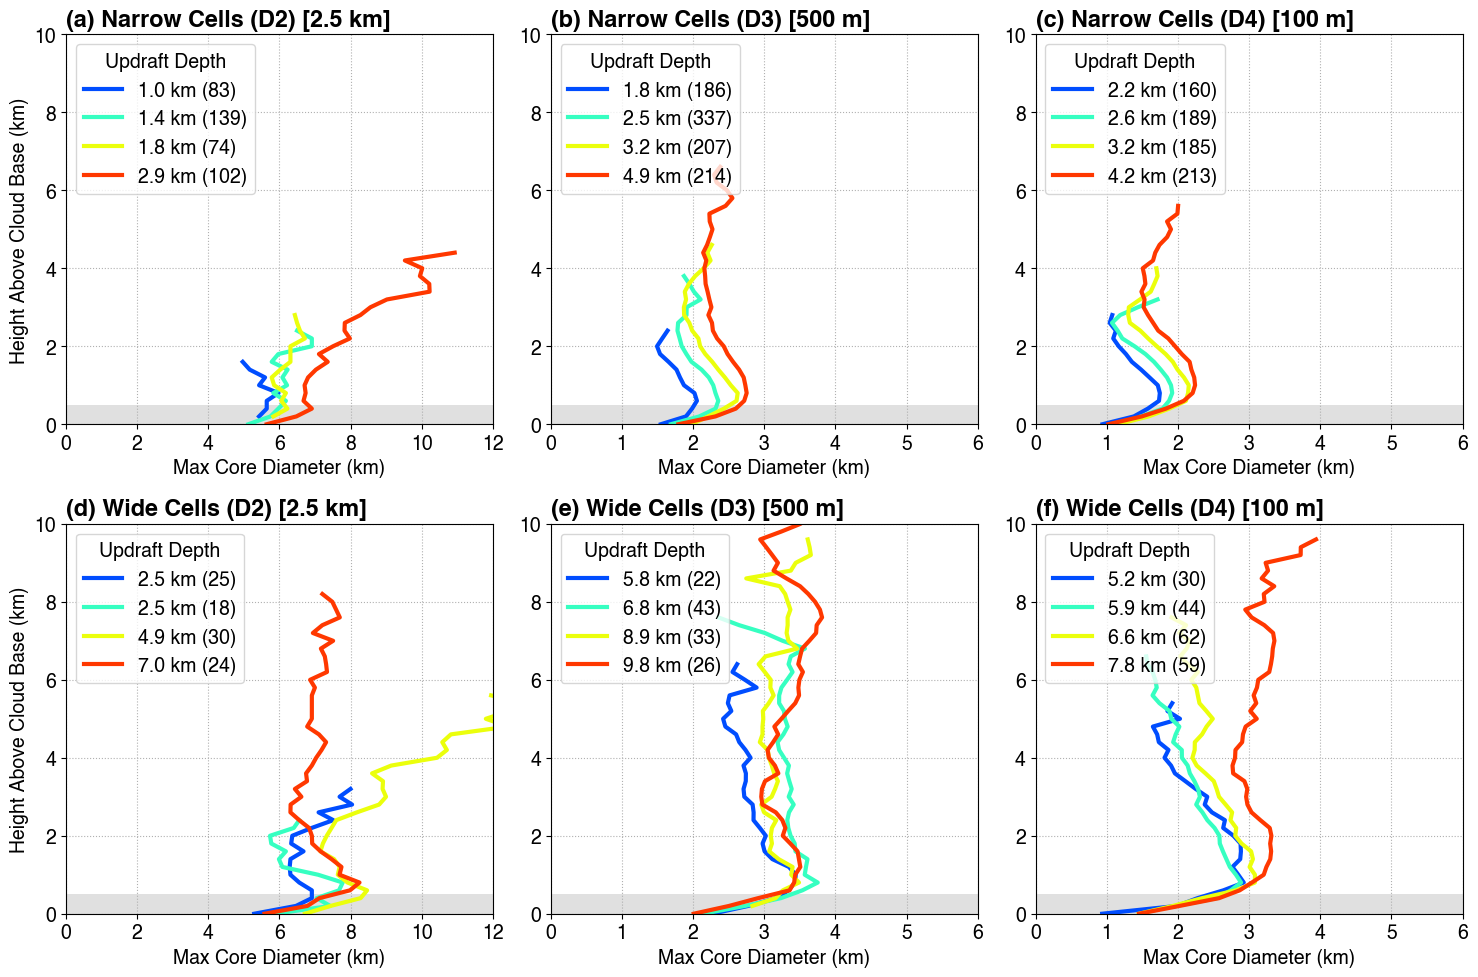

In [73]:
# THRESH_w = 10
# THRESH_n = 20
height_wbase = MaxCoreDiam_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreDiam_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreDiam_w_d2 > THRESH_w)
med_w_d3 = MaxCoreDiam_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreDiam_w_d3 > THRESH_w)
med_w_d4 = MaxCoreDiam_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreDiam_w_d4 > THRESH_w)

med_n_d2 = MaxCoreDiam_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreDiam_n_d2 > THRESH_n)
med_n_d3 = MaxCoreDiam_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreDiam_n_d3 > THRESH_n)
med_n_d4 = MaxCoreDiam_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreDiam_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Max Core Diameter (km)']*ncol,
    ['Max Core Diameter (km)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', '(b) Narrow Cells (D3) [500 m]', '(c) Narrow Cells (D4) [100 m]'],
    ['(d) Wide Cells (D2) [2.5 km]', '(e) Wide Cells (D3) [500 m]', '(f) Wide Cells (D4) [100 m]'],
]
ylims = (0,10)
xlims = [
    [(0,12),(0,6),(0,6)],
    [(0,12),(0,6),(0,6)],
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'upper left'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMaxDiameter_d2_d3_d4.pdf'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, shade_cbase=True,
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/Users/feng045/tmp/narrow_wide_CI30min/CIMax_CbaseProfile_NarrowWide_byETH_CoreMeanW_d2_d3_d4.png


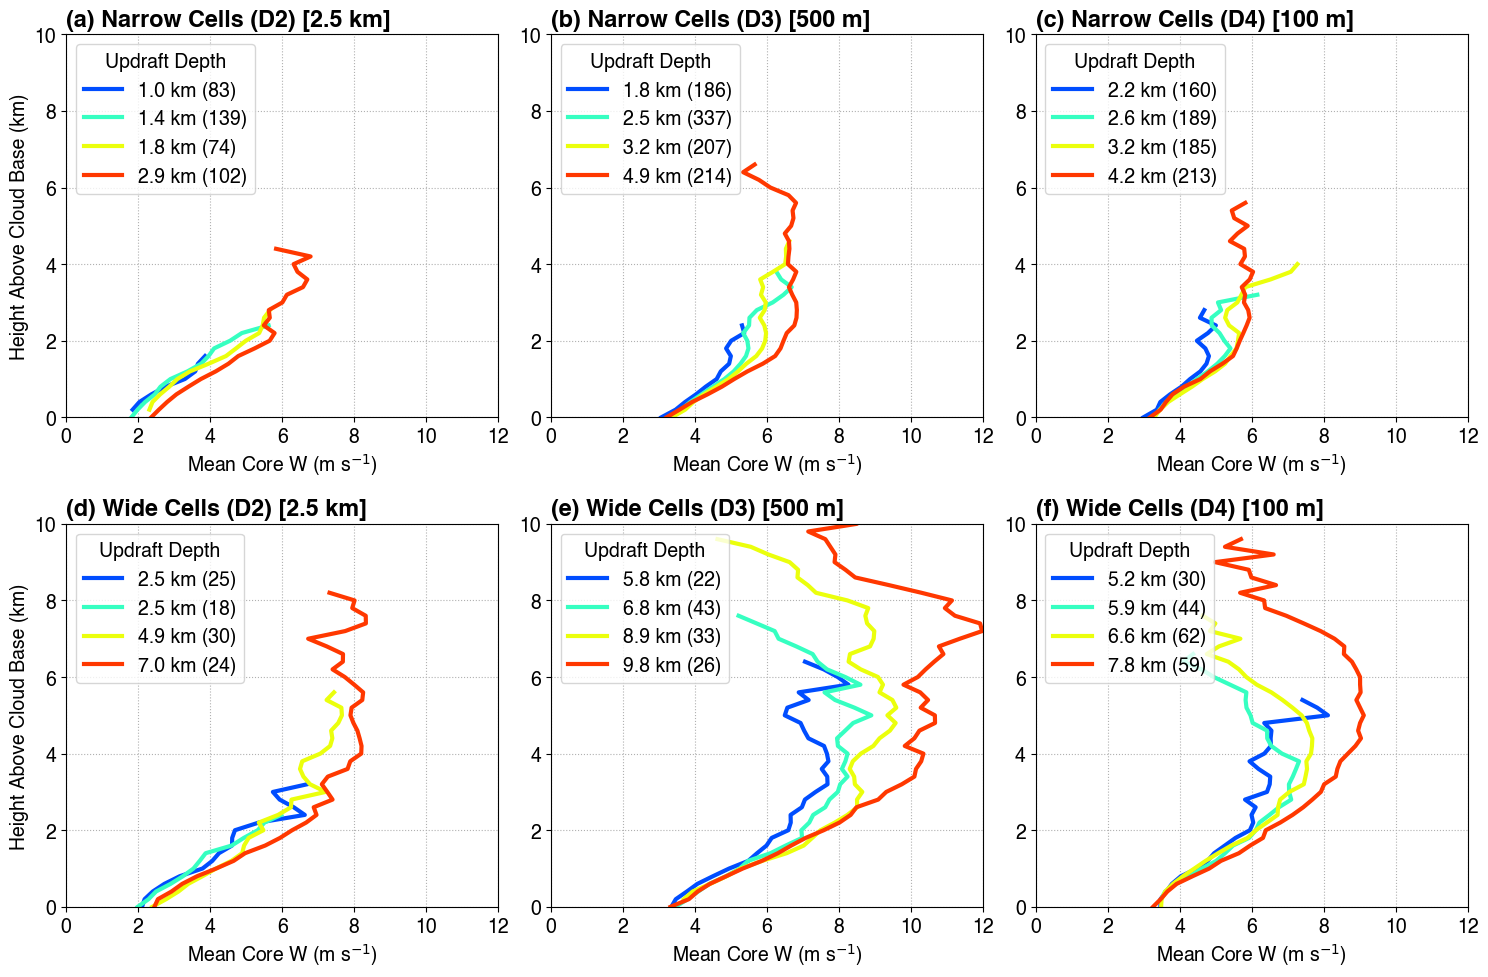

In [74]:
# THRESH_w = 10
# THRESH_n = 20
height_wbase = MaxCoreMeanW_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreMeanW_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMeanW_w_d2 > THRESH_w)
med_w_d3 = MaxCoreMeanW_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMeanW_w_d3 > THRESH_w)
med_w_d4 = MaxCoreMeanW_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMeanW_w_d4 > THRESH_w)

med_n_d2 = MaxCoreMeanW_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMeanW_n_d2 > THRESH_n)
med_n_d3 = MaxCoreMeanW_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMeanW_n_d3 > THRESH_n)
med_n_d4 = MaxCoreMeanW_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMeanW_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Mean Core W (m s$^{-1}$)']*ncol,
    ['Mean Core W (m s$^{-1}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', '(b) Narrow Cells (D3) [500 m]', '(c) Narrow Cells (D4) [100 m]'],
    ['(d) Wide Cells (D2) [2.5 km]', '(e) Wide Cells (D3) [500 m]', '(f) Wide Cells (D4) [100 m]'],
]
ylims = (0,10)
xlims = [
    [(0,12)]*ncol,
    [(0,12)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'upper left'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMeanW_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, 
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/Users/feng045/tmp/narrow_wide_CI30min/CIMax_CbaseProfile_NarrowWide_byETH_CoreMassFlux_d2_d3_d4.png


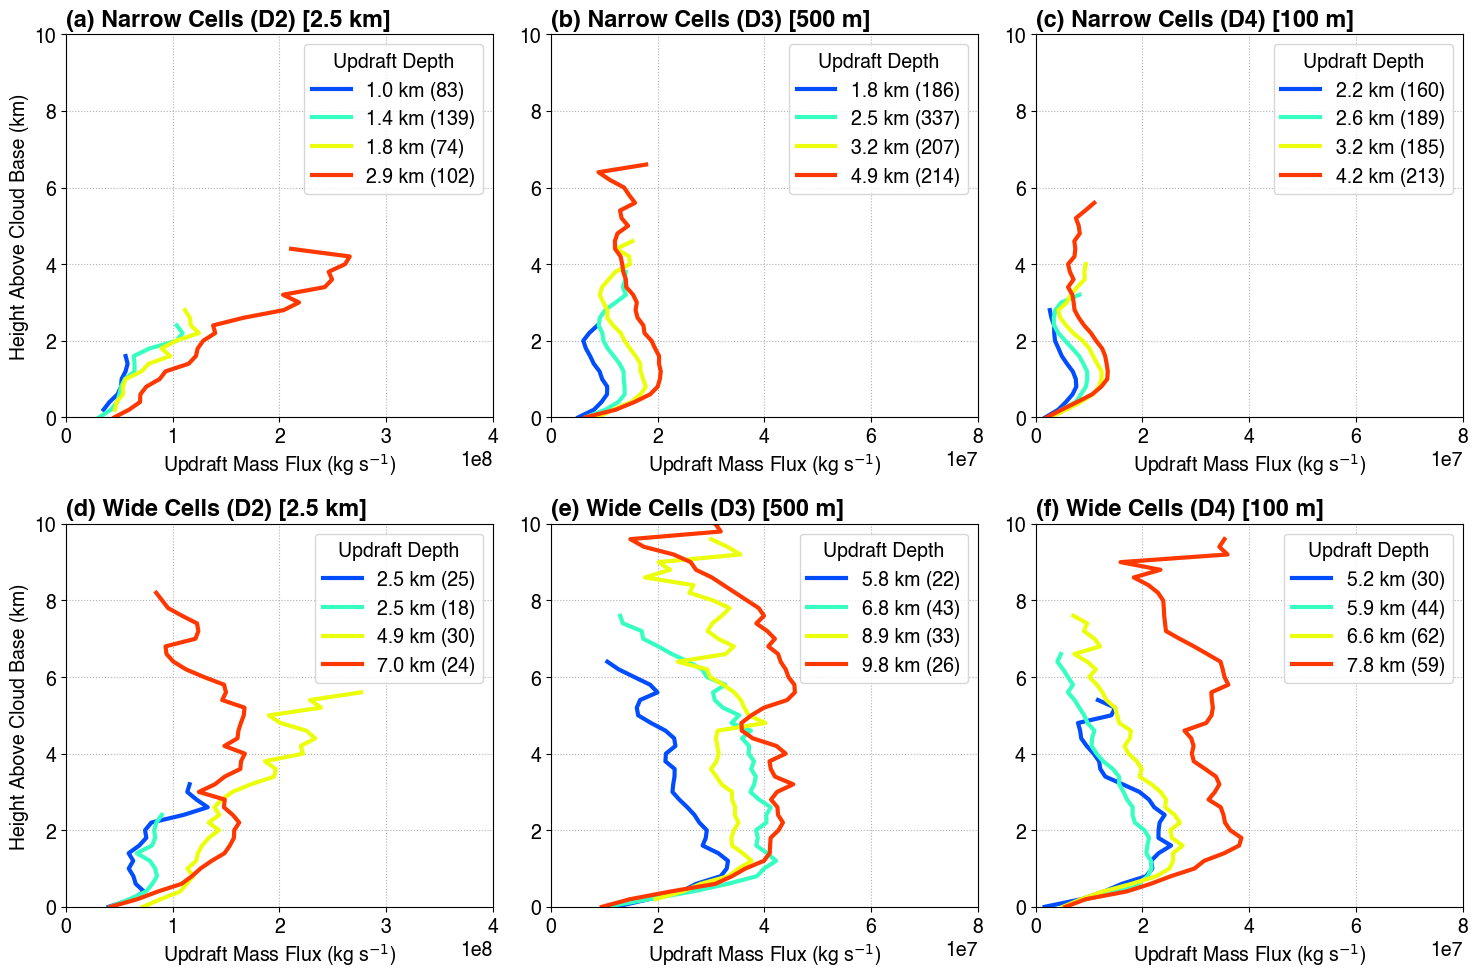

In [75]:
# THRESH_w = 10
# THRESH_n = 20
height_wbase = MaxCoreMassFlux_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MaxCoreMassFlux_w_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMassFlux_w_d2 > THRESH_w)
med_w_d3 = MaxCoreMassFlux_w_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMassFlux_w_d3 > THRESH_w)
med_w_d4 = MaxCoreMassFlux_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMassFlux_w_d4 > THRESH_w)

med_n_d2 = MaxCoreMassFlux_n_inqt_d2.sel(quantile=0.5).where(nsMaxCoreMassFlux_n_d2 > THRESH_n)
med_n_d3 = MaxCoreMassFlux_n_inqt_d3.sel(quantile=0.5).where(nsMaxCoreMassFlux_n_d3 > THRESH_n)
med_n_d4 = MaxCoreMassFlux_n_inqt_d4.sel(quantile=0.5).where(nsMaxCoreMassFlux_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]
legend_ns = [
    [nCells_n_d2, nCells_n_d3, nCells_n_d4],
    [nCells_w_d2, nCells_w_d3, nCells_w_d4],
]

z_thresh = None

xlabels = [
    ['Updraft Mass Flux (kg s$^{-1}$)']*ncol,
    ['Updraft Mass Flux (kg s$^{-1}$)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', '(b) Narrow Cells (D3) [500 m]', '(c) Narrow Cells (D4) [100 m]'],
    ['(d) Wide Cells (D2) [2.5 km]', '(e) Wide Cells (D3) [500 m]', '(f) Wide Cells (D4) [100 m]'],
]
ylims = (0,10)
xlims = [
    [(0,4e8),(0,0.8e8),(0,0.8e8)],
    [(0,4e8),(0,0.8e8),(0,0.8e8)],
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'upper right'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_CoreMassFlux_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, 
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_ns=legend_ns, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

/Users/feng045/tmp/narrow_wide_CI30min/CIMax_CbaseProfile_NarrowWide_byETH_ShellMedianRH_d2_d3_d4.png


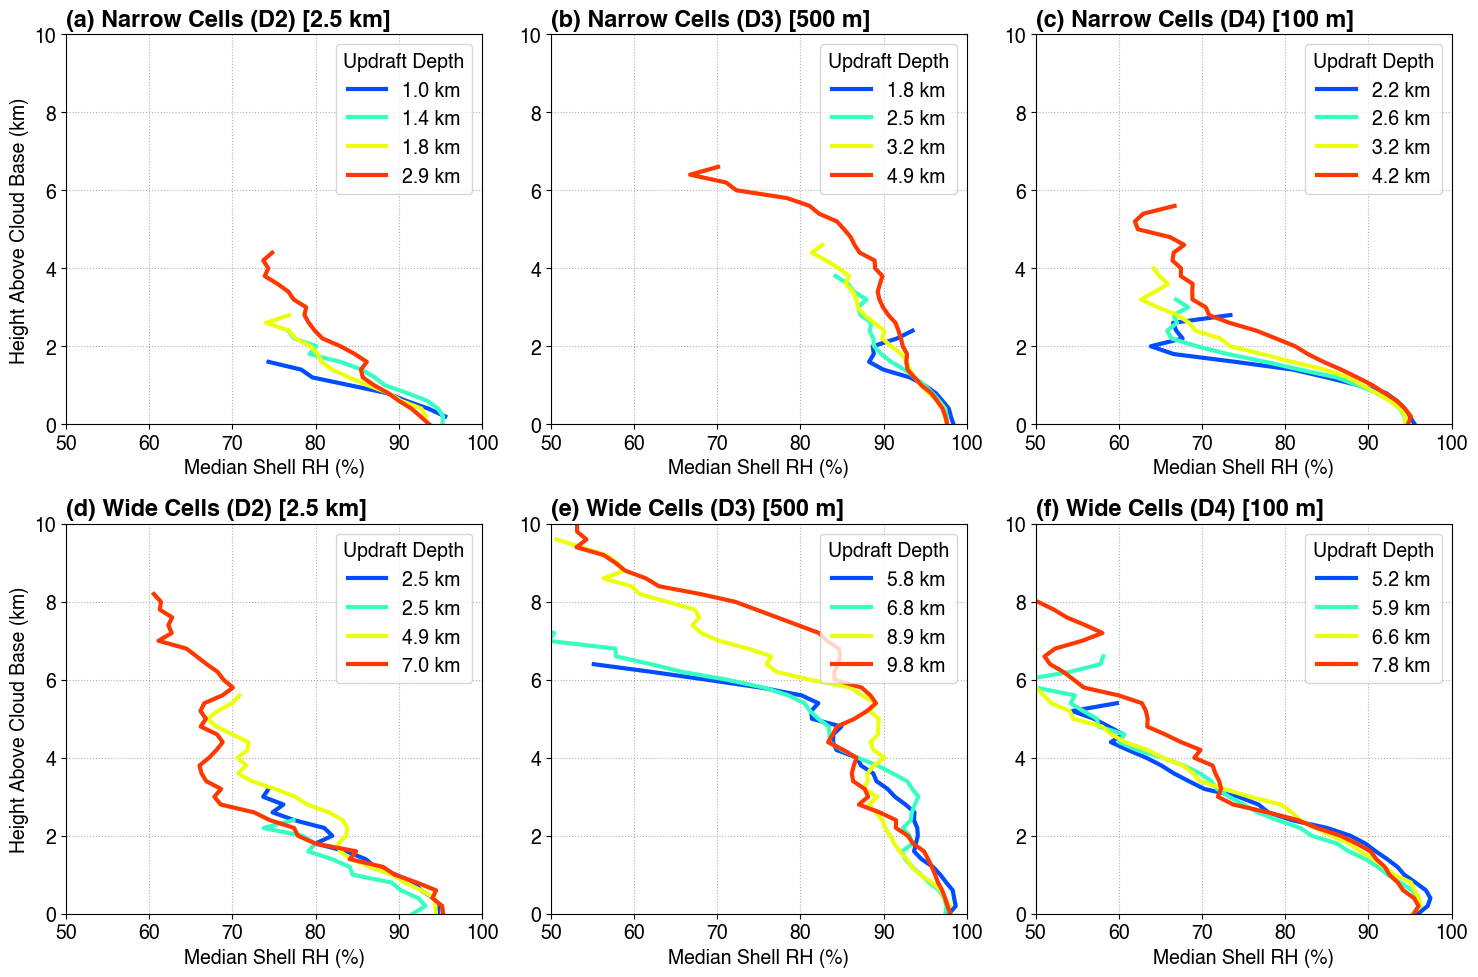

In [76]:
# THRESH_w = 10
# THRESH_n = 30
height_wbase = MedianShellRH_n_avg_d2.z / 1000.
# Median profiles
med_w_d2 = MedianShellRH_w_inqt_d2.sel(quantile=0.5).where(nsMedianShellRH_w_d2 > THRESH_w)
med_w_d3 = MedianShellRH_w_inqt_d3.sel(quantile=0.5).where(nsMedianShellRH_w_d3 > THRESH_w)
med_w_d4 = MedianShellRH_w_inqt_d4.sel(quantile=0.5).where(nsMedianShellRH_w_d4 > THRESH_w)

med_n_d2 = MedianShellRH_n_inqt_d2.sel(quantile=0.5).where(nsMedianShellRH_n_d2 > THRESH_n)
med_n_d3 = MedianShellRH_n_inqt_d3.sel(quantile=0.5).where(nsMedianShellRH_n_d3 > THRESH_n)
med_n_d4 = MedianShellRH_n_inqt_d4.sel(quantile=0.5).where(nsMedianShellRH_n_d4 > THRESH_n)

prof = [
    [med_n_d2, med_n_d3, med_n_d4],
    [med_w_d2, med_w_d3, med_w_d4],
]
nrow = len(prof)
ncol = len(prof[0])

Wdepth_qnt = 0.5  # Choose quantile to display updraft depth for each ETH bin
legend_text = [
    [Wdepth_n_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_n_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
    [Wdepth_w_inqt_d2.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d3.sel(quantile=Wdepth_qnt).data/1000, Wdepth_w_inqt_d4.sel(quantile=Wdepth_qnt).data/1000],
]

z_thresh = None

xlabels = [
    ['Median Shell RH (%)']*ncol,
    ['Median Shell RH (%)']*ncol,
]
ylabels = [
    ['Height Above Cloud Base (km)', '', ''],
    ['Height Above Cloud Base (km)', '', ''],
]
titles = [
    ['(a) Narrow Cells (D2) [2.5 km]', '(b) Narrow Cells (D3) [500 m]', '(c) Narrow Cells (D4) [100 m]'],
    ['(d) Wide Cells (D2) [2.5 km]', '(e) Wide Cells (D3) [500 m]', '(f) Wide Cells (D4) [100 m]'],
]
ylims = (0,10)
xlims = [
    [(50,100)]*ncol,
    [(50,100)]*ncol,
]
legend_show = [[True]*ncol,[True]*ncol]
legend_loc = 'upper right'
legend_title = 'Updraft Depth'
cmap='jet'
cmap_range=(0.2,0.85)
fontsize = 14
figsize = [15, 10]
figname = f'{figdir}CIMax_CbaseProfile_NarrowWide_byETH_ShellMedianRH_d2_d3_d4.png'
print(figname)
fig = plot_mxn_prof(nrow, ncol, prof, height_wbase, 
                     z_thresh=z_thresh, legend_show=legend_show, legend_loc=legend_loc, legend_text=legend_text, legend_title=legend_title, cmap=cmap, cmap_range=cmap_range,
                     xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

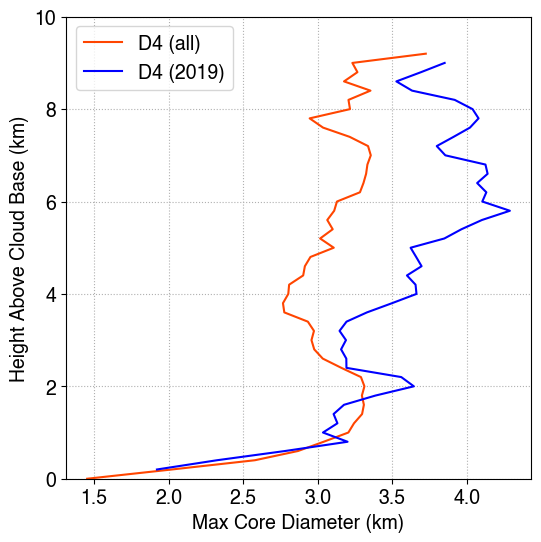

In [77]:
fig, ax = plt.subplots(figsize=(6,6))
THRESH_w = 10
med_w_d4 = MaxCoreDiam_w_inqt_d4.sel(quantile=0.5).where(nsMaxCoreDiam_w_d4 > THRESH_w).isel(ETH=3)
med_w_d4_2019 = MaxCoreDiam_w_inqt_d4_2019.sel(quantile=0.5).where(nsMaxCoreDiam_w_d4_2019> THRESH_w).isel(ETH=3)
ax.plot(med_w_d4, height_wbase, color='orangered', label='D4 (all)')
ax.plot(med_w_d4_2019, height_wbase, color='blue', label='D4 (2019)')
ax.legend()
ax.set_xlabel('Max Core Diameter (km)')
ax.set_ylabel('Height Above Cloud Base (km)')
ax.set_ylim(0, 10)
ax.grid(ls=':')

### Examine why the deepest wide cells are different among the 3 LASSO resolutions

In [78]:
print(ETH_bins_w_d2)
ETH_bins_w_d2[-2], ETH_bins_w_d2[-1]

[ 3.49999049  6.25000152  7.99999478  9.99999074 14.99999247]


(np.float64(9.999990737708057), np.float64(14.999992467892229))

In [79]:
print(ETH_bins_w_d3)
ETH_bins_w_d3[-2], ETH_bins_w_d3[-1]

[ 7.0000055   9.99999297 10.00000819 12.0000035  16.00000459]


(np.float64(12.000003496551898), np.float64(16.00000459212345))

In [80]:
print(ETH_bins_w_d4)
ETH_bins_w_d4[-2], ETH_bins_w_d4[-1]

[ 5.99999041  7.99999763  8.99999623  9.99999592 15.00000615]


(np.float64(9.999995919168416), np.float64(15.000006148802948))

In [81]:
def count_ntracks_wide_deep(ds, ETH_bins):
    """
    Count wide deep cells by dates

    Args:
        ds: Xarray DataSet
            DataSet
        ETH_bins: np.array_like
            Cell echo-top height bins
    """
    # Get mask for wide & deepest cells (ETH > last ETH bin)
    mask = (ds.CImaxETH_10dbz >= ETH_bins[-2]) & (ds.CImaxETH_10dbz < ETH_bins[-1])
    # Apply mask to tracks coordinate (keep original dimensions)
    tracks_mask = ds.tracks.where(mask, drop=False)
    # Group by unique dates for wide cells, count number of tracks
    return tracks_mask.groupby(ds.date).count()

In [82]:
ntracks_w_d_d2 = count_ntracks_wide_deep(ds_wide_d2, ETH_bins_w_d2)
ntracks_w_d_d2
ntracks_w_d_d3 = count_ntracks_wide_deep(ds_wide_d3, ETH_bins_w_d3)
ntracks_w_d_d3
ntracks_w_d_d4 = count_ntracks_wide_deep(ds_wide_d4, ETH_bins_w_d4)
ntracks_w_d_d4

<xarray.DataArray 'tracks' (date: 8)> Size: 64B
array([12,  5,  1,  3,  6, 14,  8, 10])
Coordinates:
  * date     (date) datetime64[ns] 64B 2018-11-29 2018-12-04 ... 2019-02-08
    core     int64 8B 0

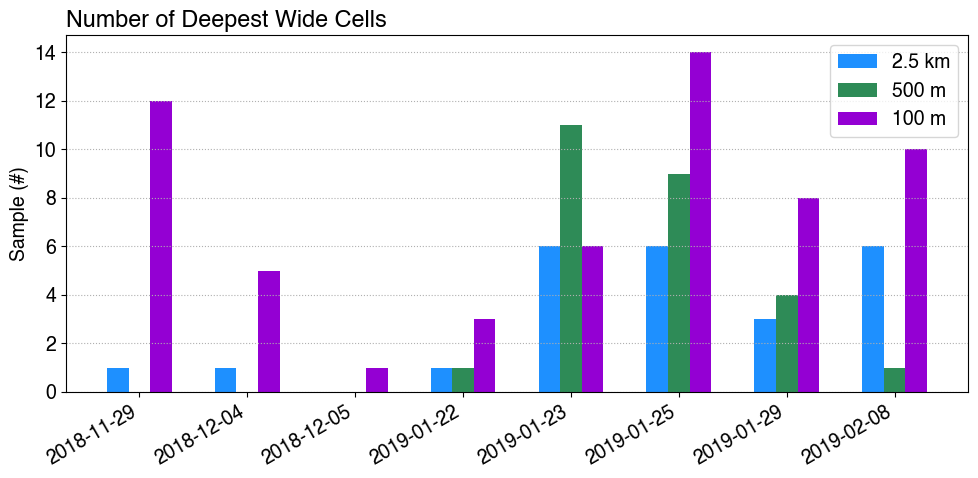

In [83]:
x = np.arange(len(unique_dates))
bar_data = {'d2':ntracks_w_d_d2, 'd3':ntracks_w_d_d3, 'd4':ntracks_w_d_d4}
ylabel = 'Sample (#)'
title = 'Number of Deepest Wide Cells'
fontsize = 14
figsize = [10,5]
figname = f'{figdir}CellNumberByDate_wide_deepest_d2_d3_d4.png'
fig = plot_bars(bar_data, xlabel=unique_dates_str, ylabel=ylabel, title=title, fontsize=fontsize, figsize=figsize, figname=figname)

In [84]:
ds_wide_d4

<xarray.Dataset> Size: 151MB
Dimensions:                  (tracks: 195, times: 200, z: 40, height: 101)
Coordinates:
  * tracks                   (tracks) int64 2kB 8 9 16 20 ... 1703 1705 1708
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
  * z                        (z) float64 320B 250.0 500.0 ... 2e+04 2.1e+04
  * height                   (height) float64 808B 0.0 200.0 ... 1.98e+04 2e+04
    core                     int64 8B 0
Data variables: (12/210)
    track_duration           (tracks) float64 2kB 15.0 14.0 14.0 ... 6.0 6.0
    base_time                (tracks, times) datetime64[ns] 312kB 2018-11-29T...
    meanlat                  (tracks, times) float32 156kB -31.76 -31.78 ... nan
    meanlon                  (tracks, times) float32 156kB -64.84 -64.87 ... nan
    area                     (tracks, times) float32 156kB 13.75 13.0 ... nan
    cloudnumber              (tracks, times) float64 312kB 7.0 10.0 ... nan nan
    ...                       ...
    CImaxWTop                (tracks) float64 2kB 9.0 9.0 8.0 ... 8.0 9.0 9.0
    CImaxWDiamTime           (tracks) float64 2kB 60.0 45.0 30.0 ... 25.0 20.0
    CImaxWTopTime            (tracks) float64 2kB 45.0 50.0 35.0 ... 10.0 15.0
    CImaxWDiam_CI            (tracks) float64 2kB 1.608 1.016 ... 1.003 1.584
    CImaxWDiamTime_CI        (tracks) float64 2kB 15.0 30.0 30.0 ... 25.0 20.0
    CImaxETH10dbzTime        (tracks) float64 2kB 45.0 50.0 35.0 ... 10.0 15.0
Attributes: (12/15)
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5
    source_trackfile:      /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les...
    ...                    ...
    time_start:            0
    time_end:              60
    time_environment:      -1
    ETH_buffer:            1.0
    cbase_depth:           0.5
    coldpool_time_offset:  2.0

In [85]:
def subset_var_by_ETH(ds, ETH_bins, varname, times_idx):
    # Get mask for wide & deepest cells (ETH > last ETH bin)
    mask = (ds.CImaxETH_10dbz >= ETH_bins[-2]) & (ds.CImaxETH_10dbz < ETH_bins[-1])
    # Apply mask to tracks coordinate
    tracks = ds.tracks.where(mask, drop=True)
    # Subset variable
    # return ds[varname].sel(tracks=tracks, times=times_idx)
    return ds[varname].sel(tracks=tracks)

In [86]:
ds_wide_d4.lwp_frac.attrs

{'long_name': 'LWP area fraction',
 'units': 'unitless',
 'LWP_threshold': np.float64(0.1)}

In [87]:
# times_idx = -1
times_idx = None
rainrate_p95_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'rainrate_p95', times_idx)
rainrate_p95_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'rainrate_p95', times_idx)
rainrate_p95_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'rainrate_p95', times_idx)

rainrate_avg_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'rainrate_avg', times_idx)
rainrate_avg_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'rainrate_avg', times_idx)
rainrate_avg_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'rainrate_avg', times_idx)

cellfrac_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'cell_frac', times_idx)
cellfrac_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'cell_frac', times_idx)
cellfrac_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'cell_frac', times_idx)

lwpfrac_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'lwp_frac', times_idx)
lwpfrac_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'lwp_frac', times_idx)
lwpfrac_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'lwp_frac', times_idx)

lwp_avg_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'lwp_avg', times_idx)
lwp_avg_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'lwp_avg', times_idx)
lwp_avg_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'lwp_avg', times_idx)

lwp_p95_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'lwp_p95', times_idx)
lwp_p95_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'lwp_p95', times_idx)
lwp_p95_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'lwp_p95', times_idx)

In [88]:
# Surface pCAPE
pCAPE_sfc_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'pCAPE_sfc', times_idx)
pCAPE_sfc_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'pCAPE_sfc', times_idx)
pCAPE_sfc_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'pCAPE_sfc', times_idx)

pLFC_height_sfc_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'pLFC_height_sfc', times_idx)
pLFC_height_sfc_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'pLFC_height_sfc', times_idx)
pLFC_height_sfc_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'pLFC_height_sfc', times_idx)

# MU
pCAPEmu_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'pCAPE_mu', times_idx)
pCAPEmu_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'pCAPE_mu', times_idx)
pCAPEmu_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'pCAPE_mu', times_idx)

pCAPEacbl_mu_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'pCAPEacbl_mu', times_idx)
pCAPEacbl_mu_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'pCAPEacbl_mu', times_idx)
pCAPEacbl_mu_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'pCAPEacbl_mu', times_idx)

LCLz_mu_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'LCL_height_mu', times_idx)
LCLz_mu_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'LCL_height_mu', times_idx)
LCLz_mu_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'LCL_height_mu', times_idx)

LCLz_sfc_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'LCL_height_sfc', times_idx)
LCLz_sfc_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'LCL_height_sfc', times_idx)
LCLz_sfc_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'LCL_height_sfc', times_idx)

pELmu_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'pEL_height_mu', times_idx)
pELmu_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'pEL_height_mu', times_idx)
pELmu_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'pEL_height_mu', times_idx)

In [89]:
rvap_925mb_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'rvap_925mb', times_idx)
rvap_925mb_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'rvap_925mb', times_idx)
rvap_925mb_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'rvap_925mb', times_idx)

rvap_850mb_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'rvap_850mb', times_idx)
rvap_850mb_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'rvap_850mb', times_idx)
rvap_850mb_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'rvap_850mb', times_idx)

rh_600mb_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'rh_600mb', times_idx)
rh_600mb_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'rh_600mb', times_idx)
rh_600mb_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'rh_600mb', times_idx)

rh_at_muLFCplus1500m_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'rh_at_muLFCplus1500m', times_idx)
rh_at_muLFCplus1500m_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'rh_at_muLFCplus1500m', times_idx)
rh_at_muLFCplus1500m_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'rh_at_muLFCplus1500m', times_idx)

In [90]:
shear_mag_bulk_0to3km_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'shear_mag_bulk_0to3km', times_idx)
shear_mag_bulk_0to3km_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'shear_mag_bulk_0to3km', times_idx)
shear_mag_bulk_0to3km_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'shear_mag_bulk_0to3km', times_idx)

shear_mag_bulk_0to6km_d4 = subset_var_by_ETH(ds_wide_d4, ETH_bins_w_d4, 'shear_mag_bulk_0to6km', times_idx)
shear_mag_bulk_0to6km_d3 = subset_var_by_ETH(ds_wide_d3, ETH_bins_w_d3, 'shear_mag_bulk_0to6km', times_idx)
shear_mag_bulk_0to6km_d2 = subset_var_by_ETH(ds_wide_d2, ETH_bins_w_d2, 'shear_mag_bulk_0to6km', times_idx)

In [91]:
def get_kde1d(data, bins, kde_bw, kde_kernel='gaussian'):
    """
    Compute 1D KDE using Ski-learn
    
    Args:
        data: np.array
            Array containing data.
        bins: np.array
            Desired bins for plotting.
        kde_bw: float
            The bandwidth of the kernel.
        kde_kernel: string
            The kernel to use.
            
    Return:
        kde_out: np.array
            KDE at the desired bins.
    """
    # Flatten array to 1D
    data1d = data.flatten()
    # Remove NaN (sklearn KDE does not handle NaN), and make a new axis
    _data = data1d[np.isfinite(data1d)][:, np.newaxis]
    # _data = data1d[~np.isnan(data1d)][:, np.newaxis]
    _bins = bins[:, np.newaxis]
    
    # Estimate 1D KDE following sklearn example
    # https://scikit-learn.org/stable/auto_examples/neighbors/plot_kde_1d.html
    kde = KernelDensity(kernel=kde_kernel, bandwidth=kde_bw).fit(_data)
    # Get KDE values based on input bins
    log_dens = kde.score_samples(_bins)
    # Get linear density
    kde_out = np.exp(log_dens)
    return kde_out

In [92]:
lwpfrac_bins = np.linspace(0.0, 1.01, 1000)
kde_lwpfrac_d4 = get_kde1d(lwpfrac_d4.data, lwpfrac_bins, kde_bw=0.1)
kde_lwpfrac_d3 = get_kde1d(lwpfrac_d3.data, lwpfrac_bins, kde_bw=0.1)
kde_lwpfrac_d2 = get_kde1d(lwpfrac_d2.data, lwpfrac_bins, kde_bw=0.1)

lwp_bins = np.linspace(0.0, 1.01, 1000)
kde_lwp_avg_d4 = get_kde1d(lwp_avg_d4.data, lwp_bins, kde_bw=0.1)
kde_lwp_avg_d3 = get_kde1d(lwp_avg_d3.data, lwp_bins, kde_bw=0.1)
kde_lwp_avg_d2 = get_kde1d(lwp_avg_d2.data, lwp_bins, kde_bw=0.1)

lwp_p95_bins = np.linspace(0.0, 3.01, 1000)
kde_lwp_p95_d4 = get_kde1d(lwp_p95_d4.data, lwp_p95_bins, kde_bw=0.3)
kde_lwp_p95_d3 = get_kde1d(lwp_p95_d3.data, lwp_p95_bins, kde_bw=0.3)
kde_lwp_p95_d2 = get_kde1d(lwp_p95_d2.data, lwp_p95_bins, kde_bw=0.3)

rr_bins = np.linspace(1e-1, 10, 1000)
kde_rainrate_p95_d4 = get_kde1d(np.log10(rainrate_p95_d4.data), rr_bins, kde_bw=0.6)
kde_rainrate_p95_d3 = get_kde1d(np.log10(rainrate_p95_d3.data), rr_bins, kde_bw=0.6)
kde_rainrate_p95_d2 = get_kde1d(np.log10(rainrate_p95_d2.data), rr_bins, kde_bw=0.6)

kde_rainrate_avg_d4 = get_kde1d(np.log10(rainrate_avg_d4.data), rr_bins, kde_bw=0.6)
kde_rainrate_avg_d3 = get_kde1d(np.log10(rainrate_avg_d3.data), rr_bins, kde_bw=0.6)
kde_rainrate_avg_d2 = get_kde1d(np.log10(rainrate_avg_d2.data), rr_bins, kde_bw=0.6)

cellfrac_bins = np.linspace(0, 0.31, 1000)
kde_cellfrac_d4 = get_kde1d(cellfrac_d4.data, cellfrac_bins, kde_bw=0.02)
kde_cellfrac_d3 = get_kde1d(cellfrac_d3.data, cellfrac_bins, kde_bw=0.02)
kde_cellfrac_d2 = get_kde1d(cellfrac_d2.data, cellfrac_bins, kde_bw=0.02)

/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_33778/2435412850.py:17: RuntimeWarning: divide by zero encountered in log10
  kde_rainrate_p95_d4 = get_kde1d(np.log10(rainrate_p95_d4.data), rr_bins, kde_bw=0.6)
/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_33778/2435412850.py:18: RuntimeWarning: divide by zero encountered in log10
  kde_rainrate_p95_d3 = get_kde1d(np.log10(rainrate_p95_d3.data), rr_bins, kde_bw=0.6)
/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_33778/2435412850.py:19: RuntimeWarning: divide by zero encountered in log10
  kde_rainrate_p95_d2 = get_kde1d(np.log10(rainrate_p95_d2.data), rr_bins, kde_bw=0.6)
/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_33778/2435412850.py:21: RuntimeWarning: divide by zero encountered in log10
  kde_rainrate_avg_d4 = get_kde1d(np.log10(rainrate_avg_d4.data), rr_bins, kde_bw=0.6)
/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_33778/2435412850.py:22: RuntimeWarning: divide by zer

In [93]:
pCAPE_sfc_bins = np.linspace(0, 7000, 1000)
kde_pCAPE_sfc_d4 = get_kde1d(pCAPE_sfc_d4.data, pCAPE_sfc_bins, kde_bw=500)
kde_pCAPE_sfc_d3 = get_kde1d(pCAPE_sfc_d3.data, pCAPE_sfc_bins, kde_bw=500)
kde_pCAPE_sfc_d2 = get_kde1d(pCAPE_sfc_d2.data, pCAPE_sfc_bins, kde_bw=500)

pLFC_height_sfc_bins = np.linspace(0, 4000, 1000)
kde_pLFC_height_sfc_d4 = get_kde1d(pLFC_height_sfc_d4.data, pLFC_height_sfc_bins, kde_bw=500)
kde_pLFC_height_sfc_d3 = get_kde1d(pLFC_height_sfc_d3.data, pLFC_height_sfc_bins, kde_bw=500)
kde_pLFC_height_sfc_d2 = get_kde1d(pLFC_height_sfc_d2.data, pLFC_height_sfc_bins, kde_bw=500)

In [94]:
CAPEmu_bins = np.linspace(0, 7000, 1000)
kde_pCAPEmu_d4 = get_kde1d(pCAPEmu_d4.data, CAPEmu_bins, kde_bw=500)
kde_pCAPEmu_d3 = get_kde1d(pCAPEmu_d3.data, CAPEmu_bins, kde_bw=500)
kde_pCAPEmu_d2 = get_kde1d(pCAPEmu_d2.data, CAPEmu_bins, kde_bw=500)

pCAPEacbl_mu_bins = np.linspace(0, 200, 1000)
kde_pCAPEacbl_mu_d4 = get_kde1d(pCAPEacbl_mu_d4.data, pCAPEacbl_mu_bins, kde_bw=20)
kde_pCAPEacbl_mu_d3 = get_kde1d(pCAPEacbl_mu_d3.data, pCAPEacbl_mu_bins, kde_bw=20)
kde_pCAPEacbl_mu_d2 = get_kde1d(pCAPEacbl_mu_d2.data, pCAPEacbl_mu_bins, kde_bw=20)

LCLz_bins = np.linspace(0, 2600, 1000)
kde_LCLz_mu_d4 = get_kde1d(LCLz_mu_d4.data, LCLz_bins, kde_bw=200)
kde_LCLz_mu_d3 = get_kde1d(LCLz_mu_d3.data, LCLz_bins, kde_bw=200)
kde_LCLz_mu_d2 = get_kde1d(LCLz_mu_d2.data, LCLz_bins, kde_bw=200)

kde_LCLz_sfc_d4 = get_kde1d(LCLz_sfc_d4.data, LCLz_bins, kde_bw=200)
kde_LCLz_sfc_d3 = get_kde1d(LCLz_sfc_d3.data, LCLz_bins, kde_bw=200)
kde_LCLz_sfc_d2 = get_kde1d(LCLz_sfc_d2.data, LCLz_bins, kde_bw=200)

ELmu_bins = np.linspace(6, 20.0, 1000)
kde_pELmu_d4 = get_kde1d(pELmu_d4.data/1000, ELmu_bins, kde_bw=0.5)
kde_pELmu_d3 = get_kde1d(pELmu_d3.data/1000, ELmu_bins, kde_bw=0.5)
kde_pELmu_d2 = get_kde1d(pELmu_d2.data/1000, ELmu_bins, kde_bw=0.5)

In [95]:
rvap_925mb_bins = np.linspace(5.0, 23.0, 1000)
kde_rvap_925mb_d4 = get_kde1d(rvap_925mb_d4.data, rvap_925mb_bins, kde_bw=1)
kde_rvap_925mb_d3 = get_kde1d(rvap_925mb_d3.data, rvap_925mb_bins, kde_bw=1)
kde_rvap_925mb_d2 = get_kde1d(rvap_925mb_d2.data, rvap_925mb_bins, kde_bw=1)

rvap_850mb_bins = np.linspace(5.0, 23.0, 1000)
kde_rvap_850mb_d4 = get_kde1d(rvap_850mb_d4.data, rvap_850mb_bins, kde_bw=1)
kde_rvap_850mb_d3 = get_kde1d(rvap_850mb_d3.data, rvap_850mb_bins, kde_bw=1)
kde_rvap_850mb_d2 = get_kde1d(rvap_850mb_d2.data, rvap_850mb_bins, kde_bw=1)

rh_at_muLFCplus1500m_bins = np.linspace(10.0, 100.0, 1000)
kde_rh_at_muLFCplus1500m_d4 = get_kde1d(rh_at_muLFCplus1500m_d4.data, rh_at_muLFCplus1500m_bins, kde_bw=5)
kde_rh_at_muLFCplus1500m_d3 = get_kde1d(rh_at_muLFCplus1500m_d3.data, rh_at_muLFCplus1500m_bins, kde_bw=5)
kde_rh_at_muLFCplus1500m_d2 = get_kde1d(rh_at_muLFCplus1500m_d2.data, rh_at_muLFCplus1500m_bins, kde_bw=5)

rh_600mb_bins = np.linspace(10.0, 100.0, 1000)
kde_rh_600mb_d4 = get_kde1d(rh_600mb_d4.data, rh_600mb_bins, kde_bw=5)
kde_rh_600mb_d3 = get_kde1d(rh_600mb_d3.data, rh_600mb_bins, kde_bw=5)
kde_rh_600mb_d2 = get_kde1d(rh_600mb_d2.data, rh_600mb_bins, kde_bw=5)

In [96]:
# shear_mag_bulk_0to3km_d4.plot.hist()
shear_mag_bulk_0to3km_bins = np.linspace(0.0, 20.0, 1000)
kde_shear_mag_bulk_0to3km_d4 = get_kde1d(shear_mag_bulk_0to3km_d4.data, shear_mag_bulk_0to3km_bins, kde_bw=1.5)
kde_shear_mag_bulk_0to3km_d3 = get_kde1d(shear_mag_bulk_0to3km_d3.data, shear_mag_bulk_0to3km_bins, kde_bw=1.5)
kde_shear_mag_bulk_0to3km_d2 = get_kde1d(shear_mag_bulk_0to3km_d2.data, shear_mag_bulk_0to3km_bins, kde_bw=1.5)

In [97]:
shear_mag_bulk_0to6km_bins = np.linspace(5.0, 30.0, 1000)
kde_shear_mag_bulk_0to6km_d4 = get_kde1d(shear_mag_bulk_0to6km_d4.data, shear_mag_bulk_0to6km_bins, kde_bw=1.5)
kde_shear_mag_bulk_0to6km_d3 = get_kde1d(shear_mag_bulk_0to6km_d3.data, shear_mag_bulk_0to6km_bins, kde_bw=1.5)
kde_shear_mag_bulk_0to6km_d2 = get_kde1d(shear_mag_bulk_0to6km_d2.data, shear_mag_bulk_0to6km_bins, kde_bw=1.5)

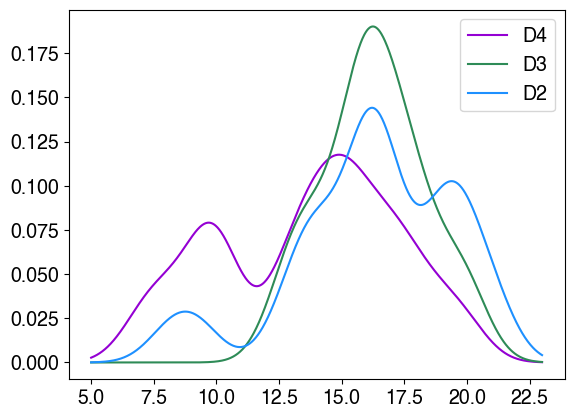

In [98]:
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}

fig, ax = plt.subplots(1,1)
ax.plot(rvap_925mb_bins, kde_rvap_925mb_d4, lcolors['d4'], label='D4')
ax.plot(rvap_925mb_bins, kde_rvap_925mb_d3, lcolors['d3'], label='D3')
ax.plot(rvap_925mb_bins, kde_rvap_925mb_d2, lcolors['d2'], label='D2')
ax.legend()

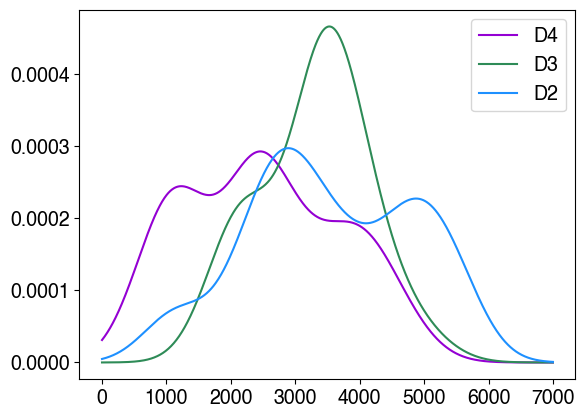

In [99]:
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}

fig, ax = plt.subplots(1,1)
ax.plot(CAPEmu_bins, kde_pCAPEmu_d4, lcolors['d4'], label='D4')
ax.plot(CAPEmu_bins, kde_pCAPEmu_d3, lcolors['d3'], label='D3')
ax.plot(CAPEmu_bins, kde_pCAPEmu_d2, lcolors['d2'], label='D2')
ax.legend()

## Plot Wide Deep cell pre-CI environment KDEs (M x N panels)

In [100]:
def plot_mxn_kde_panels_panelbins(nrow, ncol, kde_data, xbins_data, panel_titles=None, figname=None, figsize=(12,8), hspace=0.25, wspace=0.25, 
                                  legend_labels=None, legend_colors=None, legend_loc='upper right', legend_bbox=(1.05, 1), legend_ncols=1,
                                  fontsize=13, xlabels=None, ylabels=None, xlims=None, ylims=None, empty_panels=None):
    """
    kde_data: list of lists, shape [nrow][ncol], each entry is [kde_d2, kde_d3, kde_d4] or None for empty panel
    xbins_data: list of lists, shape [nrow][ncol], each entry is the xbins for that panel (shared for d2/d3/d4 in that panel)
    """
    default_font_size = plt.rcParams['font.size']
    
    if legend_labels is None:
        legend_labels = ['D2 (2.5 km)', 'D3 (500 m)', 'D4 (100 m)']
    if legend_colors is None:
        legend_colors = ['dodgerblue', 'seagreen', 'darkviolet']
    
    lw = 2
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrow, ncol, hspace=hspace, wspace=wspace)
    axes = []
    
    for i in range(nrow):
        for j in range(ncol):
            ax = fig.add_subplot(gs[i, j])
            axes.append(ax)
            if empty_panels and (i, j) in empty_panels:
                ax.axis('off')
                continue
            kde_panel = kde_data[i][j]
            xbins_panel = xbins_data[i][j]
            for k, (kde, color, label) in enumerate(zip(kde_panel, legend_colors, legend_labels)):
                if kde is not None and xbins_panel is not None:
                    ax.plot(xbins_panel, kde, color=color, lw=lw, label=label)
            if panel_titles:
                ax.set_title(panel_titles[i][j], fontsize=fontsize, loc='left', weight='bold')
            if xlabels:
                ax.set_xlabel(xlabels[i][j], fontsize=fontsize, weight='regular')
            if ylabels:
                ax.set_ylabel(ylabels[i][j], fontsize=fontsize, weight='regular')
            if xlims and xlims[i][j]:
                ax.set_xlim(xlims[i][j])
            if ylims and ylims[i][j]:
                ax.set_ylim(ylims[i][j])
            ax.grid(ls=':')
    
    # Create a single legend outside the panels
    handles = [plt.Line2D([0], [0], color=color, lw=2) for color in legend_colors]
    fig.legend(handles, legend_labels, ncol=legend_ncols, loc=legend_loc, bbox_to_anchor=legend_bbox, fontsize=fontsize*1.2)
    # fig.tight_layout()
    if figname is not None:
        fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    plt.show()

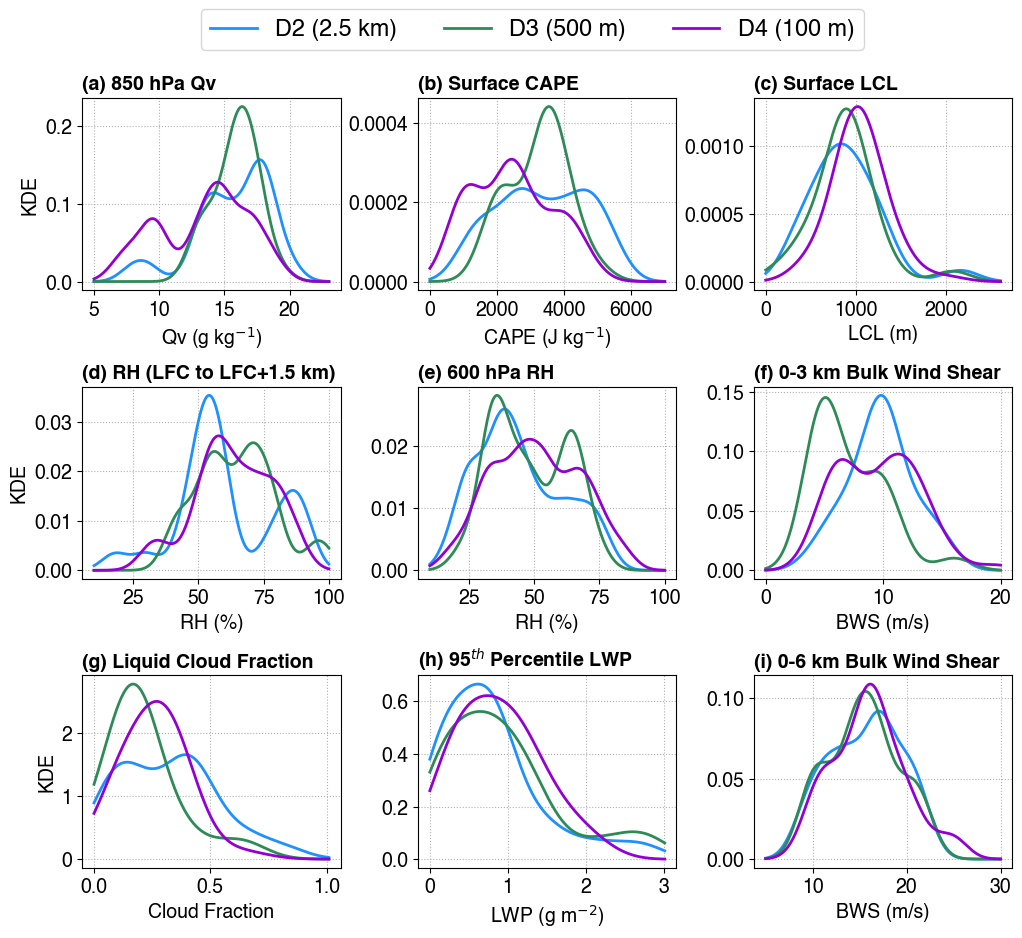

In [101]:
kde_data = [
    [
        [kde_rvap_850mb_d2, kde_rvap_850mb_d3, kde_rvap_850mb_d4],
        [kde_pCAPE_sfc_d2, kde_pCAPE_sfc_d3, kde_pCAPE_sfc_d4],
        [kde_LCLz_sfc_d2, kde_LCLz_sfc_d3, kde_LCLz_sfc_d4],
    ],
    [
        [kde_rh_at_muLFCplus1500m_d2, kde_rh_at_muLFCplus1500m_d3, kde_rh_at_muLFCplus1500m_d4],
        [kde_rh_600mb_d2, kde_rh_600mb_d3, kde_rh_600mb_d4],
        [kde_shear_mag_bulk_0to3km_d2, kde_shear_mag_bulk_0to3km_d3, kde_shear_mag_bulk_0to3km_d4],
    ],
    [
        [kde_lwpfrac_d2, kde_lwpfrac_d3, kde_lwpfrac_d4],
        [kde_lwp_p95_d2, kde_lwp_p95_d3, kde_lwp_p95_d4],
        [kde_shear_mag_bulk_0to6km_d2, kde_shear_mag_bulk_0to6km_d3, kde_shear_mag_bulk_0to6km_d4],
    ]
]
xbins_data = [
    [rvap_850mb_bins, pCAPE_sfc_bins, LCLz_bins,],
    [rh_at_muLFCplus1500m_bins, rh_600mb_bins, shear_mag_bulk_0to3km_bins,],
    [lwpfrac_bins, lwp_p95_bins, shear_mag_bulk_0to6km_bins,]
]
nrow = len(xbins_data)
ncol = len(xbins_data[0])
panel_titles = [
    ['(a) 850 hPa Qv', '(b) Surface CAPE', '(c) Surface LCL'],
    ['(d) RH (LFC to LFC+1.5 km)', '(e) 600 hPa RH', '(f) 0-3 km Bulk Wind Shear'],
    ['(g) Liquid Cloud Fraction', '(h) 95$^{th}$ Percentile LWP', '(i) 0-6 km Bulk Wind Shear'],
]
xlabels = [
    ['Qv (g kg$^{-1}$)', 'CAPE (J kg$^{-1}$)', 'LCL (m)'],
    ['RH (%)', 'RH (%)', 'BWS (m/s)'],
    ['Cloud Fraction', 'LWP (g m$^{-2}$)', 'BWS (m/s)'],
]
ylabels = [
    ['KDE', '', ''],
    ['KDE', '', ''],
    ['KDE', '', ''],
]
# empty_panels = [(2,2)]
empty_panels = None
figname = f"{figdir}WideDeep_Cell_preCI_KDE.png"
plot_mxn_kde_panels_panelbins(nrow, ncol, kde_data, xbins_data, panel_titles=panel_titles, xlabels=xlabels, ylabels=ylabels, fontsize=14,
                              legend_loc='upper center', legend_bbox=(0.5, 0.98), legend_ncols=3,
                              figname=figname, empty_panels=empty_panels, figsize=(12,10), hspace=0.5, wspace=0.3)